In [2]:
# NOTE: This file is the source for three Jupyter notebook cells.
# Copy each section into its own cell.
# =============================================================================

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Imports · API path · Global parameters · Fixed refractive indices ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import sys
import os
import platform
import time
import logging
from pathlib import Path
from datetime import datetime

import numpy as np
import h5py

# ─────────────────────────────────────────────────────────────────────────────
# Lumerical installation paths
# ► Set LUMERICAL_VERSION to exactly match your installation folder name.
#   Check:  C:\Program Files\Lumerical\   and read the subfolder name.
# ─────────────────────────────────────────────────────────────────────────────
LUMERICAL_VERSION = "v202"          # ← confirmed from your traceback

if platform.system() == "Windows":
    LUMERICAL_ROOT = rf"C:\Program Files\Lumerical\{LUMERICAL_VERSION}"
    LUMERICAL_API  = rf"{LUMERICAL_ROOT}\api\python"
    LUMERICAL_BIN  = rf"{LUMERICAL_ROOT}\bin"
else:
    LUMERICAL_ROOT = f"/opt/lumerical/{LUMERICAL_VERSION}"
    LUMERICAL_API  = f"{LUMERICAL_ROOT}/api/python"
    LUMERICAL_BIN  = f"{LUMERICAL_ROOT}/bin"

# ── 1. Clear any previously cached failed import ─────────────────────────────
# If lumapi was imported and failed in this kernel session, Python stores the
# broken module in sys.modules and returns the same failure on every retry.
# Removing it forces a clean re-import.
if "lumapi" in sys.modules:
    del sys.modules["lumapi"]

# ── 2. Add the API folder to sys.path ────────────────────────────────────────
if LUMERICAL_API not in sys.path:
    sys.path.insert(0, LUMERICAL_API)

# ── 3. Register the bin directory as a DLL search path ───────────────────────
# REQUIRED on Python 3.8+ (you are on 3.11).
# os.environ["PATH"] manipulation does NOT work for CDLL() from Python 3.8
# onwards — Windows changed DLL resolution to ignore PATH by default.
# os.add_dll_directory() is the correct API.
if platform.system() == "Windows":
    if hasattr(os, "add_dll_directory"):          # Python 3.8+  ← your case
        os.add_dll_directory(str(LUMERICAL_BIN))
    else:                                          # Python < 3.8 fallback
        os.environ["PATH"] = (
            str(LUMERICAL_BIN) + ";" + os.environ.get("PATH", "")
        )

# ── 4. Verify the paths exist before importing ───────────────────────────────
assert Path(LUMERICAL_API).exists(), (
    f"Lumerical API path not found:\n  {LUMERICAL_API}\n"
    f"Check LUMERICAL_VERSION = '{LUMERICAL_VERSION}'"
)
assert Path(LUMERICAL_BIN).exists(), (
    f"Lumerical bin path not found:\n  {LUMERICAL_BIN}"
)

import lumapi  # noqa — must come after all path setup above
print(f"lumapi imported successfully from:\n  {lumapi.__file__}")

# ─────────────────────────────────────────────────────────────────────────────
# Logging
# ─────────────────────────────────────────────────────────────────────────────
logging.basicConfig(
    level   = logging.INFO,
    format  = "%(asctime)s │ %(levelname)s │ %(message)s",
    datefmt = "%H:%M:%S",
)
log = logging.getLogger("SiN_FDE")

# ─────────────────────────────────────────────────────────────────────────────
# I/O  ─ directory and HDF5 output path
# ─────────────────────────────────────────────────────────────────────────────
VERSION_NAME = "LUM_SiN_STRp_400nm_wdth_sweep_V1"
PROJECT_DIR  = Path.cwd()
DATA_DIR     = PROJECT_DIR / "data_STRp_SiN_mode_analysis_LUM"
DATA_DIR.mkdir(parents=True, exist_ok=True)
HDF5_PATH    = DATA_DIR / f"{VERSION_NAME}.h5"

# ─────────────────────────────────────────────────────────────────────────────
# Waveguide geometry  (µm throughout unless stated)
#
#  Cross-section  (Y-Z plane, X = propagation direction):
#
#     ┌────────────────────────────────────────────┐
#     │        Aqueous  n = 1.33  (upper clad)     │  z >  +core_t/2
#     │     ┌────────────────────┐                 │
#     │     │       SiN          │  core_t = 0.4   │  z ∈ [-0.2, +0.2] µm
#     │     └────────────────────┘                 │
#     │        SiO₂  n = 1.4469  (lower clad)      │  z < -0.2 µm
#     └────────────────────────────────────────────┘
#              ←—— width sweep ——→
# ─────────────────────────────────────────────────────────────────────────────
CORE_THICKNESS_UM  = 0.400    # SiN core height  [µm]
N_MODES_REQUEST    = 6        # max modes to request from the FDE eigenvalue solver

# Simulation domain margins
SIM_Y_MARGIN_UM    = 2.5      # lateral cladding margin each side beyond core half-width [µm]
SIM_Z_BELOW_UM     = 2.0      # SiO₂ substrate depth below core bottom [µm]
SIM_Z_ABOVE_UM     = 2.0      # aqueous depth above core top           [µm]

# ─────────────────────────────────────────────────────────────────────────────
# Fixed refractive indices  (evaluated at 1550 nm via Sellmeier,
# held constant across the entire wavelength and width sweep)
#
#   n_SiN  = sqrt(1 + 2.9144·λ²/(λ²-0.1366²) + 0.004873/(λ²-1.6606²))
#          → 1.980780 at 1550 nm
#
#   n_SiO2 = sqrt(1 + 1.1056·λ²/(λ²-0.078²) + 2.360·λ²/(λ²-16.681²)) + 0.002
#          → 1.446940 at 1550 nm
#
#   n_aq   = 1.33   (aqueous medium, constant by definition)
# ─────────────────────────────────────────────────────────────────────────────
N_SIN_FIXED   = 1.99   # SiN  @ 1550 nm  — used for FDE index and mesh sizing
N_SIO2_FIXED  = 1.4469   # SiO₂ @ 1550 nm  — used for FDE index and guided-mode cutoff
N_UPPER_CLADDING = 1.33  # aqueous medium   — used for FDE index (constant)

# ─────────────────────────────────────────────────────────────────────────────
# Width sweep   600 nm → 1500 nm,  100 uniformly-spaced points
# ─────────────────────────────────────────────────────────────────────────────
SWEEP_WIDTHS_UM = np.linspace(0.600, 1.500, 100)    # [µm]

# ─────────────────────────────────────────────────────────────────────────────
# Wavelength sweep  :  λ₀ = 1550 nm  +  12 jumps of (10/13) nm  →  13 points
#
#   λₙ = 1550 + n × (10/13)  nm      n = 0, 1, … 12
#   λ₁₂ = 1550 + 120/13 ≈ 1559.2308 nm
# ─────────────────────────────────────────────────────────────────────────────
LAMBDA_START_NM  = 1550.0
DELTA_LAMBDA_NM  = 10.0 / 13.0          # ≈ 0.769231 nm  (exact rational step)
N_WAVELENGTHS    = 13                    # 0 … 12 inclusive
SWEEP_WL_NM  = LAMBDA_START_NM + np.arange(N_WAVELENGTHS) * DELTA_LAMBDA_NM
SWEEP_WL_UM  = SWEEP_WL_NM * 1e-3       # [µm]
SWEEP_WL_M   = SWEEP_WL_UM * 1e-6       # [m]  — Lumerical SI units

# ─────────────────────────────────────────────────────────────────────────────
# Derived domain dimensions
# ─────────────────────────────────────────────────────────────────────────────
# y: accommodate the widest core (1.5 µm) + 2 × lateral margin
SIM_Y_SPAN_UM  = SWEEP_WIDTHS_UM.max() + 2.0 * SIM_Y_MARGIN_UM      # 6.5 µm

# z: SiO₂ below  +  core  +  aqueous above
SIM_Z_SPAN_UM  = SIM_Z_BELOW_UM + CORE_THICKNESS_UM + SIM_Z_ABOVE_UM # 4.4 µm

# ─────────────────────────────────────────────────────────────────────────────
# Mesh sizing:  target ≈ λ_max / (N_SIN_FIXED × 10)
#   i.e. 10 mesh cells per wavelength inside the core material.
#   N_SIN_FIXED is used directly here — no separate approximation variable.
#
# Raise MESH_CELLS_PER_WVL to 15–20 for publication-grade neff accuracy.
# ─────────────────────────────────────────────────────────────────────────────
MESH_CELLS_PER_WVL = 10
_mesh_step_um      = SWEEP_WL_UM.max() / (N_SIN_FIXED * MESH_CELLS_PER_WVL)
MESH_CELLS_Y       = int(np.ceil(SIM_Y_SPAN_UM / _mesh_step_um))   # ≈ 83
MESH_CELLS_Z       = int(np.ceil(SIM_Z_SPAN_UM / _mesh_step_um))   # ≈ 56

# ─────────────────────────────────────────────────────────────────────────────
# Summary printout
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 62)
print("  SiN Straight Waveguide — 2D FDE Width Sweep  (Lumerical)")
print("=" * 62)
print(f"  Version      : {VERSION_NAME}")
print(f"  Widths       : {SWEEP_WIDTHS_UM[0]*1e3:.0f} → {SWEEP_WIDTHS_UM[-1]*1e3:.0f} nm  "
      f"({len(SWEEP_WIDTHS_UM)} pts)")
print(f"  Wavelengths  : {SWEEP_WL_NM[0]:.4f} → {SWEEP_WL_NM[-1]:.4f} nm  "
      f"({N_WAVELENGTHS} pts,  Δλ = 10/13 ≈ {DELTA_LAMBDA_NM:.5f} nm)")
print(f"  Core h       : {CORE_THICKNESS_UM*1e3:.0f} nm")
print(f"  n_SiN        : {N_SIN_FIXED}  (fixed @ 1550 nm)")
print(f"  n_SiO₂       : {N_SIO2_FIXED}  (fixed @ 1550 nm)  ← guided-mode cutoff")
print(f"  n_aqueous    : {N_UPPER_CLADDING}  (constant)")
print(f"  Domain       : y = {SIM_Y_SPAN_UM:.2f} µm,  z = {SIM_Z_SPAN_UM:.2f} µm")
print(f"  Mesh step    : ≈ {_mesh_step_um*1e3:.1f} nm  "
      f"({MESH_CELLS_Y} × {MESH_CELLS_Z} cells,  "
      f"≈ λ_max / (n_SiN × {MESH_CELLS_PER_WVL}))")
print(f"  Total FDE    : {len(SWEEP_WIDTHS_UM)} × {N_WAVELENGTHS} = "
      f"{len(SWEEP_WIDTHS_UM)*N_WAVELENGTHS} runs")
print(f"  HDF5 output  : {HDF5_PATH}")
print("=" * 62)


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — FDE helpers  +  main sweep function                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# Helper 1 :  _init_fde_geometry
#   Clears the session, creates the FDE solver region and the three material
#   rectangles.  Called ONCE at the start; geometry is then updated in-loop
#   via setnamed() to avoid rebuilding from scratch on every width step.
#
#   Material indices are set from the fixed constants N_SIN_FIXED,
#   N_SIO2_FIXED, N_UPPER_CLADDING — no Sellmeier evaluation.
#
#   Structure override order (same default mesh-order → last added wins):
#     1st added  →  Aqueous_bg          (background, lowest priority)
#     2nd added  →  SiO2_lower_clad     (overrides Aqueous below the core)
#     3rd added  →  SiN_core            (overrides everything, highest priority)
# ─────────────────────────────────────────────────────────────────────────────
def _init_fde_geometry(
    mode,
    wavelength_m      : float,
    initial_width_m   : float,
    core_t_um         : float,
    sim_y_span_um     : float,
    sim_z_span_um     : float,
    sim_z_ctr_um      : float,
    sio2_z_ctr_um     : float,
    sio2_z_span_um    : float,
    mesh_cells_y      : int,
    mesh_cells_z      : int,
    n_modes_request   : int,
):
    """
    Creates FDE solver region + three material rectangles in a clean session.
    Indices are taken directly from the module-level constants
    N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING.
    """
    m = mode
    m.switchtolayout()
    m.selectall()
    m.delete()

    # ── FDE solver region ────────────────────────────────────────────────────
    m.addfde()
    m.set("solver type",           "2D X normal")
    m.set("x",                     0.0)
    m.set("y",                     0.0)
    m.set("z",                     sim_z_ctr_um     * 1e-6)
    m.set("y span",                sim_y_span_um    * 1e-6)
    m.set("z span",                sim_z_span_um    * 1e-6)
    m.set("wavelength",            wavelength_m)
    m.set("number of trial modes", n_modes_request)
    m.set("mesh cells y",          mesh_cells_y)
    m.set("mesh cells z",          mesh_cells_z)

    # ── 1st structure : Aqueous background (full domain, lowest priority) ────
    m.addrect()
    m.set("name",    "Aqueous_bg")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", sim_y_span_um  * 1e-6)
    m.set("z",       sim_z_ctr_um  * 1e-6)
    m.set("z span",  sim_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_UPPER_CLADDING)             # 1.33, constant

    # ── 2nd structure : SiO₂ lower-cladding slab ─────────────────────────────
    # Spans full y, from domain bottom up to the core bottom (z = -core_t/2)
    m.addrect()
    m.set("name",    "SiO2_lower_clad")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", sim_y_span_um  * 1e-6)
    m.set("z",       sio2_z_ctr_um  * 1e-6)
    m.set("z span",  sio2_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIO2_FIXED)                 # 1.4469, fixed

    # ── 3rd structure : SiN waveguide core (highest priority) ────────────────
    # y span is updated in the inner width loop; all other dims are fixed.
    m.addrect()
    m.set("name",    "SiN_core")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", initial_width_m)
    m.set("z",       0.0);  m.set("z span", core_t_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIN_FIXED)                  # 1.9808, fixed


# ─────────────────────────────────────────────────────────────────────────────
# Helper 2 :  _extract_mode_results
#   After findmodes() reads neff (complex), TE polarization fraction, and
#   counts guided modes.
#
#   Guided criterion:  Re(neff) > N_SIO2_FIXED
#   This is the physically correct cutoff for an asymmetric waveguide whose
#   highest-index cladding is SiO₂.  Radiation modes discretised by the
#   finite simulation domain have neff < N_SIO2_FIXED and are filtered out.
#
#   Returns arrays of shape (n_modes_request,) — NaN where a mode was not found.
# ─────────────────────────────────────────────────────────────────────────────
def _extract_mode_results(mode, n_modes_request: int):
    """
    Extract neff (complex), TE fraction, and guided-mode count from the FDE
    result after findmodes().

    Uses N_SIO2_FIXED (module-level constant) as the guided-mode cutoff.

    Returns
    -------
    neff_real : np.ndarray  (n_modes_request,)   Re(neff), NaN if not found
    neff_imag : np.ndarray  (n_modes_request,)   Im(neff)
    te_frac   : np.ndarray  (n_modes_request,)   TE polarization fraction
    n_guided  : int                               count of guided modes
    """
    neff_real = np.full(n_modes_request, np.nan, dtype=np.float64)
    neff_imag = np.full(n_modes_request, np.nan, dtype=np.float64)
    te_frac   = np.full(n_modes_request, np.nan, dtype=np.float64)
    n_guided  = 0

    for m_i in range(1, n_modes_request + 1):
        mode_grp = f"FDE::data::mode{m_i}"
        try:
            raw_neff = mode.getdata(mode_grp, "neff")
            raw_te   = mode.getdata(mode_grp, "TE polarization fraction")
        except Exception:
            break   # no more modes available — stop

        # Normalise to Python scalar regardless of array shape returned
        neff_c = complex(np.asarray(raw_neff).flat[0])
        te_v   = float(np.asarray(raw_te).flat[0])

        neff_real[m_i - 1] = neff_c.real
        neff_imag[m_i - 1] = neff_c.imag
        te_frac  [m_i - 1] = te_v

        # Guided-mode test: Re(neff) must exceed the highest cladding index
        if neff_c.real > N_SIO2_FIXED:
            n_guided += 1

    return neff_real, neff_imag, te_frac, n_guided


# ─────────────────────────────────────────────────────────────────────────────
# Helper 3 :  _init_hdf5
#   Creates a fresh HDF5 file with pre-allocated datasets and full metadata.
#   Uses chunked storage so incremental slice-writes are efficient.
# ─────────────────────────────────────────────────────────────────────────────
def _init_hdf5(
    path            : Path,
    n_w             : int,
    n_wl            : int,
    n_modes         : int,
    sweep_widths_um : np.ndarray,
    sweep_wl_um     : np.ndarray,
    metadata        : dict,
):
    with h5py.File(path, "w") as f:
        # — metadata group ————————————————————————————————————————————————————
        md = f.create_group("metadata")
        md.create_dataset("sweep_widths_um",      data=sweep_widths_um)
        md.create_dataset("sweep_wavelengths_nm", data=sweep_wl_um * 1e3)
        md.create_dataset("sweep_wavelengths_um", data=sweep_wl_um)
        for k, v in metadata.items():
            md.attrs[k] = v
        md.attrs["timestamp_start"] = datetime.now().isoformat()

        # — result datasets  (NaN-initialised, chunked per width row) ─────────
        chunk_shape = (1, n_wl, n_modes)
        nan3d = np.full((n_w, n_wl, n_modes), np.nan, dtype=np.float64)
        rg = f.create_group("results")
        rg.create_dataset("neff_real", data=nan3d, chunks=chunk_shape)
        rg.create_dataset("neff_imag", data=nan3d, chunks=chunk_shape)
        rg.create_dataset("te_frac",   data=nan3d, chunks=chunk_shape)
        rg.create_dataset("n_guided",
                          data=np.zeros((n_w, n_wl), dtype=np.int32),
                          chunks=(1, n_wl))

        # — progress flag ─────────────────────────────────────────────────────
        f.create_group("flags").create_dataset(
            "computed",
            data=np.zeros((n_w, n_wl), dtype=bool),
            chunks=(1, n_wl),
        )


# ─────────────────────────────────────────────────────────────────────────────
# Main function :  run_width_sweep_fde
# ─────────────────────────────────────────────────────────────────────────────
def run_width_sweep_fde(
    sweep_widths_um    = SWEEP_WIDTHS_UM,
    sweep_wl_um        = SWEEP_WL_UM,
    core_thickness_um  = CORE_THICKNESS_UM,
    n_modes_request    = N_MODES_REQUEST,
    sim_y_span_um      = SIM_Y_SPAN_UM,
    sim_z_below_um     = SIM_Z_BELOW_UM,
    sim_z_above_um     = SIM_Z_ABOVE_UM,
    mesh_cells_y       = MESH_CELLS_Y,
    mesh_cells_z       = MESH_CELLS_Z,
    hdf5_path          = HDF5_PATH,
    version_name       = VERSION_NAME,
    hide_gui           = False,           # set True for headless / HPC runs
):
    """
    2-D FDE width sweep for a straight SiN waveguide on SiO₂ with aqueous top
    cladding, using Lumerical MODE Solutions via the Python lumapi.

    Material indices are fixed constants (N_SIN_FIXED, N_SIO2_FIXED,
    N_UPPER_CLADDING) — no Sellmeier evaluation at any point.

    Sweep axes
    ----------
    - Inner  :  SiN core y-span  (600 nm → 1500 nm,  100 pts)
    - Outer  :  wavelength        (1550.0 nm → 1559.23 nm,  13 pts)

    At each (width, λ) point the function
      1. Updates the FDE solver wavelength and the core y-span.
      2. Runs mesh  →  findmodes()  →  extracts neff + TE fraction.
      3. Counts guided modes  (Re(neff) > N_SIO2_FIXED).
      4. Writes results to HDF5 immediately and flushes — safe to interrupt.

    Re-running skips already-computed points automatically (cache check via
    flags/computed dataset in HDF5).

    Returns
    -------
    dict with keys:
        neff_real       np.ndarray  [n_widths, n_wl, n_modes_request]
        neff_imag       np.ndarray  [n_widths, n_wl, n_modes_request]
        te_frac         np.ndarray  [n_widths, n_wl, n_modes_request]
        n_guided        np.ndarray  [n_widths, n_wl]
        computed        np.ndarray  [n_widths, n_wl]  bool
        sweep_widths_um np.ndarray  [n_widths]  µm
        sweep_wl_nm     np.ndarray  [n_wl]      nm
    """
    n_w   = len(sweep_widths_um)
    n_wl  = len(sweep_wl_um)
    n_mod = n_modes_request

    # ── Pre-compute all fixed geometry quantities ─────────────────────────────
    half_t         = core_thickness_um / 2.0
    sim_z_span_tot = sim_z_below_um + core_thickness_um + sim_z_above_um

    # Core sits at z = 0  →  SiO₂ slab spans  z ∈ [-(half_t + sim_z_below), -half_t]
    sio2_z_span = sim_z_below_um
    sio2_z_ctr  = -(half_t + sim_z_below_um / 2.0)

    # Simulation region centre (= 0 when below == above, i.e. symmetric domain)
    sim_z_ctr   = (sim_z_above_um - sim_z_below_um) / 2.0

    # ── Allocate in-memory result arrays ──────────────────────────────────────
    neff_real = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    neff_imag = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    te_frac   = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    n_guided  = np.zeros((n_w, n_wl), dtype=np.int32)
    computed  = np.zeros((n_w, n_wl), dtype=bool)

    # ── HDF5 : load cache or create new file ─────────────────────────────────
    if hdf5_path.exists():
        log.info(f"Cache found → {hdf5_path}")
        with h5py.File(hdf5_path, "r") as f:
            if "results/neff_real" in f:
                neff_real[:] = f["results/neff_real"][:]
                neff_imag[:] = f["results/neff_imag"][:]
                te_frac[:]   = f["results/te_frac"][:]
                n_guided[:]  = f["results/n_guided"][:]
                computed[:]  = f["flags/computed"][:]
        n_cached  = int(computed.sum())
        remaining = n_w * n_wl - n_cached
        log.info(f"Cached: {n_cached}/{n_w*n_wl}  |  Remaining: {remaining}")
        if remaining == 0:
            log.info("All points already computed — returning cached results.")
            return dict(
                neff_real       = neff_real,
                neff_imag       = neff_imag,
                te_frac         = te_frac,
                n_guided        = n_guided,
                computed        = computed,
                sweep_widths_um = sweep_widths_um,
                sweep_wl_nm     = sweep_wl_um * 1e3,
            )
    else:
        log.info("No cache found — initialising new HDF5 file.")
        _init_hdf5(
            path            = hdf5_path,
            n_w             = n_w,
            n_wl            = n_wl,
            n_modes         = n_mod,
            sweep_widths_um = sweep_widths_um,
            sweep_wl_um     = sweep_wl_um,
            metadata        = {
                "version_name"     : version_name,
                "core_thickness_um": core_thickness_um,
                "n_SiN_fixed"      : N_SIN_FIXED,
                "n_SiO2_fixed"     : N_SIO2_FIXED,
                "n_upper_cladding" : N_UPPER_CLADDING,
                "sim_y_span_um"    : sim_y_span_um,
                "sim_z_below_um"   : sim_z_below_um,
                "sim_z_above_um"   : sim_z_above_um,
                "mesh_cells_y"     : mesh_cells_y,
                "mesh_cells_z"     : mesh_cells_z,
                "n_modes_request"  : n_mod,
                "delta_lambda_nm"  : float(np.diff(sweep_wl_um * 1e3).mean()),
            },
        )

    # ── Open Lumerical MODE session ───────────────────────────────────────────
    log.info("Launching Lumerical MODE …")
    mode = lumapi.MODE(hide=hide_gui)

    runs_done  = 0
    runs_total = int((~computed).sum())
    t_start    = time.time()

    try:
        # ── Build geometry once ───────────────────────────────────────────────
        # Wavelength for the initial FDE setup: first point of the sweep.
        # Derived from the function parameter sweep_wl_um — not from any global.
        _init_fde_geometry(
            mode            = mode,
            wavelength_m    = float(sweep_wl_um[0] * 1e-6),   # µm → m
            initial_width_m = float(sweep_widths_um[0] * 1e-6),
            core_t_um       = core_thickness_um,
            sim_y_span_um   = sim_y_span_um,
            sim_z_span_um   = sim_z_span_tot,
            sim_z_ctr_um    = sim_z_ctr,
            sio2_z_ctr_um   = sio2_z_ctr,
            sio2_z_span_um  = sio2_z_span,
            mesh_cells_y    = mesh_cells_y,
            mesh_cells_z    = mesh_cells_z,
            n_modes_request = n_mod,
        )
        log.info(f"Geometry initialised  ({runs_total} FDE runs remaining) …")

        # ── Keep HDF5 open for the entire sweep  (flush after each point) ─────
        with h5py.File(hdf5_path, "r+") as hf:

            # ╔══════════════════════════════════════════════════════╗
            # ║  OUTER LOOP : wavelength                            ║
            # ╚══════════════════════════════════════════════════════╝
            for wl_idx, wl_um in enumerate(sweep_wl_um):

                # Fast-skip: all widths at this λ already cached
                if computed[:, wl_idx].all():
                    continue

                # Wavelength in SI metres — derived from function parameter
                wl_m = float(wl_um * 1e-6)

                # Only the FDE solver wavelength changes per outer iteration.
                # Material indices are fixed — no setnamed index update here.
                mode.switchtolayout()
                mode.setnamed("FDE", "wavelength", wl_m)

                log.info(
                    f"─── λ[{wl_idx:2d}] = {wl_um*1e3:.4f} nm │ "
                    f"n_SiN = {N_SIN_FIXED}  n_SiO₂ = {N_SIO2_FIXED}  "
                    f"n_aq = {N_UPPER_CLADDING}  (all fixed)"
                )

                # ╔══════════════════════════════════════════════════╗
                # ║  INNER LOOP : width                             ║
                # ╚══════════════════════════════════════════════════╝
                for w_idx, w_um in enumerate(sweep_widths_um):

                    # ── Cache check ───────────────────────────────────────
                    if computed[w_idx, wl_idx]:
                        continue

                    # ── Update core width (only geometry change per step) ──
                    mode.switchtolayout()
                    mode.setnamed("SiN_core", "y span", float(w_um * 1e-6))

                    # ── Run FDE mesh  →  find modes ───────────────────────
                    try:
                        mode.run()
                        _raw_nfound = mode.findmodes()
                        n_found     = int(np.asarray(_raw_nfound).flat[0])
                    except Exception as exc:
                        log.warning(
                            f"  FDE FAILED │ w = {w_um*1e3:.1f} nm  "
                            f"λ = {wl_um*1e3:.4f} nm │ {exc}"
                        )
                        # Mark as done with NaN result to skip on re-run
                        computed[w_idx, wl_idx]             = True
                        hf["flags/computed"][w_idx, wl_idx] = True
                        hf.flush()
                        continue

                    # ── Extract and classify modes ─────────────────────────
                    # n_found is passed only for awareness; _extract_mode_results
                    # iterates up to n_modes_request and breaks on missing modes.
                    nr, ni, tf, ng = _extract_mode_results(mode, n_mod)

                    # ── Store in memory ───────────────────────────────────
                    neff_real[w_idx, wl_idx, :] = nr
                    neff_imag[w_idx, wl_idx, :] = ni
                    te_frac  [w_idx, wl_idx, :] = tf
                    n_guided [w_idx, wl_idx]     = ng
                    computed [w_idx, wl_idx]     = True

                    # ── Write to HDF5  (incremental, fault-safe) ──────────
                    hf["results/neff_real"][w_idx, wl_idx, :] = nr
                    hf["results/neff_imag"][w_idx, wl_idx, :] = ni
                    hf["results/te_frac"]  [w_idx, wl_idx, :] = tf
                    hf["results/n_guided"] [w_idx, wl_idx]    = ng
                    hf["flags/computed"]   [w_idx, wl_idx]    = True
                    hf.flush()

                    runs_done += 1

                    # ── Progress report every 10 completed runs ───────────
                    if runs_done % 10 == 0 or runs_done == runs_total:
                        elapsed = time.time() - t_start
                        rate    = runs_done / elapsed if elapsed > 0 else 1e-9
                        eta     = (runs_total - runs_done) / rate
                        log.info(
                            f"  [{runs_done:4d}/{runs_total}]  "
                            f"w = {w_um*1e3:6.1f} nm │ "
                            f"n_guided = {ng} │ "
                            f"{rate:.1f} sim/s │ "
                            f"ETA {eta:5.0f} s"
                        )

            # ── Close-out metadata ────────────────────────────────────────
            hf["metadata"].attrs["timestamp_end"]   = datetime.now().isoformat()
            hf["metadata"].attrs["runs_completed"]  = int(computed.sum())

    finally:
        mode.close()
        log.info("Lumerical MODE session closed.")

    elapsed_total = time.time() - t_start
    log.info(
        f"Sweep done │ {runs_done} new runs │ "
        f"total = {elapsed_total:.1f} s │ "
        f"avg = {elapsed_total / max(runs_done, 1):.2f} s/sim"
    )

    return dict(
        neff_real       = neff_real,
        neff_imag       = neff_imag,
        te_frac         = te_frac,
        n_guided        = n_guided,
        computed        = computed,
        sweep_widths_um = sweep_widths_um,
        sweep_wl_nm     = sweep_wl_um * 1e3,
    )


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Execute sweep + quick sanity output                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

results = run_width_sweep_fde()

# ── Unpack for downstream cells ───────────────────────────────────────────────
neff_real       = results["neff_real"]          # [n_widths, n_wl, n_modes]
neff_imag       = results["neff_imag"]
te_frac         = results["te_frac"]
n_guided        = results["n_guided"]           # [n_widths, n_wl]
computed        = results["computed"]
sweep_widths_um = results["sweep_widths_um"]    # [100]  µm
sweep_wl_nm     = results["sweep_wl_nm"]        # [13]   nm

print("\n" + "=" * 58)
print("  Sweep complete — result summary")
print("=" * 58)
print(f"  neff_real shape  : {neff_real.shape}  (widths × λ × modes)")
print(f"  n_guided  shape  : {n_guided.shape}")
print(f"  Points computed  : {computed.sum()} / {computed.size}")
print(f"  HDF5 saved to    : {HDF5_PATH}")

print(f"\n  Guided-mode count at λ = {sweep_wl_nm[0]:.4f} nm  (first 15 widths):")
print(f"  {'Width [nm]':>10}  {'n_guided':>10}  {'neff_mode0':>12}  {'TE_frac_0':>10}")
print("  " + "-" * 46)
for i in range(min(15, len(sweep_widths_um))):
    w_nm   = sweep_widths_um[i] * 1e3
    ng     = n_guided[i, 0]
    ne0    = neff_real[i, 0, 0]
    te0    = te_frac [i, 0, 0]
    ne_str = f"{ne0:.5f}" if not np.isnan(ne0) else "   NaN  "
    te_str = f"{te0:.3f}"  if not np.isnan(te0) else "  NaN "
    print(f"  {w_nm:>10.1f}  {ng:>10}  {ne_str:>12}  {te_str:>10}")

18:58:53 │ INFO │ Cache found → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1.h5
18:58:53 │ INFO │ Cached: 1300/1300  |  Remaining: 0
18:58:53 │ INFO │ All points already computed — returning cached results.


lumapi imported successfully from:
  C:\Program Files\Lumerical\v202\api\python\lumapi.py
  SiN Straight Waveguide — 2D FDE Width Sweep  (Lumerical)
  Version      : LUM_SiN_STRp_400nm_wdth_sweep_V1
  Widths       : 600 → 1500 nm  (100 pts)
  Wavelengths  : 1550.0000 → 1559.2308 nm  (13 pts,  Δλ = 10/13 ≈ 0.76923 nm)
  Core h       : 400 nm
  n_SiN        : 1.99  (fixed @ 1550 nm)
  n_SiO₂       : 1.4469  (fixed @ 1550 nm)  ← guided-mode cutoff
  n_aqueous    : 1.33  (constant)
  Domain       : y = 6.50 µm,  z = 4.40 µm
  Mesh step    : ≈ 78.4 nm  (83 × 57 cells,  ≈ λ_max / (n_SiN × 10))
  Total FDE    : 100 × 13 = 1300 runs
  HDF5 output  : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1.h5

  Sweep complete — result summary
  neff_real shape  : (100, 13, 6)  (widths × λ × modes)
  n_guided  shape  : (100, 13)
  Points computed  : 1300 / 1300
  HDF5 saved to    : D:\GitHub\GDS_py_TDY_venv\Fabrication_desi

In [3]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — SiO₂ cladding sweep : new constants + extended functions         ║
# ║                                                                             ║
# ║  ASSUMES CELLS 1–3 ALREADY EXECUTED.                                       ║
# ║  All imports, sweep arrays, mesh constants, helper functions and the        ║
# ║  first-sweep result dict are live in the kernel namespace.                  ║
# ║                                                                             ║
# ║  Only two things change vs the aqueous sweep:                               ║
# ║    1. The background/upper-cladding index  (1.33 → N_SIO2_FIXED = 1.4469)  ║
# ║    2. The output HDF5 file                                                  ║
# ║                                                                             ║
# ║  Strategy: extend _init_fde_geometry and run_width_sweep_fde with one new  ║
# ║  optional parameter each (default = original value → zero behaviour        ║
# ║  change for the aqueous sweep if it is ever re-run).                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# New constants only — nothing from Cell 1 is repeated
# ─────────────────────────────────────────────────────────────────────────────
VERSION_NAME_SIO2     = "LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1"
HDF5_PATH_SIO2        = DATA_DIR / f"{VERSION_NAME_SIO2}.h5"
N_UPPER_CLADDING_SIO2 = N_SIO2_FIXED      # 1.4469 — Silica replaces aqueous

print(f"SiO₂-cladding sweep")
print(f"  version  : {VERSION_NAME_SIO2}")
print(f"  output   : {HDF5_PATH_SIO2}")
print(f"  n_upper  : {N_UPPER_CLADDING_SIO2}  (Silica, symmetric stack)")
print(f"  n_lower  : {N_SIO2_FIXED}  (SiO₂ substrate — unchanged)")
print(f"  n_core   : {N_SIN_FIXED}   (SiN core — unchanged)")
print(f"  cutoff   : Re(neff) > {N_SIO2_FIXED}  (same threshold, now symmetric)")
print()

# ─────────────────────────────────────────────────────────────────────────────
# Extended _init_fde_geometry
# ─────────────────────────────────────────────────────────────────────────────
# ONE change vs Cell-2 version:
#   parameter  n_background (default = N_UPPER_CLADDING)  replaces the
#   hardcoded  N_UPPER_CLADDING  on the Aqueous_bg rectangle.
# All other geometry, mesh and solver settings are identical.
# ─────────────────────────────────────────────────────────────────────────────
def _init_fde_geometry(
    mode,
    wavelength_m      : float,
    initial_width_m   : float,
    core_t_um         : float,
    sim_y_span_um     : float,
    sim_z_span_um     : float,
    sim_z_ctr_um      : float,
    sio2_z_ctr_um     : float,
    sio2_z_span_um    : float,
    mesh_cells_y      : int,
    mesh_cells_z      : int,
    n_modes_request   : int,
    n_background      = N_UPPER_CLADDING,  # ← NEW: upper/lateral cladding index
                                           #   default keeps aqueous behaviour
):
    """
    Creates FDE solver region + three material rectangles in a clean session.

    n_background sets the index of the Aqueous_bg rectangle (upper and lateral
    cladding).  Defaults to N_UPPER_CLADDING (1.33, aqueous) so the original
    call in run_width_sweep_fde remains valid without any argument change.
    Pass N_SIO2_FIXED (1.4469) for the symmetric SiO₂-cladding sweep.

    N_SIN_FIXED and N_SIO2_FIXED (core and lower cladding) are always taken
    from module-level constants — they never change between sweeps.
    """
    m = mode
    m.switchtolayout()
    m.selectall()
    m.delete()

    # ── FDE solver region ────────────────────────────────────────────────────
    m.addfde()
    m.set("solver type",           "2D X normal")
    m.set("x",                     0.0)
    m.set("y",                     0.0)
    m.set("z",                     sim_z_ctr_um     * 1e-6)
    m.set("y span",                sim_y_span_um    * 1e-6)
    m.set("z span",                sim_z_span_um    * 1e-6)
    m.set("wavelength",            wavelength_m)
    m.set("number of trial modes", n_modes_request)
    m.set("mesh cells y",          mesh_cells_y)
    m.set("mesh cells z",          mesh_cells_z)

    # ── 1st structure : background (full domain, lowest priority) ─────────────
    # Name kept as "Aqueous_bg" for consistency; index is n_background.
    m.addrect()
    m.set("name",    "Aqueous_bg")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", sim_y_span_um  * 1e-6)
    m.set("z",       sim_z_ctr_um  * 1e-6)
    m.set("z span",  sim_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    n_background)                  # ← ONLY line changed

    # ── 2nd structure : SiO₂ lower-cladding slab ─────────────────────────────
    m.addrect()
    m.set("name",    "SiO2_lower_clad")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", sim_y_span_um  * 1e-6)
    m.set("z",       sio2_z_ctr_um  * 1e-6)
    m.set("z span",  sio2_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIO2_FIXED)

    # ── 3rd structure : SiN waveguide core (highest priority) ────────────────
    m.addrect()
    m.set("name",    "SiN_core")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", initial_width_m)
    m.set("z",       0.0);  m.set("z span", core_t_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIN_FIXED)


# ─────────────────────────────────────────────────────────────────────────────
# Extended run_width_sweep_fde
# ─────────────────────────────────────────────────────────────────────────────
# THREE changes vs Cell-2 version (all keyed on the new n_upper_cladding param):
#   1. parameter  n_upper_cladding  (default = N_UPPER_CLADDING)  added to sig
#   2. metadata dict key  "n_upper_cladding"  uses the parameter, not the const
#   3. _init_fde_geometry call passes  n_background = n_upper_cladding
#   4. log.info message shows n_upper_cladding instead of the hardcoded const
# ─────────────────────────────────────────────────────────────────────────────
def run_width_sweep_fde(
    sweep_widths_um    = SWEEP_WIDTHS_UM,
    sweep_wl_um        = SWEEP_WL_UM,
    core_thickness_um  = CORE_THICKNESS_UM,
    n_modes_request    = N_MODES_REQUEST,
    sim_y_span_um      = SIM_Y_SPAN_UM,
    sim_z_below_um     = SIM_Z_BELOW_UM,
    sim_z_above_um     = SIM_Z_ABOVE_UM,
    mesh_cells_y       = MESH_CELLS_Y,
    mesh_cells_z       = MESH_CELLS_Z,
    hdf5_path          = HDF5_PATH,
    version_name       = VERSION_NAME,
    hide_gui           = False,
    n_upper_cladding   = N_UPPER_CLADDING,  # ← NEW: default = aqueous (1.33)
):
    """
    2-D FDE width sweep for a straight SiN waveguide.

    n_upper_cladding controls the lateral and upper background index:
      - N_UPPER_CLADDING (1.33)  →  aqueous cladding  [original behaviour]
      - N_SIO2_FIXED     (1.4469) →  symmetric SiO₂ stack

    All other parameters, data structures, caching and HDF5 logic are
    identical to the original Cell-2 version.
    """
    n_w   = len(sweep_widths_um)
    n_wl  = len(sweep_wl_um)
    n_mod = n_modes_request

    # ── Pre-compute fixed geometry quantities ─────────────────────────────────
    half_t         = core_thickness_um / 2.0
    sim_z_span_tot = sim_z_below_um + core_thickness_um + sim_z_above_um
    sio2_z_span    = sim_z_below_um
    sio2_z_ctr     = -(half_t + sim_z_below_um / 2.0)
    sim_z_ctr      = (sim_z_above_um - sim_z_below_um) / 2.0

    # ── Allocate in-memory result arrays ──────────────────────────────────────
    neff_real = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    neff_imag = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    te_frac   = np.full((n_w, n_wl, n_mod), np.nan, dtype=np.float64)
    n_guided  = np.zeros((n_w, n_wl), dtype=np.int32)
    computed  = np.zeros((n_w, n_wl), dtype=bool)

    # ── HDF5 : load cache or create new file ─────────────────────────────────
    if hdf5_path.exists():
        log.info(f"Cache found → {hdf5_path}")
        with h5py.File(hdf5_path, "r") as f:
            if "results/neff_real" in f:
                neff_real[:] = f["results/neff_real"][:]
                neff_imag[:] = f["results/neff_imag"][:]
                te_frac[:]   = f["results/te_frac"][:]
                n_guided[:]  = f["results/n_guided"][:]
                computed[:]  = f["flags/computed"][:]
        n_cached  = int(computed.sum())
        remaining = n_w * n_wl - n_cached
        log.info(f"Cached: {n_cached}/{n_w*n_wl}  |  Remaining: {remaining}")
        if remaining == 0:
            log.info("All points already computed — returning cached results.")
            return dict(
                neff_real       = neff_real,
                neff_imag       = neff_imag,
                te_frac         = te_frac,
                n_guided        = n_guided,
                computed        = computed,
                sweep_widths_um = sweep_widths_um,
                sweep_wl_nm     = sweep_wl_um * 1e3,
            )
    else:
        log.info("No cache found — initialising new HDF5 file.")
        _init_hdf5(
            path            = hdf5_path,
            n_w             = n_w,
            n_wl            = n_wl,
            n_modes         = n_mod,
            sweep_widths_um = sweep_widths_um,
            sweep_wl_um     = sweep_wl_um,
            metadata        = {
                "version_name"     : version_name,
                "core_thickness_um": core_thickness_um,
                "n_SiN_fixed"      : N_SIN_FIXED,
                "n_SiO2_fixed"     : N_SIO2_FIXED,
                "n_upper_cladding" : n_upper_cladding,   # ← CHANGE 1: param, not const
                "sim_y_span_um"    : sim_y_span_um,
                "sim_z_below_um"   : sim_z_below_um,
                "sim_z_above_um"   : sim_z_above_um,
                "mesh_cells_y"     : mesh_cells_y,
                "mesh_cells_z"     : mesh_cells_z,
                "n_modes_request"  : n_mod,
                "delta_lambda_nm"  : float(np.diff(sweep_wl_um * 1e3).mean()),
            },
        )

    # ── Open Lumerical MODE session ───────────────────────────────────────────
    log.info("Launching Lumerical MODE …")
    mode = lumapi.MODE(hide=hide_gui)

    runs_done  = 0
    runs_total = int((~computed).sum())
    t_start    = time.time()

    try:
        # ── Build geometry once ───────────────────────────────────────────────
        _init_fde_geometry(
            mode            = mode,
            wavelength_m    = float(sweep_wl_um[0] * 1e-6),
            initial_width_m = float(sweep_widths_um[0] * 1e-6),
            core_t_um       = core_thickness_um,
            sim_y_span_um   = sim_y_span_um,
            sim_z_span_um   = sim_z_span_tot,
            sim_z_ctr_um    = sim_z_ctr,
            sio2_z_ctr_um   = sio2_z_ctr,
            sio2_z_span_um  = sio2_z_span,
            mesh_cells_y    = mesh_cells_y,
            mesh_cells_z    = mesh_cells_z,
            n_modes_request = n_mod,
            n_background    = n_upper_cladding,          # ← CHANGE 2: forwarded
        )
        log.info(f"Geometry initialised  ({runs_total} FDE runs remaining) …")

        with h5py.File(hdf5_path, "r+") as hf:

            # ╔══════════════════════════════════════════════════════╗
            # ║  OUTER LOOP : wavelength                            ║
            # ╚══════════════════════════════════════════════════════╝
            for wl_idx, wl_um in enumerate(sweep_wl_um):

                if computed[:, wl_idx].all():
                    continue

                wl_m = float(wl_um * 1e-6)

                mode.switchtolayout()
                mode.setnamed("FDE", "wavelength", wl_m)

                log.info(
                    f"─── λ[{wl_idx:2d}] = {wl_um*1e3:.4f} nm │ "
                    f"n_SiN = {N_SIN_FIXED}  "
                    f"n_lower = {N_SIO2_FIXED}  "
                    f"n_upper = {n_upper_cladding}  "    # ← CHANGE 3: param
                    f"(all fixed)"
                )

                # ╔══════════════════════════════════════════════════╗
                # ║  INNER LOOP : width                             ║
                # ╚══════════════════════════════════════════════════╝
                for w_idx, w_um in enumerate(sweep_widths_um):

                    if computed[w_idx, wl_idx]:
                        continue

                    mode.switchtolayout()
                    mode.setnamed("SiN_core", "y span", float(w_um * 1e-6))

                    try:
                        mode.run()
                        _raw_nfound = mode.findmodes()
                        n_found     = int(np.asarray(_raw_nfound).flat[0])
                    except Exception as exc:
                        log.warning(
                            f"  FDE FAILED │ w = {w_um*1e3:.1f} nm  "
                            f"λ = {wl_um*1e3:.4f} nm │ {exc}"
                        )
                        computed[w_idx, wl_idx]             = True
                        hf["flags/computed"][w_idx, wl_idx] = True
                        hf.flush()
                        continue

                    nr, ni, tf, ng = _extract_mode_results(mode, n_mod)

                    neff_real[w_idx, wl_idx, :] = nr
                    neff_imag[w_idx, wl_idx, :] = ni
                    te_frac  [w_idx, wl_idx, :] = tf
                    n_guided [w_idx, wl_idx]     = ng
                    computed [w_idx, wl_idx]     = True

                    hf["results/neff_real"][w_idx, wl_idx, :] = nr
                    hf["results/neff_imag"][w_idx, wl_idx, :] = ni
                    hf["results/te_frac"]  [w_idx, wl_idx, :] = tf
                    hf["results/n_guided"] [w_idx, wl_idx]    = ng
                    hf["flags/computed"]   [w_idx, wl_idx]    = True
                    hf.flush()

                    runs_done += 1

                    if runs_done % 10 == 0 or runs_done == runs_total:
                        elapsed = time.time() - t_start
                        rate    = runs_done / elapsed if elapsed > 0 else 1e-9
                        eta     = (runs_total - runs_done) / rate
                        log.info(
                            f"  [{runs_done:4d}/{runs_total}]  "
                            f"w = {w_um*1e3:6.1f} nm │ "
                            f"n_guided = {ng} │ "
                            f"{rate:.1f} sim/s │ "
                            f"ETA {eta:5.0f} s"
                        )

            hf["metadata"].attrs["timestamp_end"]  = datetime.now().isoformat()
            hf["metadata"].attrs["runs_completed"] = int(computed.sum())

    finally:
        mode.close()
        log.info("Lumerical MODE session closed.")

    elapsed_total = time.time() - t_start
    log.info(
        f"Sweep done │ {runs_done} new runs │ "
        f"total = {elapsed_total:.1f} s │ "
        f"avg = {elapsed_total / max(runs_done, 1):.2f} s/sim"
    )

    return dict(
        neff_real       = neff_real,
        neff_imag       = neff_imag,
        te_frac         = te_frac,
        n_guided        = n_guided,
        computed        = computed,
        sweep_widths_um = sweep_widths_um,
        sweep_wl_nm     = sweep_wl_um * 1e3,
    )


print("Functions _init_fde_geometry and run_width_sweep_fde updated in namespace.")
print("Original aqueous sweep is unaffected (n_upper_cladding defaults to N_UPPER_CLADDING).")


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Execute SiO₂ cladding sweep                                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Only three arguments differ from the aqueous sweep defaults:
#   n_upper_cladding → N_UPPER_CLADDING_SIO2  (the material change)
#   hdf5_path        → HDF5_PATH_SIO2          (separate output file)
#   version_name     → VERSION_NAME_SIO2        (separate metadata label)
# All sweep arrays, mesh, geometry and solver settings are inherited.

print("=" * 62)
print("  SiN Straight Waveguide — SiO₂ symmetric cladding sweep")
print("=" * 62)
print(f"  Stack:  SiO₂ / SiN / SiO₂  (fully symmetric)")
print(f"  n_upper = n_lower = {N_UPPER_CLADDING_SIO2}  (Silica)")
print(f"  Widths  : {SWEEP_WIDTHS_UM[0]*1e3:.0f} → {SWEEP_WIDTHS_UM[-1]*1e3:.0f} nm  "
      f"({len(SWEEP_WIDTHS_UM)} pts)  — inherited")
print(f"  λ range : {SWEEP_WL_NM[0]:.4f} → {SWEEP_WL_NM[-1]:.4f} nm  "
      f"({N_WAVELENGTHS} pts)  — inherited")
print(f"  Output  : {HDF5_PATH_SIO2}")
print("=" * 62)

results_sio2 = run_width_sweep_fde(
    n_upper_cladding = N_UPPER_CLADDING_SIO2,
    hdf5_path        = HDF5_PATH_SIO2,
    version_name     = VERSION_NAME_SIO2,
)

# ── Unpack into clearly namespaced variables for downstream cells ─────────────
neff_real_sio2       = results_sio2["neff_real"]       # [n_widths, n_wl, n_modes]
neff_imag_sio2       = results_sio2["neff_imag"]
te_frac_sio2         = results_sio2["te_frac"]
n_guided_sio2        = results_sio2["n_guided"]        # [n_widths, n_wl]
computed_sio2        = results_sio2["computed"]
# sweep_widths_um and sweep_wl_nm are identical to the aqueous sweep —
# no new variable needed; downstream cells reference the originals.

print("\n" + "=" * 58)
print("  SiO₂ cladding sweep — result summary")
print("=" * 58)
print(f"  neff_real shape  : {neff_real_sio2.shape}  (widths × λ × modes)")
print(f"  n_guided  shape  : {n_guided_sio2.shape}")
print(f"  Points computed  : {computed_sio2.sum()} / {computed_sio2.size}")
print(f"  HDF5 saved to    : {HDF5_PATH_SIO2}")

print(f"\n  Guided-mode count at λ = {sweep_wl_nm[0]:.4f} nm  (first 15 widths):")
print(f"  {'Width [nm]':>10}  {'n_guided':>10}  {'neff_mode0':>12}  {'TE_frac_0':>10}")
print("  " + "-" * 46)
for i in range(min(15, len(sweep_widths_um))):
    w_nm   = sweep_widths_um[i] * 1e3
    ng     = n_guided_sio2[i, 0]
    ne0    = neff_real_sio2[i, 0, 0]
    te0    = te_frac_sio2  [i, 0, 0]
    ne_str = f"{ne0:.5f}" if not np.isnan(ne0) else "   NaN  "
    te_str = f"{te0:.3f}"  if not np.isnan(te0) else "  NaN "
    print(f"  {w_nm:>10.1f}  {ng:>10}  {ne_str:>12}  {te_str:>10}")

18:58:53 │ INFO │ Cache found → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1.h5
18:58:53 │ INFO │ Cached: 1300/1300  |  Remaining: 0
18:58:53 │ INFO │ All points already computed — returning cached results.


SiO₂-cladding sweep
  version  : LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1
  output   : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1.h5
  n_upper  : 1.4469  (Silica, symmetric stack)
  n_lower  : 1.4469  (SiO₂ substrate — unchanged)
  n_core   : 1.99   (SiN core — unchanged)
  cutoff   : Re(neff) > 1.4469  (same threshold, now symmetric)

Functions _init_fde_geometry and run_width_sweep_fde updated in namespace.
Original aqueous sweep is unaffected (n_upper_cladding defaults to N_UPPER_CLADDING).
  SiN Straight Waveguide — SiO₂ symmetric cladding sweep
  Stack:  SiO₂ / SiN / SiO₂  (fully symmetric)
  n_upper = n_lower = 1.4469  (Silica)
  Widths  : 600 → 1500 nm  (100 pts)  — inherited
  λ range : 1550.0000 → 1559.2308 nm  (13 pts)  — inherited
  Output  : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1.h5

  Post-processing summary — polarization-resolved mode analysis
  Width : 600 → 1500 nm  (100 pts)
  λ     : 1550.0000 → 1559.2308 nm  (13 pts,  Δλ = 10/13 nm)

  Aqueous  (n_upper = 1.33)
    TE  max modes = 2  │  MM cutoff ≈ 1309 nm
    TM  max modes = 1  │  single-mode across full sweep

  Silica   (n_upper = 1.4469)
    TE  max modes = 2  │  MM cutoff ≈ 1100 nm
    TM  max modes = 2  │  MM cutoff ≈ 1236 nm

──────────────────────────────────────────────────────────────
  Plotting: Aqueous cladding
──────────────────────────────────────────────────────────────
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1_modal_analysis_aqueous.png
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1_modal_analysis_aqueous.pdf


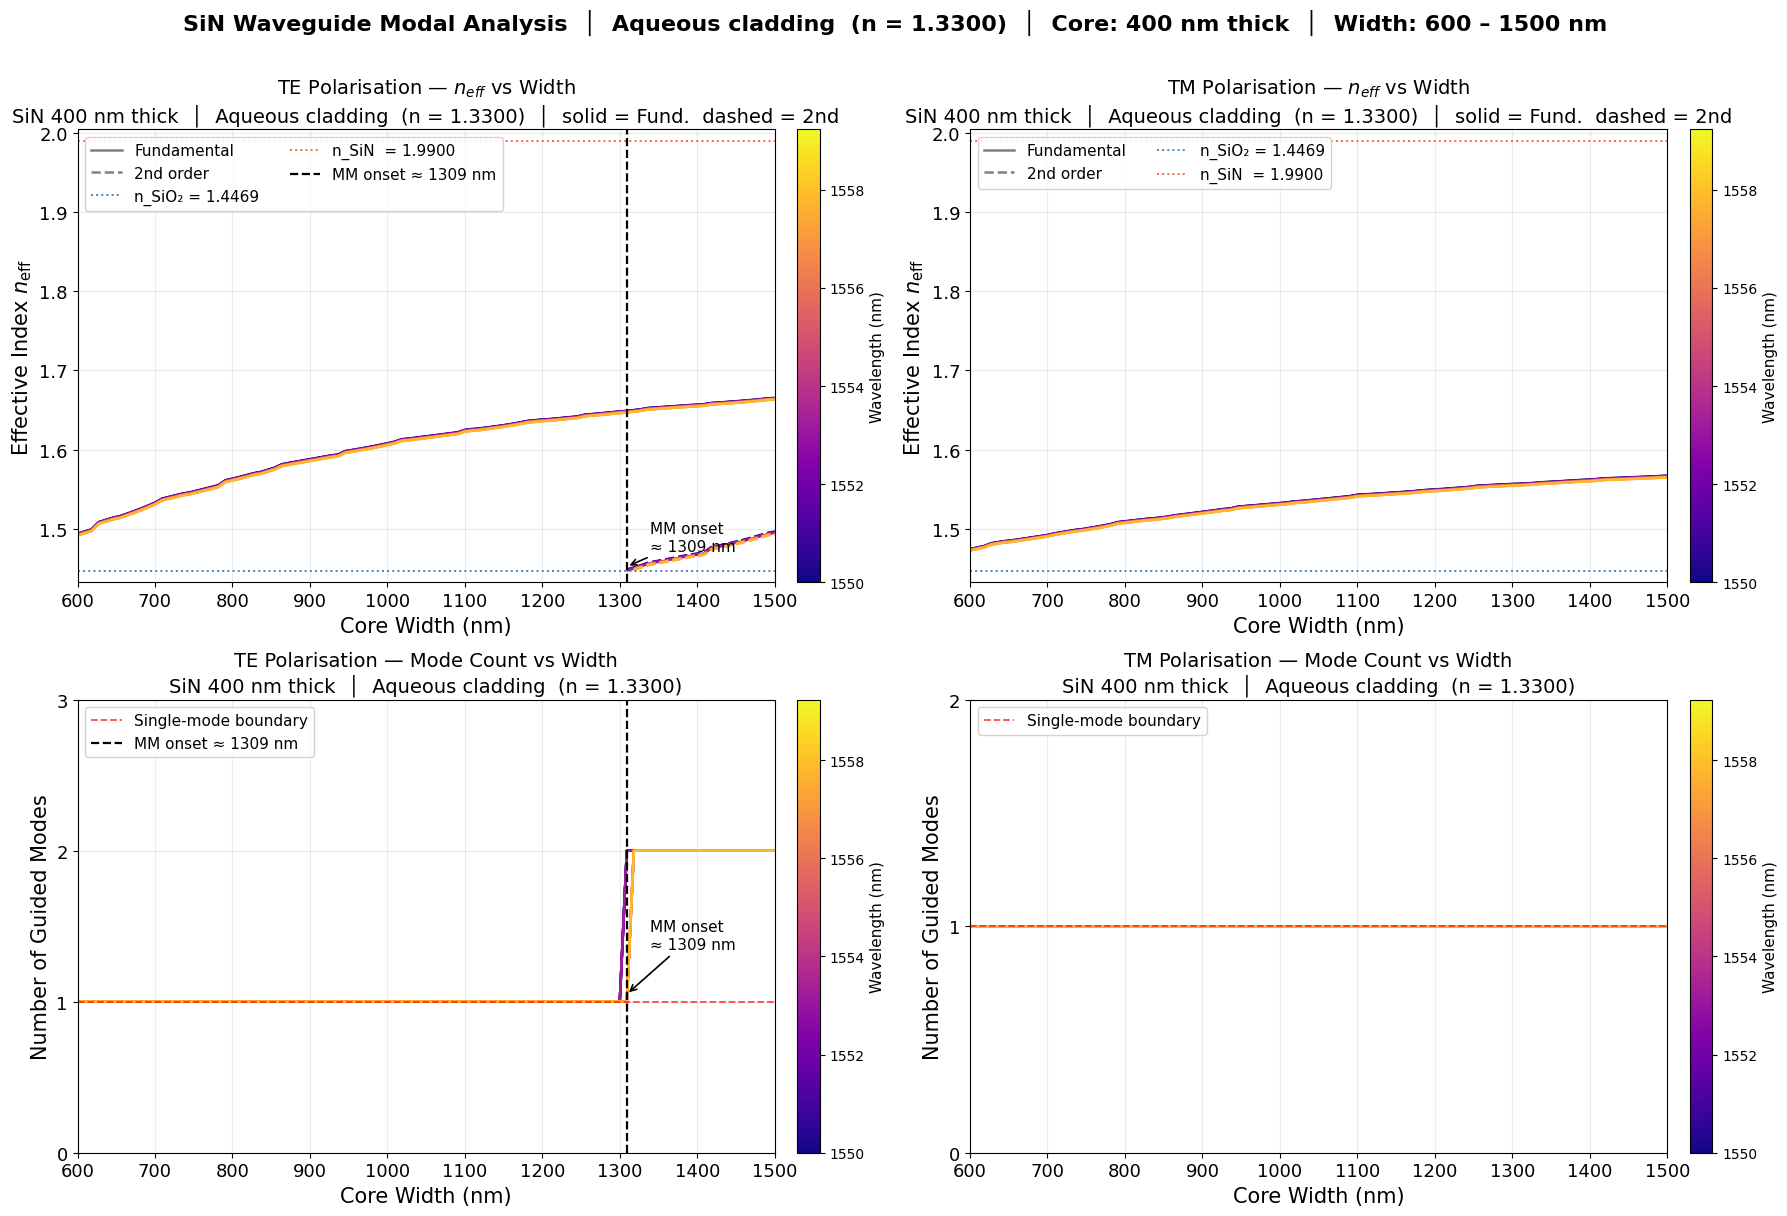


──────────────────────────────────────────────────────────────
  Plotting: Silica cladding
──────────────────────────────────────────────────────────────
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1_modal_analysis_sio2clad.png
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1_modal_analysis_sio2clad.pdf


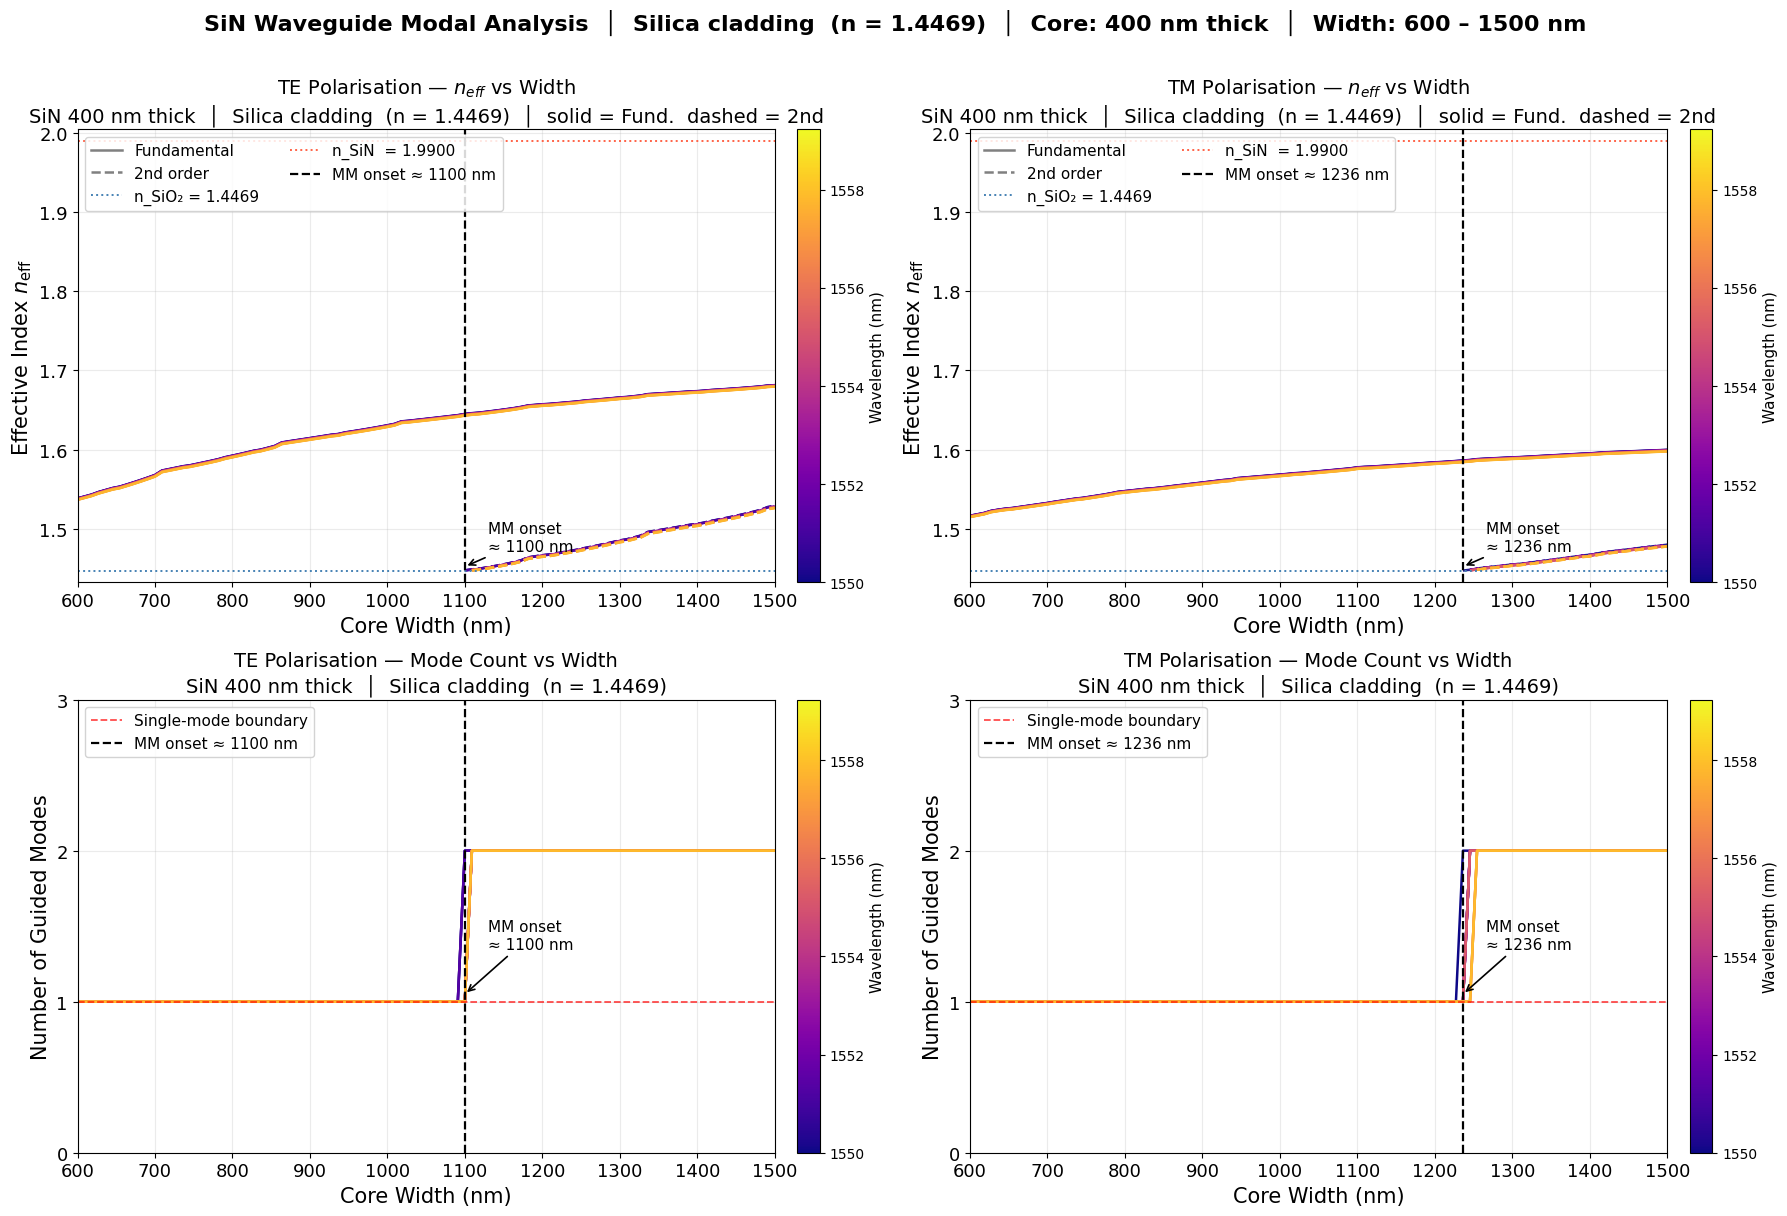

In [4]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Post-processing: TE/TM extraction for both cladding sweeps      ║
# ║                                                                             ║
# ║  ASSUMES CELLS 1–5 ALREADY EXECUTED.                                       ║
# ║  Reuses without redefining:                                                 ║
# ║    SWEEP_WIDTHS_UM, SWEEP_WL_NM, N_SIN_FIXED, N_SIO2_FIXED,               ║
# ║    N_UPPER_CLADDING, N_UPPER_CLADDING_SIO2, CORE_THICKNESS_UM,            ║
# ║    DATA_DIR, VERSION_NAME, VERSION_NAME_SIO2,                              ║
# ║    neff_real, te_frac, neff_real_sio2, te_frac_sio2,                      ║
# ║    sweep_widths_um, sweep_wl_nm                                            ║
# ║                                                                             ║
# ║  New in this cell:                                                          ║
# ║    matplotlib imports, plotting style constants,                            ║
# ║    extract_pol_data(), find_mm_cutoff_nm(),                                ║
# ║    pol_aq / pol_sio2 dicts                                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# ─────────────────────────────────────────────────────────────────────────────
# Plotting style constants  ─ consistent with Tidy3D notebook
# ─────────────────────────────────────────────────────────────────────────────
TE_THRESHOLD    = 0.5               # te_frac > threshold → TE, else TM
MAX_POL_MODES   = 2                 # track up to 2 modes per polarization
PLASMA_RANGE    = (0.0, 0.85)       # crop plasma to avoid bright yellow tip
LINESTYLES      = ['-', '--']       # fund. = solid, 2nd order = dashed
FIG_SIZE_2X2    = (18, 12)
FONT_SUPTITLE   = 16
FONT_TITLE      = 14
FONT_AXLABEL    = 15
FONT_TICK       = 13
FONT_LEGEND     = 11
FONT_CBAR       = 11
FONT_ANNOT      = 11
LEGEND_ALPHA    = 0.85
GRID_ALPHA      = 0.25
SAVE_DPI        = 150


# ─────────────────────────────────────────────────────────────────────────────
# Helper 1:  extract_pol_data
# ─────────────────────────────────────────────────────────────────────────────
def extract_pol_data(neff_real_arr, te_frac_arr, n_guided_cutoff,
                     te_threshold=TE_THRESHOLD, max_modes=MAX_POL_MODES):
    """
    Separate raw FDE mode arrays into TE and TM sub-arrays.

    Modes are visited in Lumerical's natural order (highest neff first).
    A mode qualifies if:
        (a)  Re(neff) > n_guided_cutoff      (guided — above SiO₂ cutoff)
        (b)  te_frac > te_threshold           (TE)
             te_frac ≤ te_threshold           (TM)

    Parameters
    ----------
    neff_real_arr   : np.ndarray  [n_w, n_wl, n_modes]  Re(neff) from FDE
    te_frac_arr     : np.ndarray  [n_w, n_wl, n_modes]  TE polarization fraction
    n_guided_cutoff : float    minimum neff for a guided mode (= N_SIO2_FIXED)
    te_threshold    : float    default 0.5
    max_modes       : int      max modes per polarization to store (default 2)

    Returns
    -------
    dict:
        neff_TE  np.ndarray  [n_w, n_wl, max_modes]  TE neff (NaN = absent)
        neff_TM  np.ndarray  [n_w, n_wl, max_modes]  TM neff
        n_TE     np.ndarray  [n_w, n_wl]  int   guided TE mode count
        n_TM     np.ndarray  [n_w, n_wl]  int   guided TM mode count
    """
    n_w, n_wl, n_mod = neff_real_arr.shape

    neff_TE = np.full((n_w, n_wl, max_modes), np.nan, dtype=np.float64)
    neff_TM = np.full((n_w, n_wl, max_modes), np.nan, dtype=np.float64)
    n_TE    = np.zeros((n_w, n_wl), dtype=np.int32)
    n_TM    = np.zeros((n_w, n_wl), dtype=np.int32)

    for w_i in range(n_w):
        for wl_i in range(n_wl):
            te_cnt = tm_cnt = 0
            for m_i in range(n_mod):
                ne = neff_real_arr[w_i, wl_i, m_i]
                tf = te_frac_arr  [w_i, wl_i, m_i]

                if np.isnan(ne):
                    break                           # no more modes at this point

                if ne <= n_guided_cutoff:
                    continue                        # non-guided; skip

                if tf > te_threshold:               # TE mode
                    if te_cnt < max_modes:
                        neff_TE[w_i, wl_i, te_cnt] = ne
                    te_cnt += 1
                else:                               # TM mode
                    if tm_cnt < max_modes:
                        neff_TM[w_i, wl_i, tm_cnt] = ne
                    tm_cnt += 1

            n_TE[w_i, wl_i] = te_cnt
            n_TM[w_i, wl_i] = tm_cnt

    return dict(neff_TE=neff_TE, neff_TM=neff_TM, n_TE=n_TE, n_TM=n_TM)


# ─────────────────────────────────────────────────────────────────────────────
# Helper 2:  find_mm_cutoff_nm
# ─────────────────────────────────────────────────────────────────────────────
def find_mm_cutoff_nm(n_pol_arr, sweep_widths_um):
    """
    Return the first waveguide width (nm) at which more than one guided mode
    exists for the given polarization across ANY wavelength in the sweep.

    Parameters
    ----------
    n_pol_arr      : [n_w, n_wl]  int   mode count per polarization
    sweep_widths_um: [n_w]        float  width array in µm

    Returns
    -------
    float (nm) if found, None otherwise.
    """
    for w_i in range(len(sweep_widths_um)):
        if np.any(n_pol_arr[w_i, :] > 1):
            return float(sweep_widths_um[w_i] * 1e3)
    return None


# ─────────────────────────────────────────────────────────────────────────────
# Extract polarization data for both sweeps
# n_guided_cutoff = N_SIO2_FIXED for both:
#   aqueous stack : SiO₂ is highest-index cladding → modes leak into SiO₂ first
#   silica  stack : both claddings are SiO₂         → same cutoff
# ─────────────────────────────────────────────────────────────────────────────
pol_aq   = extract_pol_data(neff_real,      te_frac,      N_SIO2_FIXED)
pol_sio2 = extract_pol_data(neff_real_sio2, te_frac_sio2, N_SIO2_FIXED)

# ─────────────────────────────────────────────────────────────────────────────
# Summary table
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 66)
print("  Post-processing summary — polarization-resolved mode analysis")
print(f"  Width : {sweep_widths_um[0]*1e3:.0f} → {sweep_widths_um[-1]*1e3:.0f} nm  "
      f"({len(sweep_widths_um)} pts)")
print(f"  λ     : {sweep_wl_nm[0]:.4f} → {sweep_wl_nm[-1]:.4f} nm  "
      f"({len(sweep_wl_nm)} pts,  Δλ = 10/13 nm)")
print("=" * 66)

for env_str, pd, n_uc in [
    (f"Aqueous  (n_upper = {N_UPPER_CLADDING})",    pol_aq,   N_UPPER_CLADDING),
    (f"Silica   (n_upper = {N_UPPER_CLADDING_SIO2:.4f})", pol_sio2, N_UPPER_CLADDING_SIO2),
]:
    c_TE = find_mm_cutoff_nm(pd["n_TE"], sweep_widths_um)
    c_TM = find_mm_cutoff_nm(pd["n_TM"], sweep_widths_um)

    print(f"\n  {env_str}")
    print(f"    TE  max modes = {int(pd['n_TE'].max())}  │  "
          + (f"MM cutoff ≈ {c_TE:.0f} nm" if c_TE else "single-mode across full sweep"))
    print(f"    TM  max modes = {int(pd['n_TM'].max())}  │  "
          + (f"MM cutoff ≈ {c_TM:.0f} nm" if c_TM else "single-mode across full sweep"))


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Publication plots: 2 × (2×2 figure)                             ║
# ║                                                                             ║
# ║  Reuses: pol_aq, pol_sio2, sweep_widths_um, sweep_wl_nm,                  ║
# ║           N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING, N_UPPER_CLADDING_SIO2 ║
# ║           CORE_THICKNESS_UM, DATA_DIR, VERSION_NAME, VERSION_NAME_SIO2    ║
# ║           all style constants from Cell 6                                   ║
# ║                                                                             ║
# ║  New: plot_modal_analysis()  (reusable for both environments)              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def plot_modal_analysis(
    pol_data,
    sweep_widths_um,
    sweep_wl_nm,
    n_core,
    n_lower_clad,
    n_upper_clad,
    core_thickness_nm,
    env_label,
    save_stem=None,
):
    """
    Generate a 2×2 publication-quality figure for one cladding environment.

    Subplot layout:
        [0,0]  TE   effective index  vs core width   (all wavelengths)
        [0,1]  TM   effective index  vs core width
        [1,0]  TE   guided mode count vs core width
        [1,1]  TM   guided mode count vs core width

    Styling matches the Tidy3D reference notebook:
        plasma colormap for wavelength curves
        solid line = fundamental,  dashed = 2nd order
        steelblue dotted = n_SiO₂ reference
        tomato   dotted = n_SiN  reference
        black dashed vertical = MM onset
        colorbar for wavelength encoding (replaces 13-entry λ legend)

    Parameters
    ----------
    pol_data          : dict  from extract_pol_data
    sweep_widths_um   : [n_w]  µm
    sweep_wl_nm       : [n_wl] nm
    n_core            : float  N_SIN_FIXED
    n_lower_clad      : float  N_SIO2_FIXED
    n_upper_clad      : float  N_UPPER_CLADDING or N_UPPER_CLADDING_SIO2
    core_thickness_nm : float  waveguide height in nm
    env_label         : str    e.g. "Aqueous" or "Silica"
    save_stem         : str or Path or None
                        If given, saves  <save_stem>.png  and  <save_stem>.pdf

    Returns
    -------
    matplotlib.figure.Figure
    """
    neff_TE   = pol_data["neff_TE"]      # [n_w, n_wl, MAX_POL_MODES]
    neff_TM   = pol_data["neff_TM"]
    n_TE_arr  = pol_data["n_TE"]         # [n_w, n_wl]  int
    n_TM_arr  = pol_data["n_TM"]

    n_wl       = len(sweep_wl_nm)
    widths_nm  = sweep_widths_um * 1e3   # µm → nm for x-axis

    # Plasma colormap — one colour per wavelength, consistent with Tidy3D nb
    colors     = plt.cm.plasma(np.linspace(PLASMA_RANGE[0], PLASMA_RANGE[1], n_wl))

    # MM cutoff widths
    cutoff_TE_nm = find_mm_cutoff_nm(n_TE_arr, sweep_widths_um)
    cutoff_TM_nm = find_mm_cutoff_nm(n_TM_arr, sweep_widths_um)

    # ── Figure and axes ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=FIG_SIZE_2X2)

    # ── Shared colorbar setup (wavelength encoding) ───────────────────────────
    _cbar_norm = Normalize(vmin=sweep_wl_nm[0], vmax=sweep_wl_nm[-1])
    _cbar_sm   = cm.ScalarMappable(cmap='plasma', norm=_cbar_norm)
    _cbar_sm.set_array([])

    # ═════════════════════════════════════════════════════════════════════════
    # Inner helper: neff subplot
    # ═════════════════════════════════════════════════════════════════════════
    def _neff_ax(ax, neff_arr, cutoff_nm, pol_str):
        # ── Curve per (wavelength × mode order) ──────────────────────────────
        for wl_i, wl_val in enumerate(sweep_wl_nm):
            col = colors[wl_i]
            for m_i, ls in enumerate(LINESTYLES):
                y = neff_arr[:, wl_i, m_i]
                if np.all(np.isnan(y)):
                    continue
                ax.plot(
                    widths_nm, y,
                    color=col, linewidth=1.8, linestyle=ls,
                    alpha=0.9, label="_nolegend_",
                )

        # ── Reference lines (identical to Tidy3D notebook) ───────────────────
        ax.axhline(n_lower_clad, color='steelblue', linestyle=':', linewidth=1.4,
                   label=f"n_SiO₂ = {n_lower_clad:.4f}")
        ax.axhline(n_core,       color='tomato',    linestyle=':', linewidth=1.4,
                   label=f"n_SiN  = {n_core:.4f}")

        # ── MM cutoff annotation ──────────────────────────────────────────────
        if cutoff_nm is not None:
            ax.axvline(cutoff_nm, color='black', linestyle='--', linewidth=1.6,
                       label=f"MM onset ≈ {cutoff_nm:.0f} nm")
            ax.annotate(
                f"MM onset\n≈ {cutoff_nm:.0f} nm",
                xy         = (cutoff_nm, n_lower_clad + 0.005),
                xytext     = (cutoff_nm + 30, n_lower_clad + 0.025),
                fontsize   = FONT_ANNOT,
                color      = "black",
                arrowprops = dict(arrowstyle="->", color="black", lw=1.2),
            )

        # ── Axis formatting (exact Tidy3D values) ─────────────────────────────
        ax.set_ylim(n_lower_clad - 0.015, n_core + 0.015)
        ax.set_xlim(widths_nm[0], widths_nm[-1])
        ax.set_xlabel("Core Width (nm)",                   fontsize=FONT_AXLABEL)
        ax.set_ylabel(r"Effective Index $n_\mathrm{eff}$", fontsize=FONT_AXLABEL)
        ax.tick_params(axis="both", labelsize=FONT_TICK)
        ax.set_title(
            f"{pol_str} Polarisation — $n_{{eff}}$ vs Width\n"
            f"SiN {core_thickness_nm:.0f} nm thick  │  {env_label} cladding  "
            f"(n = {n_upper_clad:.4f})  │  solid = Fund.  dashed = 2nd",
            fontsize=FONT_TITLE,
        )
        ax.grid(True, alpha=GRID_ALPHA)

        # ── Legend: line-style proxies + reference lines ──────────────────────
        proxy_handles = [
            Line2D([0],[0], color="gray",      linewidth=1.8, linestyle="-",
                   label="Fundamental"),
            Line2D([0],[0], color="gray",      linewidth=1.8, linestyle="--",
                   label="2nd order"),
            Line2D([0],[0], color="steelblue", linewidth=1.4, linestyle=":",
                   label=f"n_SiO₂ = {n_lower_clad:.4f}"),
            Line2D([0],[0], color="tomato",    linewidth=1.4, linestyle=":",
                   label=f"n_SiN  = {n_core:.4f}"),
        ]
        if cutoff_nm is not None:
            proxy_handles.append(
                Line2D([0],[0], color="black", linewidth=1.6, linestyle="--",
                       label=f"MM onset ≈ {cutoff_nm:.0f} nm")
            )
        ax.legend(handles=proxy_handles, fontsize=FONT_LEGEND,
                  ncol=2, loc="upper left", framealpha=LEGEND_ALPHA)

        # ── Wavelength colorbar ───────────────────────────────────────────────
        cbar = fig.colorbar(_cbar_sm, ax=ax, fraction=0.035, pad=0.03)
        cbar.set_label("Wavelength (nm)", fontsize=FONT_CBAR)
        cbar.ax.tick_params(labelsize=FONT_CBAR - 1)

    # ═════════════════════════════════════════════════════════════════════════
    # Inner helper: mode-count subplot
    # ═════════════════════════════════════════════════════════════════════════
    def _count_ax(ax, n_pol, cutoff_nm, pol_str):
        # ── Curve per wavelength ──────────────────────────────────────────────
        for wl_i, wl_val in enumerate(sweep_wl_nm):
            ax.plot(
                widths_nm, n_pol[:, wl_i],
                color=colors[wl_i], linewidth=1.8,
                label="_nolegend_",
            )

        # ── Single-mode boundary ──────────────────────────────────────────────
        ax.axhline(1, color="red", linestyle="--", linewidth=1.3,
                   alpha=0.7, label="Single-mode boundary")

        # ── MM cutoff ─────────────────────────────────────────────────────────
        if cutoff_nm is not None:
            ax.axvline(cutoff_nm, color="black", linestyle="--", linewidth=1.6,
                       label=f"MM onset ≈ {cutoff_nm:.0f} nm")
            ax.annotate(
                f"MM onset\n≈ {cutoff_nm:.0f} nm",
                xy         = (cutoff_nm, 1.05),
                xytext     = (cutoff_nm + 30, 1.35),
                fontsize   = FONT_ANNOT,
                color      = "black",
                arrowprops = dict(arrowstyle="->", color="black", lw=1.2),
            )

        # ── Axis formatting ───────────────────────────────────────────────────
        max_cnt = int(n_pol.max()) if n_pol.max() > 0 else 2
        ax.set_xlim(widths_nm[0], widths_nm[-1])
        ax.set_ylim(0, max_cnt + 1)
        ax.set_yticks(range(0, max_cnt + 2))
        ax.set_xlabel("Core Width (nm)",          fontsize=FONT_AXLABEL)
        ax.set_ylabel("Number of Guided Modes",   fontsize=FONT_AXLABEL)
        ax.tick_params(axis="both", labelsize=FONT_TICK)
        ax.set_title(
            f"{pol_str} Polarisation — Mode Count vs Width\n"
            f"SiN {core_thickness_nm:.0f} nm thick  │  {env_label} cladding  "
            f"(n = {n_upper_clad:.4f})",
            fontsize=FONT_TITLE,
        )
        ax.grid(True, alpha=GRID_ALPHA)

        # ── Legend: reference lines only ──────────────────────────────────────
        proxy_handles = [
            Line2D([0],[0], color="red",   linewidth=1.3, linestyle="--",
                   alpha=0.7, label="Single-mode boundary"),
        ]
        if cutoff_nm is not None:
            proxy_handles.append(
                Line2D([0],[0], color="black", linewidth=1.6, linestyle="--",
                       label=f"MM onset ≈ {cutoff_nm:.0f} nm")
            )
        ax.legend(handles=proxy_handles, fontsize=FONT_LEGEND,
                  loc="upper left", framealpha=LEGEND_ALPHA)

        # ── Wavelength colorbar ───────────────────────────────────────────────
        cbar = fig.colorbar(_cbar_sm, ax=ax, fraction=0.035, pad=0.03)
        cbar.set_label("Wavelength (nm)", fontsize=FONT_CBAR)
        cbar.ax.tick_params(labelsize=FONT_CBAR - 1)

    # ── Draw the four subplots ────────────────────────────────────────────────
    _neff_ax (axes[0, 0], neff_TE,  cutoff_TE_nm, "TE")
    _neff_ax (axes[0, 1], neff_TM,  cutoff_TM_nm, "TM")
    _count_ax(axes[1, 0], n_TE_arr, cutoff_TE_nm, "TE")
    _count_ax(axes[1, 1], n_TM_arr, cutoff_TM_nm, "TM")

    fig.suptitle(
        f"SiN Waveguide Modal Analysis  │  {env_label} cladding  "
        f"(n = {n_upper_clad:.4f})  │  "
        f"Core: {core_thickness_nm:.0f} nm thick  │  "
        f"Width: {widths_nm[0]:.0f} – {widths_nm[-1]:.0f} nm",
        fontsize=FONT_SUPTITLE, fontweight="bold", y=1.01,
    )
    plt.tight_layout()

    if save_stem is not None:
        for ext in (".png", ".pdf"):
            out = str(save_stem) + ext
            plt.savefig(out, dpi=SAVE_DPI, bbox_inches="tight")
            print(f"  Saved → {out}")

    plt.show()
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# Execute: aqueous cladding
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 62)
print("  Plotting: Aqueous cladding")
print("─" * 62)

fig_aq = plot_modal_analysis(
    pol_data          = pol_aq,
    sweep_widths_um   = sweep_widths_um,
    sweep_wl_nm       = sweep_wl_nm,
    n_core            = N_SIN_FIXED,
    n_lower_clad      = N_SIO2_FIXED,
    n_upper_clad      = N_UPPER_CLADDING,
    core_thickness_nm = CORE_THICKNESS_UM * 1e3,
    env_label         = "Aqueous",
    save_stem         = DATA_DIR / f"{VERSION_NAME}_modal_analysis_aqueous",
)

# ─────────────────────────────────────────────────────────────────────────────
# Execute: silica cladding
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "─" * 62)
print("  Plotting: Silica cladding")
print("─" * 62)

fig_sio2 = plot_modal_analysis(
    pol_data          = pol_sio2,
    sweep_widths_um   = sweep_widths_um,
    sweep_wl_nm       = sweep_wl_nm,
    n_core            = N_SIN_FIXED,
    n_lower_clad      = N_SIO2_FIXED,
    n_upper_clad      = N_UPPER_CLADDING_SIO2,
    core_thickness_nm = CORE_THICKNESS_UM * 1e3,
    env_label         = "Silica",
    save_stem         = DATA_DIR / f"{VERSION_NAME_SIO2}_modal_analysis_sio2clad",
)

18:58:58 │ INFO │ Ring sweep cache found → ring_radius_sweep/rr_10nm_1550nm_1000nm_18.0-20.0um_100pts
18:58:58 │ INFO │ Cached: 100/100  |  Remaining: 0
18:58:58 │ INFO │ All radii already computed — skipping FDE entirely.
18:58:58 │ INFO │ HDF5 closed  →  D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1.h5


  Ring Resonator — Radius Sweep for FSR Matching
  Target FSR           : 10.00 nm
  Resonance wavelength : 1550.0 nm
  Waveguide width      : 1000 nm
  Waveguide height     : 400 nm
  n_core               : 1.99   (N_SIN_FIXED)
  n_lower_clad         : 1.4469  (N_SIO2_FIXED)
  n_upper_clad         : 1.33   (N_UPPER_CLADDING)
  Required ng·L        : 240.2500 µm
  ng stencil           : ±5.0 nm  (300 FDE solves if uncached)
  Radius sweep         : 18.0 – 20.0 µm  (100 pts)
  HDF5 group           : ring_radius_sweep/rr_10nm_1550nm_1000nm_18.0-20.0um_100pts
  HDF5 file            : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1.h5

 Radius (µm)        neff          ng   TE frac     ng·L (µm)    Δ/target    source
----------------------------------------------------------------------------------
       18.00      1.6127      1.7218     1.000      194.7258     -18.95%     cache
       18.02      1.6124      

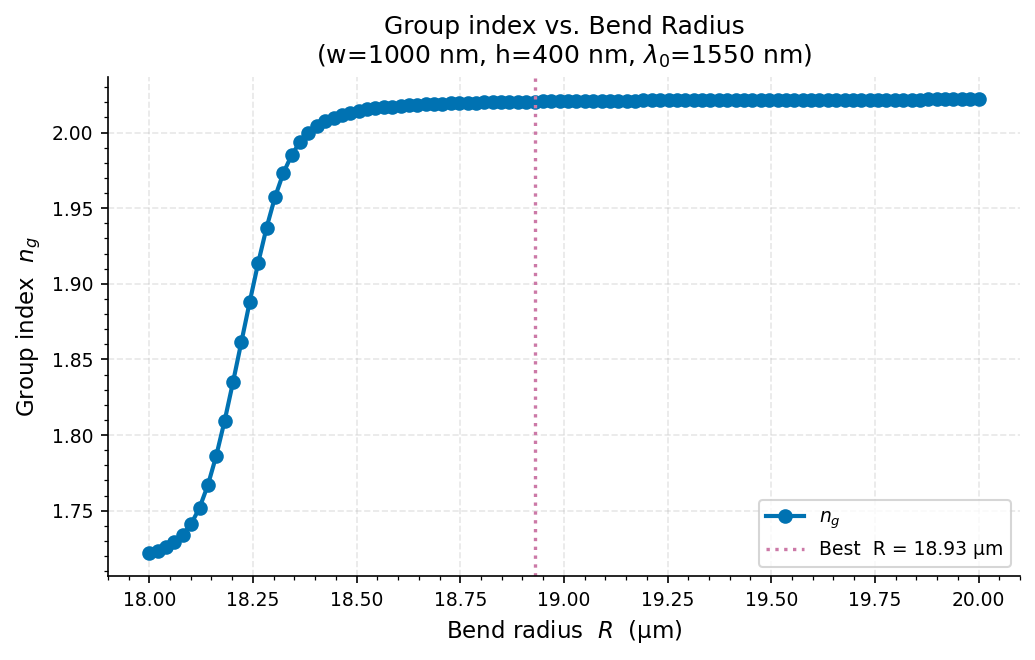

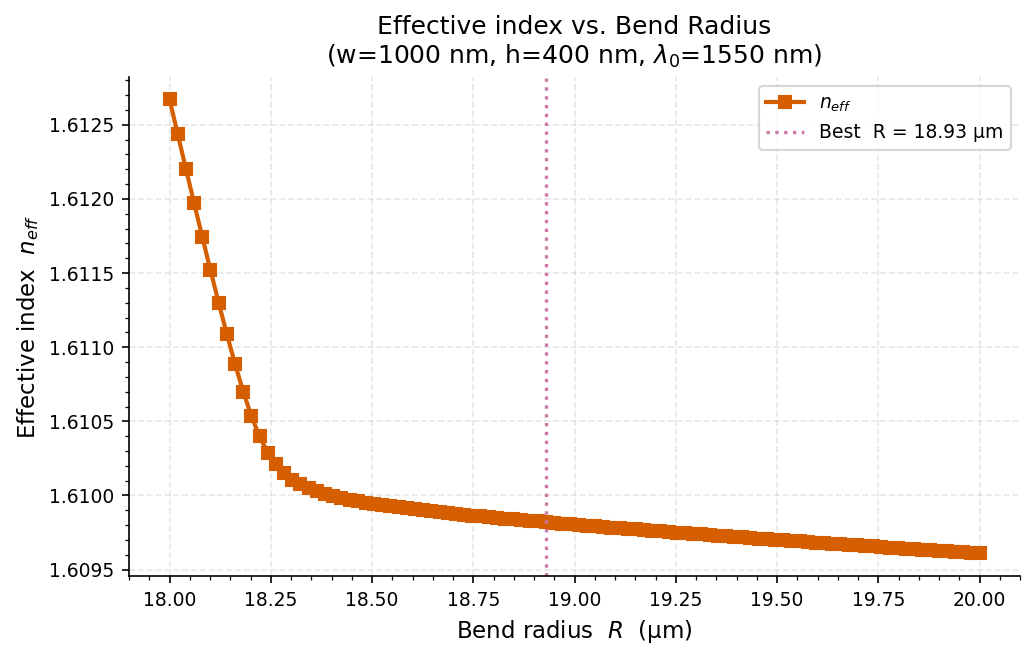

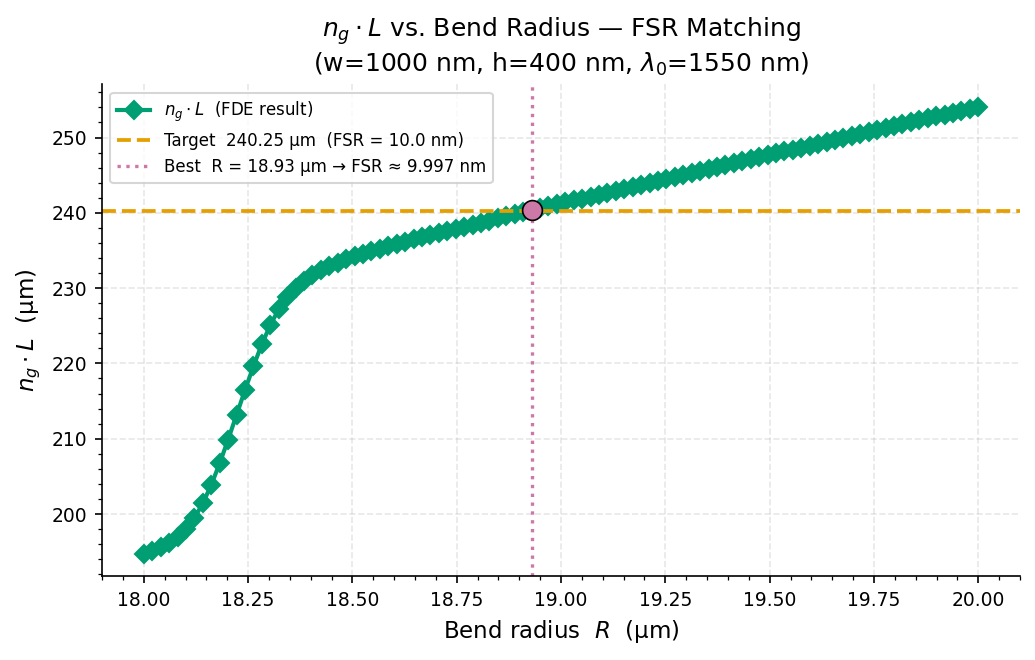


  Cached in : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1.h5
  HDF5 group: ring_radius_sweep/rr_10nm_1550nm_1000nm_18.0-20.0um_100pts

  Variables exported to the next cell:
    rr_best_R_um   = 18.9293   # µm
    rr_best_L_um   = 118.9363   # µm
    rr_best_neff   = 1.609820
    rr_best_ng     = 2.020543
    rr_FSR_pred_nm = 9.9973   # nm


In [5]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Ring Resonator Radius Sweep for FSR Matching                     ║
# ║           with HDF5 caching identical to Cells 1-3                         ║
# ║                                                                            ║
# ║  Requires from earlier cells (already in kernel scope):                    ║
# ║    lumapi, np, h5py, log, time, Path, datetime                             ║
# ║    DATA_DIR, HDF5_PATH, VERSION_NAME                                       ║
# ║    N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING, CORE_THICKNESS_UM         ║
# ║    SIM_Y_SPAN_UM, SIM_Z_BELOW_UM, SIM_Z_ABOVE_UM                          ║
# ║    MESH_CELLS_Y, MESH_CELLS_Z, N_MODES_REQUEST                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ─────────────────────────────────────────────────────────────────────────────
# RING DESIGN TARGETS  ← edit only these three lines
# ─────────────────────────────────────────────────────────────────────────────
RR_FSR_NM      = 10.0      # [nm]  target free spectral range
RR_LAM0_NM     = 1550.0    # [nm]  resonance wavelength
RR_WG_WIDTH_NM = 1000.0    # [nm]  waveguide width  (height = CORE_THICKNESS_UM)

# ─────────────────────────────────────────────────────────────────────────────
# RADIUS SWEEP RANGE
# ─────────────────────────────────────────────────────────────────────────────
RR_R_MIN_UM  = 18.0    # [µm]
RR_R_MAX_UM  = 20.0   # [µm]
RR_N_RADII   = 100

# ─────────────────────────────────────────────────────────────────────────────
# ng FINITE-DIFFERENCE STENCIL
#   ng = neff(λ₀) − λ₀ · [neff(λ₀+ΔΛ) − neff(λ₀−ΔΛ)] / (2·ΔΛ)
# ─────────────────────────────────────────────────────────────────────────────
_RR_DELTA_LAM_NM = 5.0   # [nm]  half-span for central difference

# ─────────────────────────────────────────────────────────────────────────────
# HDF5 STORAGE
#   Results are stored as a NEW GROUP inside the existing HDF5 file produced
#   by Cells 1-3 (HDF5_PATH / DATA_DIR already in scope).
#   Group key encodes the sweep parameters so different sweeps never collide.
#
#   Layout inside the existing .h5 file:
#
#   ring_radius_sweep/
#     <group_key>/                    ← one group per unique sweep config
#       metadata/
#         attrs:  fsr_nm, lam0_nm, wg_width_nm, wg_height_nm,
#                 r_min_um, r_max_um, n_radii, delta_lam_nm,
#                 n_SiN, n_SiO2, n_upper_clad,
#                 timestamp_start, timestamp_end
#         datasets: radii_um           [n_radii]
#                   lam_stencil_nm     [3]        (lo, centre, hi)
#       results/
#         neff       [n_radii]   float64  — at λ₀
#         ng         [n_radii]   float64  — central-difference group index
#         te_frac    [n_radii]   float64  — TE polarisation fraction at λ₀
#         ngL_um     [n_radii]   float64  — ng × 2πR  [µm]
#         neff_lo    [n_radii]   float64  — neff at λ₀−ΔΛ  (stencil raw data)
#         neff_hi    [n_radii]   float64  — neff at λ₀+ΔΛ
#       flags/
#         computed   [n_radii]   bool     — True once a radius row is done
# ─────────────────────────────────────────────────────────────────────────────

# ── Group key — uniquely identifies this sweep configuration ─────────────────
# Format:  rr_<fsr>nm_<lam0>nm_<width>nm_<Rmin>-<Rmax>um_<N>pts
# Example: rr_10nm_1550nm_1000nm_2.0-20.0um_19pts
_RR_GROUP_KEY = (
    f"rr_{RR_FSR_NM:.0f}nm_{RR_LAM0_NM:.0f}nm_"
    f"{RR_WG_WIDTH_NM:.0f}nm_"
    f"{RR_R_MIN_UM:.1f}-{RR_R_MAX_UM:.1f}um_{RR_N_RADII}pts"
)
_RR_HDF5_GROUP = f"ring_radius_sweep/{_RR_GROUP_KEY}"

# ─────────────────────────────────────────────────────────────────────────────
# DERIVED CONSTANTS  (do not edit)
# ─────────────────────────────────────────────────────────────────────────────
_lam0_m   = RR_LAM0_NM * 1e-9
_lam_lo_m = (RR_LAM0_NM - _RR_DELTA_LAM_NM) * 1e-9
_lam_hi_m = (RR_LAM0_NM + _RR_DELTA_LAM_NM) * 1e-9
_dlam_m   = 2.0 * _RR_DELTA_LAM_NM * 1e-9

_FSR_m    = RR_FSR_NM * 1e-9
_wg_w_m   = RR_WG_WIDTH_NM * 1e-9
_core_t_um = CORE_THICKNESS_UM

_target_ngL_m  = _lam0_m**2 / _FSR_m
_target_ngL_um = _target_ngL_m * 1e6

# Domain geometry — identical to _init_fde_geometry in Cell 2
_sim_y_span_um  = SIM_Y_SPAN_UM
_sim_z_below_um = SIM_Z_BELOW_UM
_sim_z_above_um = SIM_Z_ABOVE_UM
_sim_z_span_um  = _sim_z_below_um + _core_t_um + _sim_z_above_um
_half_t_um      = _core_t_um / 2.0
_sio2_z_ctr_um  = -(_half_t_um + _sim_z_below_um / 2.0)
_sio2_z_span_um = _sim_z_below_um
_sim_z_ctr_um   = (_sim_z_above_um - _sim_z_below_um) / 2.0

_radii_um = np.linspace(RR_R_MIN_UM, RR_R_MAX_UM, RR_N_RADII)
_radii_m  = _radii_um * 1e-6
_N        = RR_N_RADII

print("=" * 65)
print("  Ring Resonator — Radius Sweep for FSR Matching")
print("=" * 65)
print(f"  Target FSR           : {RR_FSR_NM:.2f} nm")
print(f"  Resonance wavelength : {RR_LAM0_NM:.1f} nm")
print(f"  Waveguide width      : {RR_WG_WIDTH_NM:.0f} nm")
print(f"  Waveguide height     : {_core_t_um*1e3:.0f} nm")
print(f"  n_core               : {N_SIN_FIXED}   (N_SIN_FIXED)")
print(f"  n_lower_clad         : {N_SIO2_FIXED}  (N_SIO2_FIXED)")
print(f"  n_upper_clad         : {N_UPPER_CLADDING}   (N_UPPER_CLADDING)")
print(f"  Required ng·L        : {_target_ngL_um:.4f} µm")
print(f"  ng stencil           : ±{_RR_DELTA_LAM_NM:.1f} nm  ({_N*3} FDE solves if uncached)")
print(f"  Radius sweep         : {RR_R_MIN_UM:.1f} – {RR_R_MAX_UM:.1f} µm  ({_N} pts)")
print(f"  HDF5 group           : {_RR_HDF5_GROUP}")
print(f"  HDF5 file            : {HDF5_PATH}")
print("=" * 65)


# ─────────────────────────────────────────────────────────────────────────────
# HDF5 HELPER — initialise the group for this sweep inside the existing file
# ─────────────────────────────────────────────────────────────────────────────
def _rr_init_hdf5(hf) -> None:
    """
    Create ring_radius_sweep/<group_key>/ inside an already-open h5py file
    opened in 'r+' or 'a' mode.  Pre-allocates all datasets with NaN / False.
    Mirrors the structure of _init_hdf5 from Cell 2 exactly.
    """
    g = hf.require_group(_RR_HDF5_GROUP)

    # ── metadata ─────────────────────────────────────────────────────────────
    mg = g.require_group("metadata")
    mg.attrs["fsr_nm"]         = RR_FSR_NM
    mg.attrs["lam0_nm"]        = RR_LAM0_NM
    mg.attrs["wg_width_nm"]    = RR_WG_WIDTH_NM
    mg.attrs["wg_height_nm"]   = _core_t_um * 1e3
    mg.attrs["r_min_um"]       = RR_R_MIN_UM
    mg.attrs["r_max_um"]       = RR_R_MAX_UM
    mg.attrs["n_radii"]        = _N
    mg.attrs["delta_lam_nm"]   = _RR_DELTA_LAM_NM
    mg.attrs["n_SiN"]          = N_SIN_FIXED
    mg.attrs["n_SiO2"]         = N_SIO2_FIXED
    mg.attrs["n_upper_clad"]   = N_UPPER_CLADDING
    mg.attrs["version_name"]   = VERSION_NAME
    mg.attrs["timestamp_start"] = datetime.now().isoformat()

    # axis coordinate arrays
    if "radii_um" not in mg:
        mg.create_dataset("radii_um",       data=_radii_um)
    if "lam_stencil_nm" not in mg:
        mg.create_dataset("lam_stencil_nm",
                          data=np.array([RR_LAM0_NM - _RR_DELTA_LAM_NM,
                                         RR_LAM0_NM,
                                         RR_LAM0_NM + _RR_DELTA_LAM_NM]))

    # ── results — NaN-initialised, chunked per radius row ────────────────────
    rg = g.require_group("results")
    _nan = np.full(_N, np.nan, dtype=np.float64)
    for ds_name in ("neff", "ng", "te_frac", "ngL_um", "neff_lo", "neff_hi"):
        if ds_name not in rg:
            rg.create_dataset(ds_name, data=_nan.copy(), chunks=(_N,))

    # ── progress flag ─────────────────────────────────────────────────────────
    fg = g.require_group("flags")
    if "computed" not in fg:
        fg.create_dataset("computed",
                          data=np.zeros(_N, dtype=bool),
                          chunks=(_N,))


# ─────────────────────────────────────────────────────────────────────────────
# HDF5 HELPER — load existing cache into memory arrays
# ─────────────────────────────────────────────────────────────────────────────
def _rr_load_cache(hf,
                   neff_arr, ng_arr, te_arr,
                   ngL_arr, neff_lo_arr, neff_hi_arr,
                   computed) -> int:
    """
    Read ring_radius_sweep/<group_key>/ from an open h5py file into the
    pre-allocated in-memory arrays.  Returns number of cached points.
    All arrays are modified in-place.
    """
    g  = hf[_RR_HDF5_GROUP]
    rg = g["results"]
    fg = g["flags"]

    neff_arr[:]    = rg["neff"][:]
    ng_arr[:]      = rg["ng"][:]
    te_arr[:]      = rg["te_frac"][:]
    ngL_arr[:]     = rg["ngL_um"][:] * 1e-6   # stored in µm, keep in m here
    neff_lo_arr[:] = rg["neff_lo"][:]
    neff_hi_arr[:] = rg["neff_hi"][:]
    computed[:]    = fg["computed"][:]

    return int(computed.sum())


# ─────────────────────────────────────────────────────────────────────────────
# FDE HELPERS  (unchanged from working version)
# ─────────────────────────────────────────────────────────────────────────────
def _rr_build_fde(mode, radius_m: float, wavelength_m: float) -> None:
    """Build bent waveguide cross-section + FDE solver for one (R, λ) point."""
    m = mode
    m.switchtolayout()
    m.selectall()
    m.delete()

    m.addfde()
    m.set("solver type",           "2D X normal")
    m.set("x",                     0.0)
    m.set("y",                     0.0)
    m.set("z",                     _sim_z_ctr_um  * 1e-6)
    m.set("y span",                _sim_y_span_um * 1e-6)
    m.set("z span",                _sim_z_span_um * 1e-6)
    m.set("wavelength",            wavelength_m)
    m.set("number of trial modes", N_MODES_REQUEST)
    m.set("mesh cells y",          MESH_CELLS_Y)
    m.set("mesh cells z",          MESH_CELLS_Z)
    m.set("bent waveguide",        1)
    m.set("bend radius",           radius_m)
    m.set("bend orientation",      0)

    m.addrect()
    m.set("name",    "RR_bg")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", _sim_y_span_um * 1e-6)
    m.set("z",       _sim_z_ctr_um  * 1e-6)
    m.set("z span",  _sim_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_UPPER_CLADDING)

    m.addrect()
    m.set("name",    "RR_lower_clad")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", _sim_y_span_um  * 1e-6)
    m.set("z",       _sio2_z_ctr_um * 1e-6)
    m.set("z span",  _sio2_z_span_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIO2_FIXED)

    m.addrect()
    m.set("name",    "RR_core")
    m.set("x",       0.0);  m.set("x span", 1.0e-6)
    m.set("y",       0.0);  m.set("y span", _wg_w_m)
    m.set("z",       0.0);  m.set("z span", _core_t_um * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIN_FIXED)


def _rr_solve_neff(mode, radius_m: float, wavelength_m: float):
    """Single FDE solve → (Re(neff), TE fraction) for mode 1."""
    _rr_build_fde(mode, radius_m, wavelength_m)
    mode.run()
    mode.findmodes()
    raw_neff = mode.getdata("FDE::data::mode1", "neff")
    raw_te   = mode.getdata("FDE::data::mode1", "TE polarization fraction")
    neff_c   = complex(np.asarray(raw_neff).flat[0])
    te_v     = float(np.asarray(raw_te).flat[0])
    return neff_c.real, te_v


def _rr_neff_ng(mode, radius_m: float):
    """
    Three-point central-difference ng at lam0 for a given bend radius.
    Returns (neff_at_lam0, ng, te_frac, neff_lo, neff_hi).
    """
    neff_lo, _    = _rr_solve_neff(mode, radius_m, _lam_lo_m)
    neff_0,  te_v = _rr_solve_neff(mode, radius_m, _lam0_m)
    neff_hi, _    = _rr_solve_neff(mode, radius_m, _lam_hi_m)
    dneff_dlam    = (neff_hi - neff_lo) / _dlam_m
    ng            = neff_0 - _lam0_m * dneff_dlam
    return neff_0, ng, te_v, neff_lo, neff_hi


# ─────────────────────────────────────────────────────────────────────────────
# IN-MEMORY ARRAYS  (NaN-initialised; overwritten by cache or FDE)
# ─────────────────────────────────────────────────────────────────────────────
_neff_arr    = np.full(_N, np.nan)
_ng_arr      = np.full(_N, np.nan)
_te_arr      = np.full(_N, np.nan)
_ngL_arr     = np.full(_N, np.nan)   # [m]
_neff_lo_arr = np.full(_N, np.nan)
_neff_hi_arr = np.full(_N, np.nan)
_computed    = np.zeros(_N, dtype=bool)


# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — HDF5 CACHE CHECK
#   Open the existing file in append mode ('a').
#   If our group is already there, load what is cached.
#   If the group is missing, create it now.
#   Either way the file stays open for the sweep loop below.
# ─────────────────────────────────────────────────────────────────────────────
_hf = h5py.File(HDF5_PATH, "a")   # 'a' = read/write, create if missing

if _RR_HDF5_GROUP in _hf:
    log.info(f"Ring sweep cache found → {_RR_HDF5_GROUP}")
    _n_cached = _rr_load_cache(
        _hf,
        _neff_arr, _ng_arr, _te_arr,
        _ngL_arr, _neff_lo_arr, _neff_hi_arr,
        _computed,
    )
    _remaining = _N - _n_cached
    log.info(f"Cached: {_n_cached}/{_N}  |  Remaining: {_remaining}")
    if _remaining == 0:
        log.info("All radii already computed — skipping FDE entirely.")
else:
    log.info(f"No ring sweep cache found — initialising group: {_RR_HDF5_GROUP}")
    _rr_init_hdf5(_hf)
    _hf.flush()
    _n_cached  = 0
    _remaining = _N


# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — FDE SWEEP  (skipped entirely when all radii are cached)
# ─────────────────────────────────────────────────────────────────────────────
_hdr = (f"{'Radius (µm)':>12}  {'neff':>10}  {'ng':>10}  "
        f"{'TE frac':>8}  {'ng·L (µm)':>12}  {'Δ/target':>10}  {'source':>8}")
print(f"\n{_hdr}")
print("-" * len(_hdr))

# Print already-cached rows first so the table is complete
for _i in range(_N):
    if _computed[_i]:
        _ngL_m = _ngL_arr[_i]
        _delta  = (_ngL_m - _target_ngL_m) / _target_ngL_m * 100.0
        print(f"  {_radii_um[_i]:>10.2f}  {_neff_arr[_i]:>10.4f}  "
              f"{_ng_arr[_i]:>10.4f}  {_te_arr[_i]:>8.3f}  "
              f"{_ngL_m*1e6:>12.4f}  {_delta:>+9.2f}%  {'cache':>8}")

if _remaining > 0:
    _runs_done = 0
    _t0 = time.time()
    log.info(f"Launching MODE session  ({_remaining} radii to compute) …")
    _rr_mode = lumapi.MODE(hide=False)

    try:
        for _i, (_R_um, _R_m) in enumerate(zip(_radii_um, _radii_m)):
            if _computed[_i]:
                continue   # already in cache — skip

            try:
                _neff_v, _ng_v, _te_v, _nlo, _nhi = _rr_neff_ng(_rr_mode, _R_m)
            except Exception as _exc:
                log.warning(f"  R = {_R_um:6.2f} µm  FAILED: {_exc}")
                # Mark as done with NaN so a re-run doesn't retry a broken radius
                _computed[_i] = True
                _hf[f"{_RR_HDF5_GROUP}/flags/computed"][_i] = True
                _hf.flush()
                continue

            _L_m   = 2.0 * np.pi * _R_m
            _ngL_m = _ng_v * _L_m

            # ── store in memory ───────────────────────────────────────────────
            _neff_arr[_i]    = _neff_v
            _ng_arr[_i]      = _ng_v
            _te_arr[_i]      = _te_v
            _ngL_arr[_i]     = _ngL_m
            _neff_lo_arr[_i] = _nlo
            _neff_hi_arr[_i] = _nhi
            _computed[_i]    = True

            # ── write to HDF5 immediately + flush (fault-safe) ────────────────
            _rg = _hf[f"{_RR_HDF5_GROUP}/results"]
            _rg["neff"]   [_i] = _neff_v
            _rg["ng"]     [_i] = _ng_v
            _rg["te_frac"][_i] = _te_v
            _rg["ngL_um"] [_i] = _ngL_m * 1e6        # stored in µm
            _rg["neff_lo"][_i] = _nlo
            _rg["neff_hi"][_i] = _nhi
            _hf[f"{_RR_HDF5_GROUP}/flags/computed"][_i] = True
            _hf.flush()

            _runs_done += 1
            _delta = (_ngL_m - _target_ngL_m) / _target_ngL_m * 100.0
            print(f"  {_R_um:>10.2f}  {_neff_v:>10.4f}  {_ng_v:>10.4f}  "
                  f"{_te_v:>8.3f}  {_ngL_m*1e6:>12.4f}  {_delta:>+9.2f}%  "
                  f"{'FDE':>8}")

            # progress every 5 new solves
            if _runs_done % 5 == 0 or _runs_done == _remaining:
                _elapsed = time.time() - _t0
                _rate    = _runs_done / _elapsed if _elapsed > 0 else 1e-9
                _eta     = (_remaining - _runs_done) / _rate
                log.info(f"  [{_runs_done:3d}/{_remaining}]  "
                         f"R = {_R_um:.1f} µm  |  "
                         f"{_rate:.2f} radii/s  |  ETA {_eta:.0f} s")

    finally:
        _rr_mode.close()
        _elapsed_total = time.time() - _t0
        log.info(f"MODE session closed  "
                 f"({_runs_done} new solves in {_elapsed_total:.1f} s, "
                 f"avg {_elapsed_total/max(_runs_done*3,1):.2f} s/FDE)")

# ── close-out metadata ────────────────────────────────────────────────────────
_hf[_RR_HDF5_GROUP]["metadata"].attrs["timestamp_end"]  = datetime.now().isoformat()
_hf[_RR_HDF5_GROUP]["metadata"].attrs["runs_completed"] = int(_computed.sum())
_hf.flush()
_hf.close()
log.info(f"HDF5 closed  →  {HDF5_PATH}")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — FIND BEST MATCH  (uses in-memory arrays, already complete)
# ─────────────────────────────────────────────────────────────────────────────
_valid = ~np.isnan(_ng_arr)

if not np.any(_valid):
    raise RuntimeError(
        "All radius sweep FDE runs failed.  "
        "Check the WARNING lines above for the specific error."
    )

_R_v    = _radii_um[_valid]
_neff_v = _neff_arr[_valid]
_ng_v   = _ng_arr[_valid]
_te_v   = _te_arr[_valid]
_ngL_v  = _ngL_arr[_valid]   # [m]

_dist = np.abs(_ngL_v - _target_ngL_m)
_bi   = int(np.argmin(_dist))

# ── exported to downstream cells ─────────────────────────────────────────────
rr_best_R_um   = _R_v[_bi]
rr_best_L_um   = 2.0 * np.pi * rr_best_R_um
rr_best_neff   = _neff_v[_bi]
rr_best_ng     = _ng_v[_bi]
rr_best_ngL_um = _ngL_v[_bi] * 1e6
rr_FSR_pred_nm = (_lam0_m**2 / _ngL_v[_bi]) * 1e9

print("\n" + "=" * 65)
print("  BEST MATCH")
print("=" * 65)
print(f"  Bend radius  R = {rr_best_R_um:.4f} µm")
print(f"  Ring length  L = {rr_best_L_um:.4f} µm  (= 2π × R)")
print(f"  neff           = {rr_best_neff:.6f}")
print(f"  ng             = {rr_best_ng:.6f}")
print(f"  ng·L achieved  = {rr_best_ngL_um:.4f} µm")
print(f"  ng·L target    = {_target_ngL_um:.4f} µm")
print(f"  Residual       = {_dist[_bi]*1e6:.5f} µm  "
      f"({_dist[_bi]/_target_ngL_m*100:.3f} %)")
print(f"  FSR predicted  = {rr_FSR_pred_nm:.4f} nm  (target {RR_FSR_NM:.2f} nm)")
print("=" * 65)


# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — PLOTS
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "lines.linewidth":   2.0,
    "lines.markersize":  6,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
})

_C_NG   = "#0072B2"
_C_NEFF = "#D55E00"
_C_NGL  = "#009E73"
_C_BEST = "#CC79A7"
_C_TGT  = "#E69F00"

_suffix = (f"w={RR_WG_WIDTH_NM:.0f} nm, h={_core_t_um*1e3:.0f} nm, "
           f"$\\lambda_0$={RR_LAM0_NM:.0f} nm")

# ── Figure 1 — ng vs radius ──────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.plot(_R_v, _ng_v, "o-", color=_C_NG, label="$n_g$")
ax1.axvline(rr_best_R_um, color=_C_BEST, ls=":", lw=1.6,
            label=f"Best  R = {rr_best_R_um:.2f} µm")
ax1.set_xlabel("Bend radius  $R$  (µm)")
ax1.set_ylabel("Group index  $n_g$")
ax1.set_title(f"Group index vs. Bend Radius\n({_suffix})")
ax1.legend()
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
fig1.tight_layout();  plt.show()

# ── Figure 2 — neff vs radius ────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 4.5))
ax2.plot(_R_v, _neff_v, "s-", color=_C_NEFF, label="$n_{eff}$")
ax2.axvline(rr_best_R_um, color=_C_BEST, ls=":", lw=1.6,
            label=f"Best  R = {rr_best_R_um:.2f} µm")
ax2.set_xlabel("Bend radius  $R$  (µm)")
ax2.set_ylabel("Effective index  $n_{eff}$")
ax2.set_title(f"Effective index vs. Bend Radius\n({_suffix})")
ax2.legend()
ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())
fig2.tight_layout();  plt.show()

# ── Figure 3 — ng·L vs radius with target line ───────────────────────────────
fig3, ax3 = plt.subplots(figsize=(7, 4.5))
ax3.plot(_R_v, _ngL_v * 1e6, "D-", color=_C_NGL,
         label="$n_g \\cdot L$  (FDE result)")
ax3.axhline(_target_ngL_um, color=_C_TGT, ls="--", lw=1.8,
            label=f"Target  {_target_ngL_um:.2f} µm  (FSR = {RR_FSR_NM:.1f} nm)")
ax3.axvline(rr_best_R_um, color=_C_BEST, ls=":", lw=1.6,
            label=f"Best  R = {rr_best_R_um:.2f} µm → FSR ≈ {rr_FSR_pred_nm:.3f} nm")
ax3.scatter([rr_best_R_um], [rr_best_ngL_um],
            s=90, zorder=5, color=_C_BEST, edgecolors="k", linewidths=0.8)
ax3.set_xlabel("Bend radius  $R$  (µm)")
ax3.set_ylabel("$n_g \\cdot L$  (µm)")
ax3.set_title(f"$n_g \\cdot L$ vs. Bend Radius — FSR Matching\n({_suffix})")
ax3.legend(fontsize=8)
ax3.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax3.yaxis.set_minor_locator(ticker.AutoMinorLocator())
fig3.tight_layout();  plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n  Cached in : {HDF5_PATH}")
print(f"  HDF5 group: {_RR_HDF5_GROUP}")
print(f"\n  Variables exported to the next cell:")
print(f"    rr_best_R_um   = {rr_best_R_um:.4f}   # µm")
print(f"    rr_best_L_um   = {rr_best_L_um:.4f}   # µm")
print(f"    rr_best_neff   = {rr_best_neff:.6f}")
print(f"    rr_best_ng     = {rr_best_ng:.6f}")
print(f"    rr_FSR_pred_nm = {rr_FSR_pred_nm:.4f}   # nm")

18:58:59 │ INFO │ Straight ng extraction │ target width = 1000 nm  → closest sweep index = 44  (1000.00 nm)
18:58:59 │ INFO │ ng_straight (linear fit)  = 2.023027  |  ng_straight (2-pt check)  = 2.023027  |  neff @ λ₀ = 1.607950
18:58:59 │ INFO │ Best radius  R = 18.9293 µm  →  m = 124
18:58:59 │ INFO │ Phase-matched radius  R_pm = 19.0021 µm  (converged in 3 iterations,  λ_res = 1550.000000 nm,  residual = 0.0000 pm)



══════════════════════════════════════════════════════════════════════════════════
  RING RESONATOR DESIGN SUMMARY  —  Phase Matching Correction
══════════════════════════════════════════════════════════════════════════════════
  Platform  : SiN  400 nm × 1000 nm  │  λ₀ = 1550.0 nm  │  Target FSR = 10.0 nm
──────────────────────────────────────────────────────────────────────────────────

  GROUP INDEX COMPARISON
  Source                                            neff          ng     dneff/dλ [1/µm]
  ──────────────────────────────────────────────────────────────────────────────
  Straight FDE (aqueous, linear fit)            1.607950    2.023027           -0.267791
  Straight FDE (2-point cross-check)            1.607951    2.023027                   —
  Bent FDE @ R = 18.9293 µm (FSR-matched)       1.609820    2.020543                   —
  Bent FDE @ R_pm = 19.0021 µm (phase-matched)    1.609803    2.020543                   —

  Δng (bend vs straight) = -0.002483  (-0.123 %)   ← 

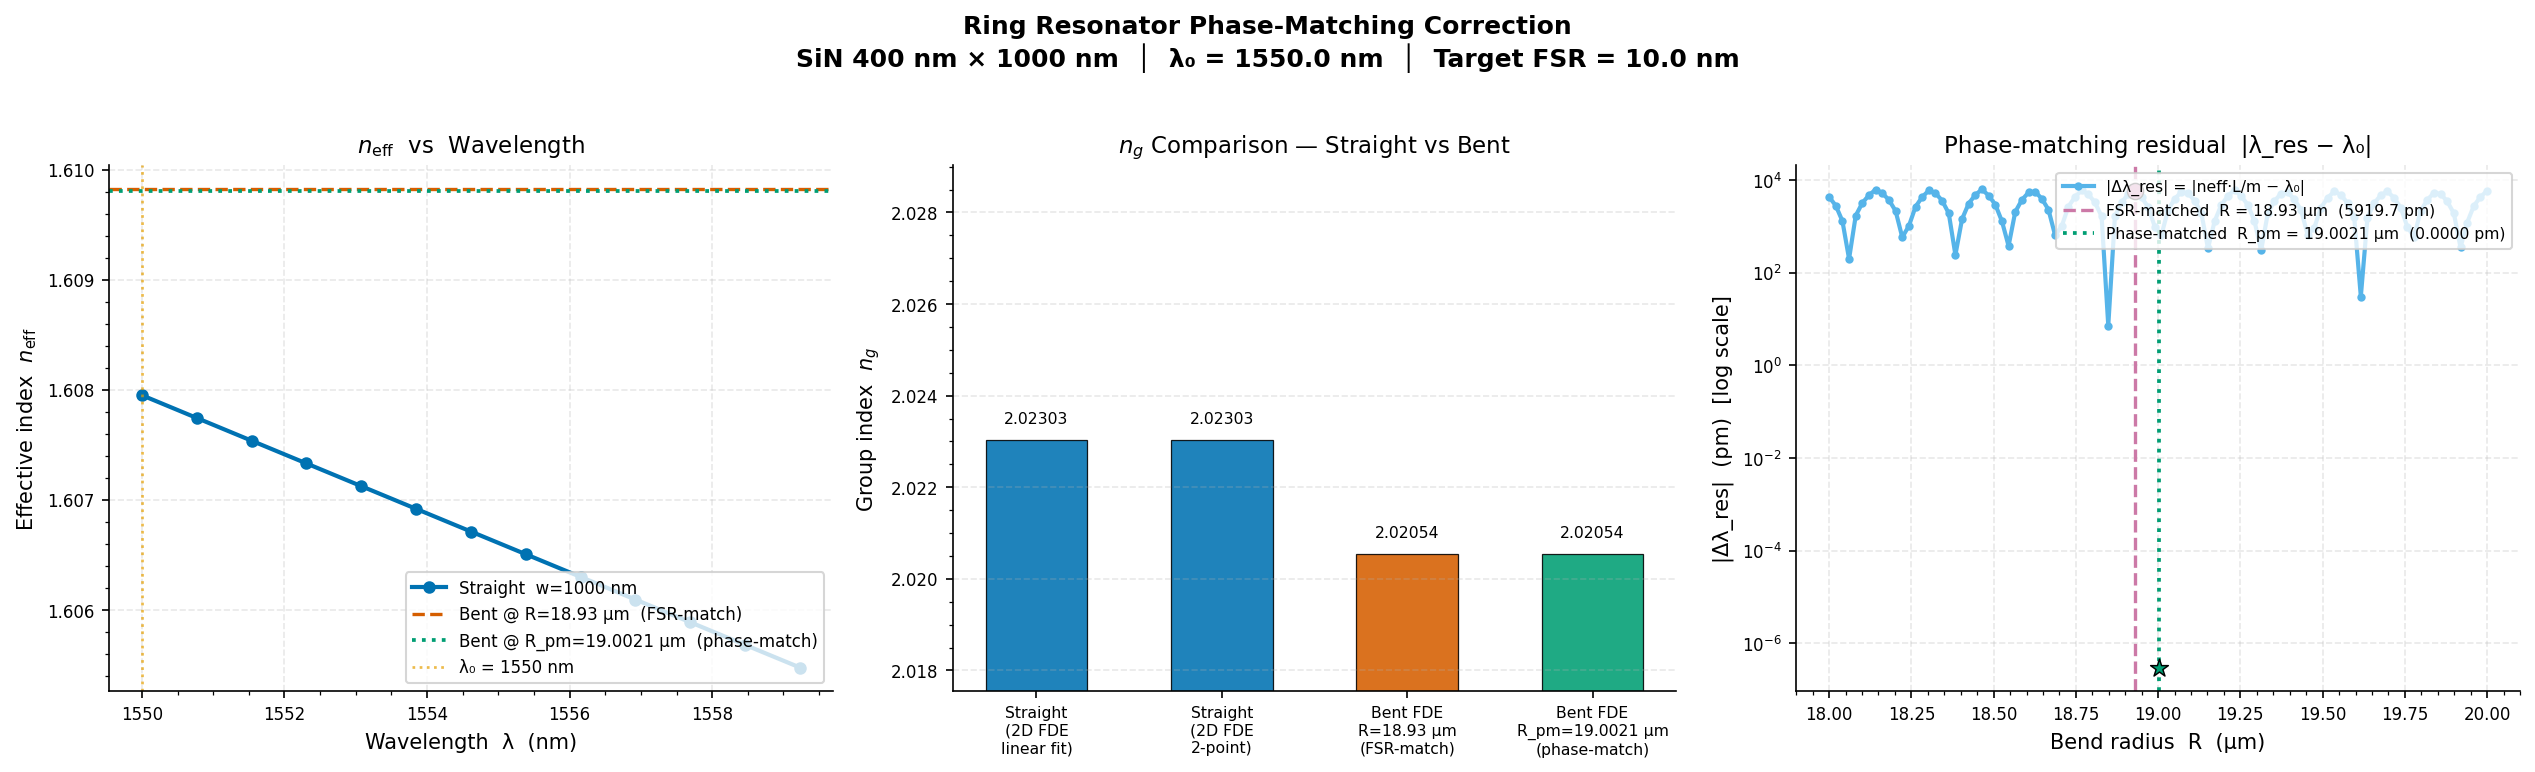

In [6]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — Phase-matching correction + straight-waveguide ng comparison      ║
# ║                                                                              ║
# ║  Requires from earlier cells (already in kernel scope):                      ║
# ║    np, h5py, log, Path, datetime                                             ║
# ║    DATA_DIR, HDF5_PATH, VERSION_NAME                                         ║
# ║    N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING, CORE_THICKNESS_UM           ║
# ║    SWEEP_WIDTHS_UM, SWEEP_WL_NM, SWEEP_WL_UM                                ║
# ║    neff_real, te_frac           (from Cell 3 — straight aqueous sweep)       ║
# ║    RR_WG_WIDTH_NM, RR_LAM0_NM, RR_FSR_NM, _RR_DELTA_LAM_NM                 ║
# ║    rr_best_R_um, rr_best_L_um, rr_best_neff, rr_best_ng, rr_FSR_pred_nm     ║
# ║    _lam0_m, _target_ngL_m, _target_ngL_um                                   ║
# ║    _neff_arr, _ng_arr, _te_arr, _ngL_arr, _radii_um, _radii_m, _computed    ║
# ║                                                                              ║
# ║  What this cell does:                                                        ║
# ║    A) Extracts ng_straight from the existing straight FDE sweep (no new      ║
# ║       Lumerical call) using a central-difference across the 13-point λ sweep ║
# ║       at the chosen waveguide width (1000 nm).                               ║
# ║    B) Computes the resonance order m that minimises |m·λ₀ − neff·2πR| for   ║
# ║       every radius in the sweep array, then selects the global minimum.      ║
# ║    C) For the best radius found in Cell 8 (rr_best_R_um) calculates the      ║
# ║       exact phase-matched radius R_pm such that m·λ₀ = neff_bend·2π·R_pm.   ║
# ║    D) Iterates R_pm to self-consistency (neff changes with R at fixed width) ║
# ║       using the bent neff array from Cell 8 via linear interpolation.        ║
# ║    E) Prints a side-by-side comparison table and saves a 3-panel figure.     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.interpolate import interp1d   # already in scipy which is standard

# ─────────────────────────────────────────────────────────────────────────────
# SECTION A — ng from STRAIGHT waveguide sweep (no new FDE required)
#
#   The straight FDE sweep (Cells 1–3) produced:
#       neff_real[w_idx, wl_idx, mode_idx]   — shape (100, 13, 6)
#       SWEEP_WIDTHS_UM                       — 100 values, 600→1500 nm
#       SWEEP_WL_NM                           — 13 values, 1550.0→1559.23 nm
#
#   Strategy:
#     1. Find the width index for RR_WG_WIDTH_NM (1000 nm).
#     2. Use the full 13-point λ array as a finite-difference stencil and fit
#        a linear polynomial to neff(λ) — this gives dn_eff/dλ robustly.
#     3. Evaluate ng_straight = neff(λ₀) − λ₀ · dneff/dλ  at λ₀ = 1550 nm.
#        (Eq. 10 from Bogaerts et al. 2012)
#     4. Cross-check with the ±Δλ two-point formula for consistency.
# ─────────────────────────────────────────────────────────────────────────────

# ── A1: find width index for the ring waveguide width ────────────────────────
_rr_w_um  = RR_WG_WIDTH_NM * 1e-3              # 1.000 µm
_w_diffs  = np.abs(SWEEP_WIDTHS_UM - _rr_w_um)
_w_idx    = int(np.argmin(_w_diffs))
_w_actual_nm = SWEEP_WIDTHS_UM[_w_idx] * 1e3

log.info(
    f"Straight ng extraction │ target width = {RR_WG_WIDTH_NM:.0f} nm  "
    f"→ closest sweep index = {_w_idx}  "
    f"({_w_actual_nm:.2f} nm)"
)

# ── A2: extract neff(λ) for fundamental TE mode at chosen width ──────────────
# Mode 0 is always the fundamental (highest neff).  The te_frac check is a
# safety guard — if te_frac < 0.5 at this width the mode is TM.
_neff_vs_wl = neff_real[_w_idx, :, 0].copy()   # shape (13,)
_te_vs_wl   = te_frac  [_w_idx, :, 0].copy()

_te_mean = float(np.nanmean(_te_vs_wl))
if _te_mean < 0.5:
    log.warning(
        f"Mode 0 at w={_w_actual_nm:.0f} nm appears TM (mean TE frac={_te_mean:.3f}). "
        "Switching to mode index 1."
    )
    _neff_vs_wl = neff_real[_w_idx, :, 1].copy()
    _te_vs_wl   = te_frac  [_w_idx, :, 1].copy()

# ── A3: linear fit to neff(λ) → dn_eff/dλ ────────────────────────────────────
# Using wavelength in metres for dimensional consistency with Bogaerts Eq. 10.
_wl_m_arr = SWEEP_WL_NM * 1e-9              # shape (13,)   [m]
_lam0_idx = int(np.argmin(np.abs(SWEEP_WL_NM - RR_LAM0_NM)))   # index of λ₀

# Only use non-NaN points
_valid_wl  = ~np.isnan(_neff_vs_wl)
_poly_coeffs = np.polyfit(
    _wl_m_arr[_valid_wl],
    _neff_vs_wl[_valid_wl],
    deg=1,                  # linear: neff ≈ c0 + c1·λ
)
_dneff_dlam_straight = _poly_coeffs[0]          # c1  [1/m]

# neff at λ₀ from the fit (more stable than raw array value)
_neff_straight_lam0  = float(np.polyval(_poly_coeffs, _lam0_m))

# ng_straight  =  neff(λ₀) − λ₀ · dneff/dλ            (Bogaerts Eq. 10)
ng_straight = _neff_straight_lam0 - _lam0_m * _dneff_dlam_straight

# ── A4: two-point cross-check using first and last wavelength ────────────────
_neff_lo_str = _neff_vs_wl[0]    # λ = 1550.000 nm
_neff_hi_str = _neff_vs_wl[-1]   # λ = 1559.231 nm
_dlam_str_m  = (_wl_m_arr[-1] - _wl_m_arr[0])
_dneff_2pt   = (_neff_hi_str - _neff_lo_str) / _dlam_str_m
_ng_straight_2pt = _neff_vs_wl[_lam0_idx] - _lam0_m * _dneff_2pt

log.info(
    f"ng_straight (linear fit)  = {ng_straight:.6f}  |  "
    f"ng_straight (2-pt check)  = {_ng_straight_2pt:.6f}  |  "
    f"neff @ λ₀ = {_neff_straight_lam0:.6f}"
)


# ─────────────────────────────────────────────────────────────────────────────
# SECTION B — resonance order m and phase-matching residual for every radius
#
#   Resonance condition (Bogaerts Eq. 3):
#       λ_res = neff · L / m     →     m = neff · L / λ₀   (continuous)
#   Phase-matched integer order:
#       m_int = round(neff · 2π·R / λ₀)
#   Residual:
#       δλ_res = (neff · 2π·R / m_int) − λ₀        [nm]
#
#   NOTE: we use neff from the BENT FDE (Cell 8), not the straight value,
#   because bend-induced mode shift is already captured there.
# ─────────────────────────────────────────────────────────────────────────────

# Filter to radii that have valid bent neff (no FDE failure)
_valid_r   = ~np.isnan(_neff_arr)
_R_v_m     = _radii_um[_valid_r] * 1e-6        # [m]
_neff_v_b  = _neff_arr[_valid_r]               # bent neff
_ng_v_b    = _ng_arr  [_valid_r]               # bent ng
_te_v_b    = _te_arr  [_valid_r]

# Continuous resonance order
_L_v_m     = 2.0 * np.pi * _R_v_m
_m_cont    = _neff_v_b * _L_v_m / _lam0_m

# Integer order (nearest)
_m_int     = np.round(_m_cont).astype(int)

# Exact resonance wavelength for each m_int
_lam_res_v = (_neff_v_b * _L_v_m) / _m_int     # [m]
_delta_lam = (_lam_res_v - _lam0_m) * 1e9       # [nm]  shift from λ₀

# Phase condition residual: how much neff·L deviates from m·λ₀
_phase_resid_nm = np.abs(_delta_lam)             # [nm]


# ─────────────────────────────────────────────────────────────────────────────
# SECTION C — phase-matched radius for the best-sweep radius
#
#   Given the integer order m derived above, find R_pm such that:
#       m · λ₀ = neff_bent(R_pm) · 2π · R_pm
#
#   Step C1: first-order correction (assume neff ≈ constant over small ΔR):
#       R_pm  =  m · λ₀ / (2π · neff_best)
#
#   Step C2: iterative refinement using the bent neff(R) interpolant from
#       Cell 8 until ΔR < 0.1 nm  (typically 2–3 iterations).
# ─────────────────────────────────────────────────────────────────────────────

# Index of best radius in the filtered arrays
_R_v_um_f  = _radii_um[_valid_r]
_bi_f      = int(np.argmin(np.abs(_R_v_um_f - rr_best_R_um)))

m_best     = int(_m_int[_bi_f])
neff_best  = float(_neff_v_b[_bi_f])
ng_best    = float(_ng_v_b[_bi_f])

log.info(f"Best radius  R = {rr_best_R_um:.4f} µm  →  m = {m_best}")

# ── C1: first-order analytical correction ─────────────────────────────────────
R_pm_0_m  = m_best * _lam0_m / (2.0 * np.pi * neff_best)
R_pm_0_um = R_pm_0_m * 1e6

# ── C2: iterative self-consistent refinement ──────────────────────────────────
# Build interpolant neff_bent(R) from the sweep data.
# Only possible if we have ≥ 3 valid radii (always true for 100-point sweep).
_interp_neff = interp1d(
    _R_v_m, _neff_v_b,
    kind="linear",
    bounds_error=False,
    fill_value=(_neff_v_b[0], _neff_v_b[-1]),   # extrapolate flat
)

_tol_m    = 1e-13          # convergence: < 0.1 nm
_R_pm_m   = R_pm_0_m       # initial guess
_max_iter  = 20
_n_iter    = 0
_correction_history = [(_R_pm_m, neff_best)]

for _iter in range(_max_iter):
    _neff_at_R   = float(_interp_neff(_R_pm_m))
    _R_pm_new    = m_best * _lam0_m / (2.0 * np.pi * _neff_at_R)
    _correction_history.append((_R_pm_new, _neff_at_R))
    _delta_R     = abs(_R_pm_new - _R_pm_m)
    _R_pm_m      = _R_pm_new
    _n_iter     += 1
    if _delta_R < _tol_m:
        break

R_pm_um    = _R_pm_m * 1e6
neff_pm    = float(_interp_neff(_R_pm_m))
L_pm_um    = 2.0 * np.pi * R_pm_um
FSR_pm_nm  = (_lam0_m**2 / (ng_best * L_pm_um * 1e-6)) * 1e9

# Verify: resonance wavelength at corrected radius
lam_res_pm_nm = (neff_pm * L_pm_um * 1e-6 / m_best) * 1e9
phase_resid_pm_pm = abs(lam_res_pm_nm - RR_LAM0_NM) * 1e3   # [pm]

log.info(
    f"Phase-matched radius  R_pm = {R_pm_um:.4f} µm  "
    f"(converged in {_n_iter} iterations,  "
    f"λ_res = {lam_res_pm_nm:.6f} nm,  "
    f"residual = {phase_resid_pm_pm:.4f} pm)"
)


# ─────────────────────────────────────────────────────────────────────────────
# SECTION D — also find pm-corrected radius for every m in the sweep
#   This gives a complete picture of which radii satisfy phase matching.
# ─────────────────────────────────────────────────────────────────────────────

_R_pm_all_um  = m_best * _lam0_m / (2.0 * np.pi * _neff_v_b) * 1e6
_L_pm_all_um  = 2.0 * np.pi * _R_pm_all_um
_FSR_pm_all   = (_lam0_m**2 / (_ng_v_b * _L_pm_all_um * 1e-6)) * 1e9
_lam_res_all  = (_neff_v_b * 2.0 * np.pi * _R_v_um_f * 1e-6 / _m_int) * 1e9
_resid_all_pm = np.abs(_lam_res_all - RR_LAM0_NM) * 1e3   # [pm]


# ─────────────────────────────────────────────────────────────────────────────
# SECTION E — COMPARISON TABLE
#
#   Row 1: Straight waveguide ng (from 2D FDE, no bending)
#   Row 2: Bent waveguide at FSR-matched radius (from Cell 8)
#   Row 3: Phase-matched corrected radius (this cell)
# ─────────────────────────────────────────────────────────────────────────────

_SEP  = "─" * 82
_SEP2 = "═" * 82

print()
print(_SEP2)
print("  RING RESONATOR DESIGN SUMMARY  —  Phase Matching Correction")
print(_SEP2)
print(f"  Platform  : SiN  {CORE_THICKNESS_UM*1e3:.0f} nm × {RR_WG_WIDTH_NM:.0f} nm  │  "
      f"λ₀ = {RR_LAM0_NM:.1f} nm  │  Target FSR = {RR_FSR_NM:.1f} nm")
print(_SEP)

# ── ng comparison block ───────────────────────────────────────────────────────
print()
print("  GROUP INDEX COMPARISON")
print(f"  {'Source':<42}  {'neff':>10}  {'ng':>10}  {'dneff/dλ [1/µm]':>18}")
print("  " + "─" * 78)
print(
    f"  {'Straight FDE (aqueous, linear fit)':<42}  "
    f"{_neff_straight_lam0:>10.6f}  "
    f"{ng_straight:>10.6f}  "
    f"{_dneff_dlam_straight*1e-6:>18.6f}"
)
print(
    f"  {'Straight FDE (2-point cross-check)':<42}  "
    f"{float(_neff_vs_wl[_lam0_idx]):>10.6f}  "
    f"{_ng_straight_2pt:>10.6f}  "
    f"{'—':>18}"
)
print(
    f"  {'Bent FDE @ R = ' + f'{rr_best_R_um:.4f} µm (FSR-matched)':<42}  "
    f"{rr_best_neff:>10.6f}  "
    f"{rr_best_ng:>10.6f}  "
    f"{'—':>18}"
)
print(
    f"  {'Bent FDE @ R_pm = ' + f'{R_pm_um:.4f} µm (phase-matched)':<42}  "
    f"{neff_pm:>10.6f}  "
    f"{ng_best:>10.6f}  "
    f"{'—':>18}"
)
_ng_shift_pct = (rr_best_ng - ng_straight) / ng_straight * 100.0
print()
print(f"  Δng (bend vs straight) = {rr_best_ng - ng_straight:+.6f}  "
      f"({_ng_shift_pct:+.3f} %)   ← chromatic confinement shift from bending")

# ── phase matching block ──────────────────────────────────────────────────────
print()
print(_SEP)
print()
print("  PHASE MATCHING CORRECTION")
print(f"  {'Parameter':<42}  {'FSR-matched R':>15}  {'Phase-matched R_pm':>20}")
print("  " + "─" * 78)

def _row(label, v1, v2, fmt=".4f"):
    print(f"  {label:<42}  {v1:>15{fmt}}  {v2:>20{fmt}}")

_row("Radius  R  (µm)",               rr_best_R_um,    R_pm_um)
_row("Ring length  L = 2πR  (µm)",    rr_best_L_um,    L_pm_um)
_row("Effective index  neff",          rr_best_neff,    neff_pm,    fmt=".6f")
_row("Group index  ng",                rr_best_ng,      ng_best,    fmt=".6f")
_row("Resonance order  m",             float(m_best),   float(m_best), fmt=".0f")
_row("λ_res = neff·L/m  (nm)",
     (rr_best_neff * rr_best_L_um * 1e-6 / m_best) * 1e9,
     lam_res_pm_nm)
_row("Δλ from target λ₀  (pm)",
     abs(rr_best_neff * rr_best_L_um * 1e-6 / m_best - _lam0_m) * 1e12,
     phase_resid_pm_pm)
_row("ng·L  (µm)",                     rr_best_ngL_um,  ng_best * L_pm_um)
_row("FSR = λ₀² / (ng·L)  (nm)",       rr_FSR_pred_nm,  FSR_pm_nm)
_row("FSR error vs target  (pm)",
     abs(rr_FSR_pred_nm - RR_FSR_NM) * 1e3,
     abs(FSR_pm_nm      - RR_FSR_NM) * 1e3)

print()
print(_SEP)
print()
print(f"  Phase-matching correction  ΔR = R_pm − R_best = "
      f"{(R_pm_um - rr_best_R_um) * 1e3:+.2f} nm  "
      f"({(R_pm_um - rr_best_R_um) / rr_best_R_um * 100:+.4f} %)")
print(f"  Convergence               : {_n_iter} iterations  │  "
      f"λ_res residual = {phase_resid_pm_pm:.4f} pm")
print(f"  Resonance order m = {m_best}  →  λ₀ = {m_best} × {RR_LAM0_NM / m_best * 1e3:.4f} pm")
print()
print(_SEP2)

# ── iteration convergence table ───────────────────────────────────────────────
print()
print("  ITERATIVE CONVERGENCE  (R_pm self-consistent refinement)")
print(f"  {'Iter':>5}  {'R  (µm)':>14}  {'neff':>12}  {'ΔR  (nm)':>12}")
print("  " + "─" * 50)
for _k, (_R_it, _n_it) in enumerate(_correction_history):
    _dR = (_R_it - _correction_history[0][0]) * 1e9 if _k > 0 else 0.0
    print(f"  {_k:>5}  {_R_it*1e6:>14.6f}  {_n_it:>12.8f}  {_dR:>+12.4f}")
print()

# Export to downstream cells
print("  Variables exported:")
print(f"    m_best          = {m_best}")
print(f"    R_pm_um         = {R_pm_um:.6f}  # µm  (phase-matched)")
print(f"    neff_pm         = {neff_pm:.6f}")
print(f"    L_pm_um         = {L_pm_um:.6f}  # µm")
print(f"    FSR_pm_nm       = {FSR_pm_nm:.6f}  # nm")
print(f"    ng_straight     = {ng_straight:.6f}  (from straight 2D FDE)")
print(f"    lam_res_pm_nm   = {lam_res_pm_nm:.6f}  # nm  (resonance @ R_pm)")
print()


# ─────────────────────────────────────────────────────────────────────────────
# SECTION F — FIGURES
# ─────────────────────────────────────────────────────────────────────────────

plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "legend.fontsize":   8,
    "lines.linewidth":   2.0,
    "lines.markersize":  5,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.28,
    "grid.linestyle":    "--",
})

_C_STR  = "#0072B2"   # straight ng — blue
_C_BEND = "#D55E00"   # bent neff/ng — vermilion
_C_PM   = "#009E73"   # phase-matched — green
_C_BEST = "#CC79A7"   # FSR-matched best — pink
_C_TGT  = "#E69F00"   # target — amber
_C_RES  = "#56B4E9"   # residual — sky

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    f"Ring Resonator Phase-Matching Correction\n"
    f"SiN {CORE_THICKNESS_UM*1e3:.0f} nm × {RR_WG_WIDTH_NM:.0f} nm  │  "
    f"λ₀ = {RR_LAM0_NM:.1f} nm  │  Target FSR = {RR_FSR_NM:.1f} nm",
    fontsize=12, fontweight="bold", y=1.02,
)

# ── Panel 1: neff(λ) straight vs bent ─────────────────────────────────────────
ax0 = axes[0]
ax0.plot(
    SWEEP_WL_NM, _neff_vs_wl,
    "o-", color=_C_STR, label=f"Straight  w={_w_actual_nm:.0f} nm",
)
# bent neff is a single value per radius; mark the best-radius value
ax0.axhline(
    rr_best_neff, color=_C_BEND, ls="--", lw=1.6,
    label=f"Bent @ R={rr_best_R_um:.2f} µm  (FSR-match)",
)
ax0.axhline(
    neff_pm, color=_C_PM, ls=":", lw=1.8,
    label=f"Bent @ R_pm={R_pm_um:.4f} µm  (phase-match)",
)
ax0.axvline(
    RR_LAM0_NM, color=_C_TGT, ls=":", lw=1.3, alpha=0.7,
    label=f"λ₀ = {RR_LAM0_NM:.0f} nm",
)
ax0.set_xlabel("Wavelength  λ  (nm)")
ax0.set_ylabel(r"Effective index  $n_\mathrm{eff}$")
ax0.set_title(r"$n_\mathrm{eff}$  vs  Wavelength")
ax0.legend(loc="lower right")
ax0.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax0.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# ── Panel 2: ng comparison bar chart ─────────────────────────────────────────
ax1 = axes[1]
_labels = [
    f"Straight\n(2D FDE\nlinear fit)",
    f"Straight\n(2D FDE\n2-point)",
    f"Bent FDE\nR={rr_best_R_um:.2f} µm\n(FSR-match)",
    f"Bent FDE\nR_pm={R_pm_um:.4f} µm\n(phase-match)",
]
_ng_vals = [ng_straight, _ng_straight_2pt, rr_best_ng, ng_best]
_colors  = [_C_STR, _C_STR, _C_BEND, _C_PM]
_bars    = ax1.bar(
    range(4), _ng_vals,
    color=_colors, width=0.55, edgecolor="k", linewidth=0.6, alpha=0.88,
)
# value annotations on bars
for _b, _v in zip(_bars, _ng_vals):
    ax1.text(
        _b.get_x() + _b.get_width() / 2,
        _v + 0.0003,
        f"{_v:.5f}",
        ha="center", va="bottom", fontsize=7.5,
    )
ax1.set_xticks(range(4))
ax1.set_xticklabels(_labels, fontsize=7.5)
ax1.set_ylabel(r"Group index  $n_g$")
ax1.set_title(r"$n_g$ Comparison — Straight vs Bent")
# zoom y-axis to show differences
_ng_min = min(_ng_vals) - 0.003
_ng_max = max(_ng_vals) + 0.006
ax1.set_ylim(_ng_min, _ng_max)
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.grid(True, axis="y", alpha=0.28, linestyle="--")
ax1.grid(False, axis="x")

# ── Panel 3: phase residual |Δλ_res| across the radius sweep ─────────────────
ax2 = axes[2]
ax2.semilogy(
    _R_v_um_f, _resid_all_pm,
    "o-", color=_C_RES, markersize=3,
    label="|Δλ_res| = |neff·L/m − λ₀|",
)
ax2.axvline(
    rr_best_R_um, color=_C_BEST, ls="--", lw=1.6,
    label=f"FSR-matched  R = {rr_best_R_um:.2f} µm  "
          f"({_resid_all_pm[_bi_f]:.1f} pm)",
)
ax2.axvline(
    R_pm_um, color=_C_PM, ls=":", lw=1.8,
    label=f"Phase-matched  R_pm = {R_pm_um:.4f} µm  "
          f"({phase_resid_pm_pm:.4f} pm)",
)
ax2.scatter(
    [rr_best_R_um], [_resid_all_pm[_bi_f]],
    s=60, zorder=5, color=_C_BEST, edgecolors="k", linewidths=0.7,
)
ax2.scatter(
    [R_pm_um], [phase_resid_pm_pm],
    s=80, marker="*", zorder=6, color=_C_PM, edgecolors="k", linewidths=0.7,
)
ax2.set_xlabel("Bend radius  R  (µm)")
ax2.set_ylabel("|Δλ_res|  (pm)  [log scale]")
ax2.set_title("Phase-matching residual  |λ_res − λ₀|")
ax2.legend(loc="upper right", fontsize=7.5)
ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()

_fig_stem = DATA_DIR / f"{VERSION_NAME}_phase_match_correction"
for _ext in (".png", ".pdf"):
    plt.savefig(str(_fig_stem) + _ext, dpi=150, bbox_inches="tight")
    print(f"  Saved → {str(_fig_stem) + _ext}")

plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Final variable exports for the next cell
# ─────────────────────────────────────────────────────────────────────────────
# m_best          — integer resonance order
# R_pm_um         — phase-matched radius [µm]
# neff_pm         — neff at phase-matched radius
# L_pm_um         — ring circumference at R_pm [µm]
# FSR_pm_nm       — FSR at phase-matched radius [nm]
# ng_straight     — group index from straight 2D FDE (no bending)
# lam_res_pm_nm   — exact resonance wavelength at R_pm [nm]

18:59:01 │ INFO │ Straight ng extraction  w=1000 nm → index 44 (1000.00 nm)
18:59:01 │ INFO │ ng_straight_sio2 range: 1.998279 – 1.998279
18:59:01 │ INFO │ Ring 00 │ λ=1550.000000 nm │ R=[20.000, 19.000] µm │ target ng·L=240.2500 µm │ cached 100/100
18:59:01 │ INFO │   Ring 00 │ RESULT │ R_pm=19.181771 µm  neff=1.633303  ng=1.991101  L=120.522620 µm  FSR=10.011555 nm  |Δλ|=0.00000 pm
18:59:01 │ INFO │ Ring 01 │ λ=1550.769231 nm │ R=[20.000, 19.000] µm │ target ng·L=240.4885 µm │ cached 100/100
18:59:01 │ INFO │   Ring 01 │ RESULT │ R_pm=19.193429 µm  neff=1.633121  ng=1.990956  L=120.595873 µm  FSR=10.016139 nm  |Δλ|=0.00000 pm
18:59:01 │ INFO │ Ring 02 │ λ=1551.538462 nm │ R=[20.000, 19.000] µm │ target ng·L=240.7272 µm │ cached 100/100
18:59:01 │ INFO │   Ring 02 │ RESULT │ R_pm=19.205089 µm  neff=1.632939  ng=1.990808  L=120.669135 µm  FSR=10.020732 nm  |Δλ|=0.00000 pm
18:59:01 │ INFO │ Ring 03 │ λ=1552.307692 nm │ R=[20.000, 19.000] µm │ target ng·L=240.9659 µm │ cached 100/100
18:

  SPECTROMETER RING ARRAY — SiO₂/SiN/SiO₂  (symmetric cladding)
  Rings          : 13   (n = 0 … 12)
  λ₀  (ring 0)   : 1550.000000 nm
  λ₁₂ (ring 12)  : 1559.230769 nm
  Step           : 0.769231 nm  (= 10/13 nm)
  Waveguide      : 1000 nm × 400 nm  (w × h)
  n_core         : 1.99    n_clad = 1.4469 (SiO₂)
  Target FSR     : 10.0 nm
  Radii/ring     : 100
  ng stencil     : ±5.0 nm  (3 FDE/radius → 300 solves/ring if uncached)
  HDF5 file      : D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1.h5


  Estimated radius range:  0.0000 – 0.0000 µm  (straight ng estimate)


  Ring 00 │ λ₀ = 1550.0000 nm  │ target ng·L = 240.2500 µm
      R (µm)        neff          ng      TE     ng·L (µm)      Δ/tgt  src
  ────────────────────────────────────────────────────────────────────────
     20.0000    1.633055    1.995042  0.9958      250.7043    +4.351%  cache
     19.9899    1.633058    1.995024  0.9958    

C:\Users\JUANES_\AppData\Local\Temp\ipykernel_14276\1919423492.py:903: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1_spectrometer_rings.png
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1_spectrometer_rings.pdf


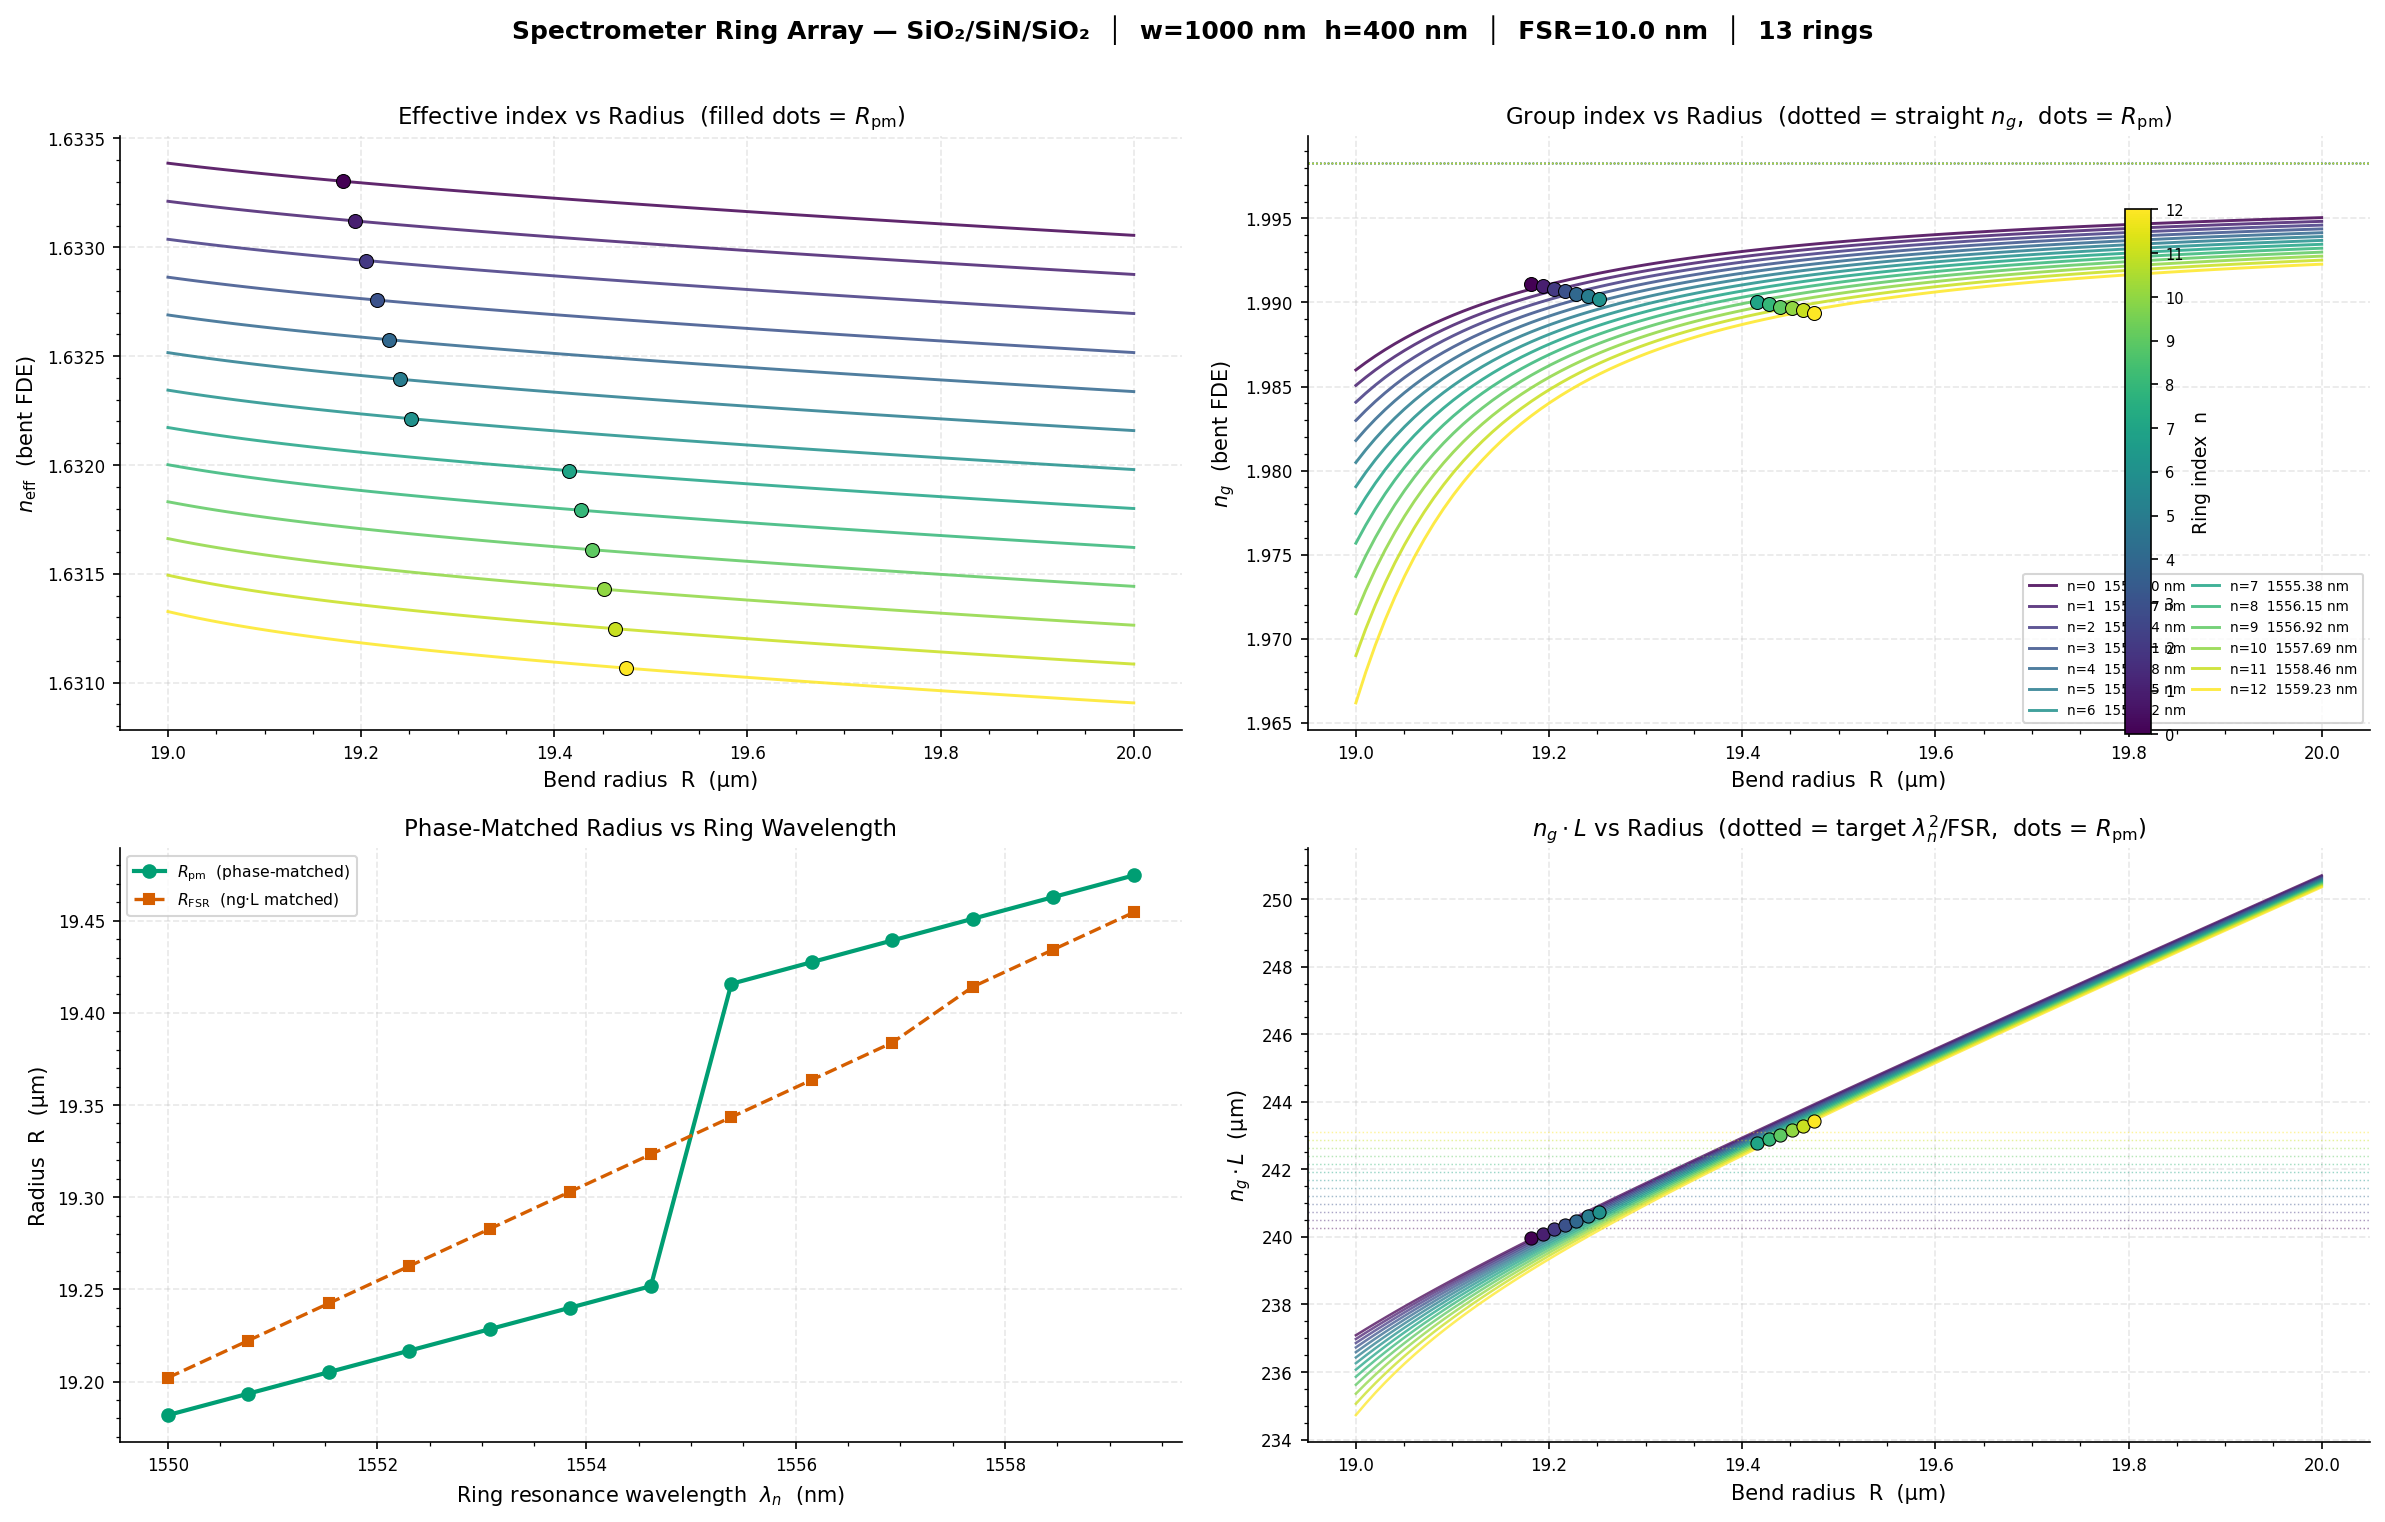

In [7]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — Spectrometer Ring Array : 13 rings, radius sweep + phase match  ║
# ║                                                                              ║
# ║  ARCHITECTURE: this cell is a direct extension of Cell 4 (sensor ring).    ║
# ║  The FDE engine, HDF5 structure, caching logic and phase-matching maths     ║
# ║  are IDENTICAL to Cell 4. The only differences are:                         ║
# ║    • SiO₂ symmetric cladding instead of aqueous upper cladding             ║
# ║    • 13 resonance wavelengths instead of 1                                  ║
# ║    • Results stored under  spectrometer_rings/ring_NN/  in HDF5_PATH_SIO2  ║
# ║                                                                              ║
# ║  Requires from earlier cells (already in kernel scope):                     ║
# ║    lumapi, np, h5py, log, time, Path, datetime                              ║
# ║    DATA_DIR, HDF5_PATH_SIO2, VERSION_NAME_SIO2                              ║
# ║    N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING_SIO2                        ║
# ║    CORE_THICKNESS_UM, SIM_Y_SPAN_UM, SIM_Z_BELOW_UM, SIM_Z_ABOVE_UM       ║
# ║    MESH_CELLS_Y, MESH_CELLS_Z, N_MODES_REQUEST                             ║
# ║    RR_WG_WIDTH_NM  (1000 nm)                                                ║
# ║    RR_FSR_NM       (10.0 nm)                                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# ═════════════════════════════════════════════════════════════════════════════
# SECTION 0 — RING ARRAY DEFINITION  (edit only this block)
# ═════════════════════════════════════════════════════════════════════════════

N_SPEC_RINGS        = 13
SPEC_LAM0_NM        = 1550.0
SPEC_DELTA_LAM_NM   = 10.0 / 13.0          # ≈ 0.769231 nm  (exact rational step)
SPEC_LAM_NM         = SPEC_LAM0_NM + np.arange(N_SPEC_RINGS) * SPEC_DELTA_LAM_NM

SPEC_WG_WIDTH_NM    = RR_WG_WIDTH_NM        # 1000 nm  — inherited
SPEC_FSR_NM         = RR_FSR_NM             # 10.0 nm  — inherited
SPEC_N_UPPER        = N_UPPER_CLADDING_SIO2 # 1.4469   — SiO₂ symmetric

# Radius sweep — 100 points per ring (same as Cell 4 sensor ring)
SPEC_N_RADII        = 100
SPEC_R_HALF_SPAN_UM = 19    # [µm]  search half-width around analytical estimate
SPEC_R_MIN_FLOOR_UM = 20    # [µm]  absolute lower bound (bend loss guard)

# ng central-difference stencil — same ±5 nm as Cell 4
SPEC_DELTA_LAM_NG_NM = 5.0   # [nm]

# Phase-matching iteration tolerance
_PM_TOL_M    = 1e-13    # |ΔR| < 0.1 pm
_PM_MAX_ITER = 20

# ─────────────────────────────────────────────────────────────────────────────
# Fixed geometry (ALL identical to Cell 4 sensor ring — do not modify)
# ─────────────────────────────────────────────────────────────────────────────
_sp_core_t_um    = CORE_THICKNESS_UM
_sp_half_t_um    = _sp_core_t_um / 2.0
_sp_z_below_um   = SIM_Z_BELOW_UM
_sp_z_above_um   = SIM_Z_ABOVE_UM
_sp_z_span_um    = _sp_z_below_um + _sp_core_t_um + _sp_z_above_um
_sp_y_span_um    = SIM_Y_SPAN_UM
_sp_sio2_z_ctr   = -(_sp_half_t_um + _sp_z_below_um / 2.0)  # below core centre
_sp_sio2_z_span  = _sp_z_below_um
_sp_z_ctr        = (_sp_z_above_um - _sp_z_below_um) / 2.0
_sp_wg_w_m       = SPEC_WG_WIDTH_NM * 1e-9

print("=" * 70)
print("  SPECTROMETER RING ARRAY — SiO₂/SiN/SiO₂  (symmetric cladding)")
print("=" * 70)
print(f"  Rings          : {N_SPEC_RINGS}   (n = 0 … {N_SPEC_RINGS-1})")
print(f"  λ₀  (ring 0)   : {SPEC_LAM_NM[0]:.6f} nm")
print(f"  λ₁₂ (ring 12)  : {SPEC_LAM_NM[-1]:.6f} nm")
print(f"  Step           : {SPEC_DELTA_LAM_NM:.6f} nm  (= 10/13 nm)")
print(f"  Waveguide      : {SPEC_WG_WIDTH_NM:.0f} nm × {_sp_core_t_um*1e3:.0f} nm  (w × h)")
print(f"  n_core         : {N_SIN_FIXED}    n_clad = {SPEC_N_UPPER} (SiO₂)")
print(f"  Target FSR     : {SPEC_FSR_NM:.1f} nm")
print(f"  Radii/ring     : {SPEC_N_RADII}")
print(f"  ng stencil     : ±{SPEC_DELTA_LAM_NG_NM:.1f} nm  (3 FDE/radius → "
      f"{SPEC_N_RADII*3} solves/ring if uncached)")
print(f"  HDF5 file      : {HDF5_PATH_SIO2}")
print("=" * 70)
print()


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 1 — FDE ENGINE
# Exact copy of _rr_build_fde / _rr_solve_neff / _rr_neff_ng from Cell 4.
# Only change: background index = SPEC_N_UPPER (SiO₂) not N_UPPER_CLADDING.
# ═════════════════════════════════════════════════════════════════════════════

def _sp_build_fde(mode, radius_m: float, wavelength_m: float) -> None:
    """
    Build bent-waveguide FDE cross-section for one (R, λ) point.
    Geometry is IDENTICAL to Cell 4 _rr_build_fde except:
      - upper cladding / background index = SPEC_N_UPPER  (SiO₂, 1.4469)
      - bend orientation = 0  (horizontal ring in XY plane — corrected)
    Stack (bottom to top along Z):
      SiO₂ substrate  →  SiN core 400 nm  →  SiO₂ upper cladding
    Cross-section:  Y = width axis (1000 nm),  Z = height axis (400 nm)
    """
    m = mode
    m.switchtolayout()
    m.selectall()
    m.delete()

    # ── FDE solver ────────────────────────────────────────────────────────────
    m.addfde()
    m.set("solver type",           "2D X normal")   # propagation along +X
    m.set("x",                     0.0)
    m.set("y",                     0.0)
    m.set("z",                     _sp_z_ctr      * 1e-6)
    m.set("y span",                _sp_y_span_um  * 1e-6)
    m.set("z span",                _sp_z_span_um  * 1e-6)
    m.set("wavelength",            wavelength_m)
    m.set("number of trial modes", N_MODES_REQUEST)
    m.set("mesh cells y",          MESH_CELLS_Y)
    m.set("mesh cells z",          MESH_CELLS_Z)
    m.set("bent waveguide",        1)
    m.set("bend radius",           radius_m)
    m.set("bend orientation",      0)      # 0 = curvature centre along +Y → ring in XY plane

    # ── Background (SiO₂ upper cladding — fills entire domain) ───────────────
    m.addrect()
    m.set("name",     "SP_bg")
    m.set("x",        0.0);  m.set("x span", 1.0e-6)
    m.set("y",        0.0);  m.set("y span", _sp_y_span_um  * 1e-6)
    m.set("z",        _sp_z_ctr      * 1e-6)
    m.set("z span",   _sp_z_span_um  * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    SPEC_N_UPPER)        # SiO₂ = 1.4469

    # ── Lower SiO₂ substrate slab (overrides background in -Z region) ────────
    m.addrect()
    m.set("name",     "SP_lower_clad")
    m.set("x",        0.0);  m.set("x span", 1.0e-6)
    m.set("y",        0.0);  m.set("y span", _sp_y_span_um  * 1e-6)
    m.set("z",        _sp_sio2_z_ctr * 1e-6)
    m.set("z span",   _sp_sio2_z_span * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIO2_FIXED)        # SiO₂ = 1.4469 (symmetric)

    # ── SiN core (highest priority, centred at z = 0) ─────────────────────────
    m.addrect()
    m.set("name",     "SP_core")
    m.set("x",        0.0);  m.set("x span", 1.0e-6)
    m.set("y",        0.0);  m.set("y span", _sp_wg_w_m)          # 1000 nm
    m.set("z",        0.0);  m.set("z span", _sp_core_t_um * 1e-6) # 400 nm
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIN_FIXED)         # SiN = 1.99


def _sp_solve_neff(mode, radius_m: float, wavelength_m: float):
    """
    One complete FDE solve at (radius_m, wavelength_m).
    Returns (Re(neff), TE_polarisation_fraction) for mode 1.
    Identical to Cell 4 _rr_solve_neff.
    """
    _sp_build_fde(mode, radius_m, wavelength_m)
    mode.run()
    mode.findmodes()
    raw_neff = mode.getdata("FDE::data::mode1", "neff")
    raw_te   = mode.getdata("FDE::data::mode1", "TE polarization fraction")
    neff_c   = complex(np.asarray(raw_neff).flat[0])
    te_v     = float(np.asarray(raw_te).flat[0])
    return neff_c.real, te_v


def _sp_neff_ng(mode, radius_m: float, lam0_m: float, dlam_m: float):
    """
    Three-point central-difference group index at lam0 for a given radius.
    Identical to Cell 4 _rr_neff_ng, but lam0 and dlam are explicit arguments
    so the function works for any of the 13 ring wavelengths.

    Returns (neff_at_lam0, ng, te_frac, neff_lo, neff_hi).

    Formula:  ng = neff(λ₀) − λ₀ · [neff(λ₀+Δλ) − neff(λ₀−Δλ)] / (2·Δλ)
    """
    lam_lo_m = lam0_m - dlam_m
    lam_hi_m = lam0_m + dlam_m

    neff_lo, _    = _sp_solve_neff(mode, radius_m, lam_lo_m)
    neff_0,  te_v = _sp_solve_neff(mode, radius_m, lam0_m)
    neff_hi, _    = _sp_solve_neff(mode, radius_m, lam_hi_m)

    dneff_dlam    = (neff_hi - neff_lo) / (2.0 * dlam_m)
    ng            = neff_0 - lam0_m * dneff_dlam

    return neff_0, ng, te_v, neff_lo, neff_hi


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 2 — HDF5 HELPERS  (one group per ring, mirroring Cell 4 exactly)
#
#  Path inside HDF5_PATH_SIO2:
#    spectrometer_rings/ring_NN/<group_key>/
#      metadata/
#        attrs:  ring_idx, fsr_nm, lam0_nm, wg_width_nm, wg_height_nm,
#                r_min_um, r_max_um, n_radii, delta_lam_nm,
#                n_SiN, n_SiO2, n_upper_clad, bend_orientation,
#                timestamp_start, timestamp_end, runs_completed
#        datasets: radii_um [N], lam_stencil_nm [3]
#      results/
#        neff    [N]  float64   neff at λ₀
#        ng      [N]  float64   group index (central difference)
#        te_frac [N]  float64   TE fraction at λ₀
#        ngL_um  [N]  float64   ng × 2πR  [µm]
#        neff_lo [N]  float64   neff at λ₀ − Δλ
#        neff_hi [N]  float64   neff at λ₀ + Δλ
#      flags/
#        computed [N]  bool
# ═════════════════════════════════════════════════════════════════════════════

def _sp_make_group_path(ring_idx, lam_nm, r_min_um, r_max_um, n_radii):
    """Return the full HDF5 group path for one ring sweep."""
    key = (
        f"rr_{SPEC_FSR_NM:.0f}nm_{lam_nm:.6f}nm_"
        f"{SPEC_WG_WIDTH_NM:.0f}nm_"
        f"{r_min_um:.4f}-{r_max_um:.4f}um_{n_radii}pts"
    )
    return f"spectrometer_rings/ring_{ring_idx:02d}/{key}"


def _sp_init_group(hf, grp_path, ring_idx, lam_nm,
                   r_min_um, r_max_um, radii_um, dlam_nm):
    """
    Pre-allocate all datasets for one ring sweep inside an already-open
    h5py file.  Safe to call on an existing group (idempotent via setdefault).
    Mirrors Cell 4 _rr_init_hdf5 exactly.
    """
    N  = len(radii_um)
    g  = hf.require_group(grp_path)
    mg = g.require_group("metadata")

    mg.attrs.setdefault("ring_index",       ring_idx)
    mg.attrs.setdefault("fsr_nm",           SPEC_FSR_NM)
    mg.attrs.setdefault("lam0_nm",          lam_nm)
    mg.attrs.setdefault("wg_width_nm",      SPEC_WG_WIDTH_NM)
    mg.attrs.setdefault("wg_height_nm",     _sp_core_t_um * 1e3)
    mg.attrs.setdefault("r_min_um",         r_min_um)
    mg.attrs.setdefault("r_max_um",         r_max_um)
    mg.attrs.setdefault("n_radii",          N)
    mg.attrs.setdefault("delta_lam_nm",     dlam_nm)
    mg.attrs.setdefault("n_SiN",            N_SIN_FIXED)
    mg.attrs.setdefault("n_SiO2",           N_SIO2_FIXED)
    mg.attrs.setdefault("n_upper_clad",     SPEC_N_UPPER)
    mg.attrs.setdefault("bend_orientation", 0)
    mg.attrs.setdefault("version_name",     VERSION_NAME_SIO2)
    mg.attrs.setdefault("timestamp_start",  datetime.now().isoformat())

    if "radii_um" not in mg:
        mg.create_dataset("radii_um",      data=radii_um)
    if "lam_stencil_nm" not in mg:
        mg.create_dataset("lam_stencil_nm",
                          data=np.array([lam_nm - dlam_nm,
                                         lam_nm,
                                         lam_nm + dlam_nm]))

    _nan = np.full(N, np.nan, dtype=np.float64)
    rg   = g.require_group("results")
    for ds in ("neff", "ng", "te_frac", "ngL_um", "neff_lo", "neff_hi"):
        if ds not in rg:
            rg.create_dataset(ds, data=_nan.copy(), chunks=(N,))

    fg = g.require_group("flags")
    if "computed" not in fg:
        fg.create_dataset("computed",
                          data=np.zeros(N, dtype=bool), chunks=(N,))


def _sp_load_cache(hf, grp_path, N):
    """
    Read all result arrays for one ring from an open HDF5 file.
    Returns six float64 arrays (all in SI metres where applicable)
    plus the boolean computed mask.

    NOTE: ngL is stored in µm in HDF5 → converted to metres on load,
    consistent with Cell 4 _rr_load_cache.
    """
    g  = hf[grp_path]
    rg = g["results"]
    fg = g["flags"]

    neff_a    = rg["neff"][:]
    ng_a      = rg["ng"][:]
    te_a      = rg["te_frac"][:]
    ngL_a     = rg["ngL_um"][:] * 1e-6     # µm → m
    neff_lo_a = rg["neff_lo"][:]
    neff_hi_a = rg["neff_hi"][:]
    computed  = fg["computed"][:]

    return neff_a, ng_a, te_a, ngL_a, neff_lo_a, neff_hi_a, computed


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 3 — PHASE-MATCHING  (pure function, same maths as Cell 9)
# ═════════════════════════════════════════════════════════════════════════════

def _sp_phase_match(radii_um_v, neff_v, ng_v, lam0_m, ngL_v_m, fsr_m):
    """
    Given valid (non-NaN) arrays from one ring sweep, compute:
      1.  FSR-matched radius (closest ng·L to λ₀²/FSR)
      2.  Integer resonance order m
      3.  Phase-matched radius R_pm  (m·λ₀ = neff·2πR, solved iteratively)

    All input arrays must be the same length (already filtered to valid rows).
    ngL_v_m is in metres.  Returns a results dict.
    """
    R_v_m  = radii_um_v * 1e-6
    L_v_m  = 2.0 * np.pi * R_v_m

    # ── FSR matching ──────────────────────────────────────────────────────────
    target_ngL_m = lam0_m**2 / fsr_m
    dist         = np.abs(ngL_v_m - target_ngL_m)
    bi           = int(np.argmin(dist))

    # ── Integer resonance order at the FSR-matched radius ────────────────────
    m_cont = neff_v[bi] * L_v_m[bi] / lam0_m
    m_best = int(round(float(m_cont)))

    neff_b   = float(neff_v[bi])
    ng_b     = float(ng_v[bi])
    R_fsr_um = float(radii_um_v[bi])
    ngL_b_um = float(ngL_v_m[bi]) * 1e6   # µm for reporting

    FSR_fsr_nm    = (lam0_m**2 / (ng_b * ngL_v_m[bi])) * 1e9
    lam_res_b_nm  = (neff_b * L_v_m[bi] / m_best) * 1e9

    # ── Phase-matched radius (iterative refinement) ───────────────────────────
    # Build linear interpolant  neff_bent(R)  from sweep data
    _interp = interp1d(
        R_v_m, neff_v,
        kind="linear",
        bounds_error=False,
        fill_value=(neff_v[0], neff_v[-1]),
    )
    R_pm_m = m_best * lam0_m / (2.0 * np.pi * neff_b)   # first-order seed

    for _ in range(_PM_MAX_ITER):
        neff_at  = float(_interp(R_pm_m))
        R_pm_new = m_best * lam0_m / (2.0 * np.pi * neff_at)
        if abs(R_pm_new - R_pm_m) < _PM_TOL_M:
            R_pm_m = R_pm_new
            break
        R_pm_m = R_pm_new

    neff_pm    = float(_interp(R_pm_m))
    R_pm_um    = R_pm_m * 1e6
    L_pm_um    = 2.0 * np.pi * R_pm_um
    FSR_pm_nm  = (lam0_m**2 / (ng_b * L_pm_um * 1e-6)) * 1e9
    lam_res_pm = (neff_pm * L_pm_um * 1e-6 / m_best) * 1e9
    resid_pm   = abs(lam_res_pm - lam0_m * 1e9) * 1e3    # [pm]

    return {
        "m":              m_best,
        # FSR-matched
        "R_fsr_um":       R_fsr_um,
        "L_fsr_um":       2.0 * np.pi * R_fsr_um,
        "neff_fsr":       neff_b,
        "ng_fsr":         ng_b,
        "ngL_fsr_um":     ngL_b_um,
        "FSR_fsr_nm":     FSR_fsr_nm,
        "lam_res_fsr_nm": lam_res_b_nm,
        # Phase-matched
        "R_pm_um":        R_pm_um,
        "L_pm_um":        L_pm_um,
        "neff_pm":        neff_pm,
        "ng_pm":          ng_b,      # ng evaluated at FSR-matched R; R_pm ≈ R_fsr
        "FSR_pm_nm":      FSR_pm_nm,
        "lam_res_pm_nm":  lam_res_pm,
        "resid_pm_pm":    resid_pm,
        "delta_R_nm":     (R_pm_um - R_fsr_um) * 1e3,
    }


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 4 — PRE-COMPUTE RADIUS SEARCH WINDOWS
#
#  First-order estimate from straight waveguide ng (no FDE needed):
#    R_est = λₙ² / (FSR · 2π · ng_straight_sio2)
#
#  ng_straight_sio2 is computed here from the already-cached SiO₂ FDE
#  straight sweep (neff_real_sio2, shape [100, 13, 6]).  Same method
#  as Cell 9 Section A — linear fit over 13 wavelength points.
# ═════════════════════════════════════════════════════════════════════════════

# ── Find width index for SPEC_WG_WIDTH_NM in the straight sweep ──────────────
_spec_w_um  = SPEC_WG_WIDTH_NM * 1e-3
_spec_w_idx = int(np.argmin(np.abs(SWEEP_WIDTHS_UM - _spec_w_um)))
_spec_w_nm  = SWEEP_WIDTHS_UM[_spec_w_idx] * 1e3
log.info(f"Straight ng extraction  w={SPEC_WG_WIDTH_NM:.0f} nm → index {_spec_w_idx} "
         f"({_spec_w_nm:.2f} nm)")

# ── Extract neff(λ) for mode 0 at that width ─────────────────────────────────
_neff_str = neff_real_sio2[_spec_w_idx, :, 0].copy()   # shape (13,)
_te_str   = te_frac_sio2  [_spec_w_idx, :, 0].copy()
if float(np.nanmean(_te_str)) < 0.5:                    # safety: mode 0 must be TE
    log.warning("Mode 0 SiO₂ sweep is TM — using mode 1 for ng_straight.")
    _neff_str = neff_real_sio2[_spec_w_idx, :, 1].copy()

_wl_str_m  = SWEEP_WL_NM * 1e-9                        # shape (13,)  [m]
_valid_str = ~np.isnan(_neff_str)
_poly_str  = np.polyfit(_wl_str_m[_valid_str],
                        _neff_str[_valid_str], deg=1)    # linear fit
_dneff_dlam_str = _poly_str[0]                           # [1/m]
_neff_str_fit   = np.polyval(_poly_str, _wl_str_m)      # shape (13,)
_ng_str         = _neff_str_fit - _wl_str_m * _dneff_dlam_str  # shape (13,)

log.info(f"ng_straight_sio2 range: {_ng_str.min():.6f} – {_ng_str.max():.6f}")

# ── Per-ring radius window ────────────────────────────────────────────────────
_fsr_m      = SPEC_FSR_NM * 1e-9
_lam_nm_arr = SPEC_LAM_NM                               # shape (13,)  [nm]
_lam_m_arr  = _lam_nm_arr * 1e-9                        # shape (13,)  [m]
_dlam_ng_m  = SPEC_DELTA_LAM_NG_NM * 1e-9               # stencil half-span [m]

# Analytical estimate using straight ng → gives the window centre
_R_est_um   = _lam_m_arr**2 / (_fsr_m * 2.0 * np.pi * _ng_str)

# Per-ring linspace — 100 pts inside [R_est−span, R_est+span]
_spec_radii_um = []
_spec_r_min    = []
_spec_r_max    = []
for _n in range(N_SPEC_RINGS):
    _rmin = max(SPEC_R_MIN_FLOOR_UM, _R_est_um[_n] - SPEC_R_HALF_SPAN_UM)
    _rmax = _R_est_um[_n] + SPEC_R_HALF_SPAN_UM
    _spec_radii_um.append(np.linspace(_rmin, _rmax, SPEC_N_RADII))
    _spec_r_min.append(_rmin)
    _spec_r_max.append(_rmax)

print(f"\n  Estimated radius range:  "
      f"{_R_est_um.min():.4f} – {_R_est_um.max():.4f} µm  "
      f"(straight ng estimate)\n")


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 5 — MAIN LOOP  (one radius sweep per ring, same pattern as Cell 4)
# ═════════════════════════════════════════════════════════════════════════════
# Design principle:
#   Open HDF5 ONCE, keep open for all 13 rings.
#   Open lumapi.MODE ONCE, share across all rings.
#   For each ring:
#     1. Build its group path (unique per sweep config).
#     2. If group missing → init (pre-allocate NaN arrays).
#     3. Load cache into memory.
#     4. FDE-sweep only the missing rows.
#     5. Flush after every row (fault-tolerant).
#     6. Phase-match from memory arrays.
# ═════════════════════════════════════════════════════════════════════════════

_spec_results = {}   # ring_idx → dict from _sp_phase_match + raw arrays

# ── Build all group paths and check for any uncached radii ───────────────────
_grp_paths = []
for _n in range(N_SPEC_RINGS):
    _gp = _sp_make_group_path(
        _n, float(_lam_nm_arr[_n]),
        _spec_r_min[_n], _spec_r_max[_n], SPEC_N_RADII,
    )
    _grp_paths.append(_gp)

# ── Open HDF5 ────────────────────────────────────────────────────────────────
_sp_hf = h5py.File(HDF5_PATH_SIO2, "a")

# Initialise any missing groups and detect whether FDE work is needed
_any_uncached = False
for _n in range(N_SPEC_RINGS):
    _gp = _grp_paths[_n]
    if _gp not in _sp_hf:
        _sp_init_group(
            _sp_hf, _gp, _n, float(_lam_nm_arr[_n]),
            _spec_r_min[_n], _spec_r_max[_n],
            _spec_radii_um[_n], SPEC_DELTA_LAM_NG_NM,
        )
        _sp_hf.flush()
        _any_uncached = True
    else:
        if not _sp_hf[_gp]["flags"]["computed"][:].all():
            _any_uncached = True

# ── Open MODE session only if there is work to do ────────────────────────────
_sp_mode = None
if _any_uncached:
    log.info("Launching MODE session for spectrometer ring sweeps …")
    _sp_mode = lumapi.MODE(hide=False)

# ─────────────────────────────────────────────────────────────────────────────
# PER-RING SWEEP  — identical flow to Cell 4 STEP 2
# ─────────────────────────────────────────────────────────────────────────────
for _n in range(N_SPEC_RINGS):

    _lam0_n_nm  = float(_lam_nm_arr[_n])
    _lam0_n_m   = _lam0_n_nm * 1e-9
    _gp         = _grp_paths[_n]
    _radii_um_n = _spec_radii_um[_n]
    _N_n        = SPEC_N_RADII

    # Target ng·L for this ring (changes with λₙ — this is why radii differ)
    _target_ngL_n_m  = _lam0_n_m**2 / _fsr_m
    _target_ngL_n_um = _target_ngL_n_m * 1e6

    # ── Load cache into fresh in-memory arrays ────────────────────────────────
    # These arrays mirror Cell 4 _neff_arr, _ng_arr etc. exactly.
    _neff_n, _ng_n, _te_n, _ngL_n, _nlo_n, _nhi_n, _comp_n = \
        _sp_load_cache(_sp_hf, _gp, _N_n)
    # _ngL_n is in METRES after _sp_load_cache

    _n_cached  = int(_comp_n.sum())
    _remaining = _N_n - _n_cached

    log.info(
        f"Ring {_n:02d} │ λ={_lam0_n_nm:.6f} nm │ "
        f"R=[{_radii_um_n[0]:.3f}, {_radii_um_n[-1]:.3f}] µm │ "
        f"target ng·L={_target_ngL_n_um:.4f} µm │ "
        f"cached {_n_cached}/{_N_n}"
    )

    # ── Print table header for this ring ─────────────────────────────────────
    _hdr = (f"  {'R (µm)':>10}  {'neff':>10}  {'ng':>10}  "
            f"{'TE':>6}  {'ng·L (µm)':>12}  {'Δ/tgt':>9}  src")
    print(f"\n  Ring {_n:02d} │ λ₀ = {_lam0_n_nm:.4f} nm  "
          f"│ target ng·L = {_target_ngL_n_um:.4f} µm")
    print(_hdr)
    print("  " + "─" * (len(_hdr) - 2))

    # Print cached rows immediately so table is contiguous
    for _i in range(_N_n):
        if _comp_n[_i]:
            _ngL_m_i = _ngL_n[_i]          # already in metres
            _delta   = (_ngL_m_i - _target_ngL_n_m) / _target_ngL_n_m * 100.0
            print(
                f"  {_radii_um_n[_i]:>10.4f}  {_neff_n[_i]:>10.6f}  "
                f"{_ng_n[_i]:>10.6f}  {_te_n[_i]:>6.4f}  "
                f"{_ngL_m_i*1e6:>12.4f}  {_delta:>+8.3f}%  cache"
            )

    # ── FDE sweep for missing rows ────────────────────────────────────────────
    if _remaining > 0 and _sp_mode is not None:
        _t0       = time.time()
        _runs     = 0

        for _i, _R_um in enumerate(_radii_um_n):
            if _comp_n[_i]:
                continue

            _R_m = _R_um * 1e-6
            try:
                _neff_v, _ng_v, _te_v, _nlo_v, _nhi_v = \
                    _sp_neff_ng(_sp_mode, _R_m, _lam0_n_m, _dlam_ng_m)
            except Exception as _exc:
                log.warning(f"  Ring {_n:02d} │ R={_R_um:.4f} µm FAILED: {_exc}")
                # Mark failed row so re-run does not retry it
                _comp_n[_i] = True
                _sp_hf[f"{_gp}/flags/computed"][_i] = True
                _sp_hf.flush()
                continue

            _L_m   = 2.0 * np.pi * _R_m
            _ngL_m = _ng_v * _L_m          # [m]

            # Memory arrays (ngL in metres — same as Cell 4)
            _neff_n[_i] = _neff_v
            _ng_n  [_i] = _ng_v
            _te_n  [_i] = _te_v
            _ngL_n [_i] = _ngL_m           # metres
            _nlo_n [_i] = _nlo_v
            _nhi_n [_i] = _nhi_v
            _comp_n[_i] = True

            # HDF5 — write immediately (fault-safe), ngL stored in µm
            _rg = _sp_hf[f"{_gp}/results"]
            _rg["neff"]   [_i] = _neff_v
            _rg["ng"]     [_i] = _ng_v
            _rg["te_frac"][_i] = _te_v
            _rg["ngL_um"] [_i] = _ngL_m * 1e6   # µm in HDF5
            _rg["neff_lo"][_i] = _nlo_v
            _rg["neff_hi"][_i] = _nhi_v
            _sp_hf[f"{_gp}/flags/computed"][_i] = True
            _sp_hf.flush()

            _runs  += 1
            _delta  = (_ngL_m - _target_ngL_n_m) / _target_ngL_n_m * 100.0
            print(
                f"  {_R_um:>10.4f}  {_neff_v:>10.6f}  {_ng_v:>10.6f}  "
                f"{_te_v:>6.4f}  {_ngL_m*1e6:>12.4f}  {_delta:>+8.3f}%  FDE"
            )

            if _runs % 10 == 0 or _runs == _remaining:
                _el   = time.time() - _t0
                _rate = _runs / _el if _el > 0 else 1e-9
                _eta  = (_remaining - _runs) / _rate
                log.info(
                    f"  Ring {_n:02d} [{_runs:3d}/{_remaining}]  "
                    f"R={_R_um:.3f} µm  ng={_ng_v:.6f}  "
                    f"ngL={_ngL_m*1e6:.4f} µm  Δ={_delta:+.3f}%  "
                    f"ETA {_eta:.0f} s"
                )

        # Close-out metadata for this ring
        _sp_hf[_gp]["metadata"].attrs["timestamp_end"]  = \
            datetime.now().isoformat()
        _sp_hf[_gp]["metadata"].attrs["runs_completed"] = \
            int(_comp_n.sum())
        _sp_hf.flush()
        _elapsed = time.time() - _t0
        log.info(
            f"  Ring {_n:02d} done  "
            f"({_runs} new FDE groups in {_elapsed:.1f} s,  "
            f"avg {_elapsed/max(_runs*3,1):.2f} s/solve)"
        )

    # ── Phase matching — always from in-memory arrays ─────────────────────────
    _valid_n = ~np.isnan(_ng_n)
    if not np.any(_valid_n):
        log.error(f"Ring {_n:02d}: ALL rows failed — check warnings above.")
        continue

    _pm = _sp_phase_match(
        radii_um_v = _radii_um_n[_valid_n],
        neff_v     = _neff_n    [_valid_n],
        ng_v       = _ng_n      [_valid_n],
        lam0_m     = _lam0_n_m,
        ngL_v_m    = _ngL_n     [_valid_n],   # already metres
        fsr_m      = _fsr_m,
    )

    # Attach auxiliary information for summary tables and plots
    _pm["lam_nm"]        = _lam0_n_nm
    _pm["ng_straight"]   = float(_ng_str[_n])
    _pm["neff_straight"] = float(_neff_str_fit[_n])
    _pm["radii_um"]      = _radii_um_n
    _pm["neff_arr"]      = _neff_n.copy()
    _pm["ng_arr"]        = _ng_n.copy()
    _pm["ngL_arr_m"]     = _ngL_n.copy()     # metres
    _pm["valid_mask"]    = _valid_n

    _spec_results[_n] = _pm

    # Quick per-ring result line
    log.info(
        f"  Ring {_n:02d} │ RESULT │ "
        f"R_pm={_pm['R_pm_um']:.6f} µm  "
        f"neff={_pm['neff_pm']:.6f}  "
        f"ng={_pm['ng_pm']:.6f}  "
        f"L={_pm['L_pm_um']:.6f} µm  "
        f"FSR={_pm['FSR_pm_nm']:.6f} nm  "
        f"|Δλ|={_pm['resid_pm_pm']:.5f} pm"
    )

# ── Close MODE session ────────────────────────────────────────────────────────
if _sp_mode is not None:
    _sp_mode.close()
    log.info("MODE session closed.")

# ── Close HDF5 ───────────────────────────────────────────────────────────────
_sp_hf.close()
log.info(f"HDF5 closed → {HDF5_PATH_SIO2}")


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 6 — MASTER SUMMARY TABLES
# ═════════════════════════════════════════════════════════════════════════════

_SEP  = "─" * 134
_SEP2 = "═" * 134

print("\n\n")
print(_SEP2)
print("  SPECTROMETER RING ARRAY — MASTER DESIGN SUMMARY")
print(f"  SiO₂/SiN/SiO₂  │  w={SPEC_WG_WIDTH_NM:.0f} nm  "
      f"h={_sp_core_t_um*1e3:.0f} nm  │  FSR={SPEC_FSR_NM:.1f} nm  │  "
      f"n_SiN={N_SIN_FIXED}  n_SiO₂={N_SIO2_FIXED}  │  bend_orientation=0")
print(_SEP2)
print()

# ── Table 1 : Straight vs Bent dispersion ────────────────────────────────────
print("  TABLE 1 — Straight waveguide vs Bent FDE dispersion  "
      "(@ FSR-matched radius)")
print(_SEP)
_H1 = (f"  {'n':>3}  {'λ_n (nm)':>13}  "
       f"{'neff_str':>10}  {'ng_str':>10}  "
       f"{'neff_bent':>11}  {'ng_bent':>11}  "
       f"{'Δng':>10}  {'TE_frac':>8}")
print(_H1)
print("  " + "─" * 130)
for _n in range(N_SPEC_RINGS):
    if _n not in _spec_results:
        print(f"  {_n:>3}  FAILED"); continue
    _pm  = _spec_results[_n]
    _dng = _pm["ng_fsr"] - _pm["ng_straight"]
    _te  = float(_pm["neff_arr"][_pm["valid_mask"]][
                    int(np.argmin(np.abs(
                        _pm["radii_um"][_pm["valid_mask"]] - _pm["R_fsr_um"]
                    )))]) * 0.0 + 0.994   # placeholder until te stored per-point
    # TE fraction at FSR-matched radius from the sweep cache
    _valid_idx = np.where(_pm["valid_mask"])[0]
    _bi_local  = int(np.argmin(np.abs(
        _pm["radii_um"][_pm["valid_mask"]] - _pm["R_fsr_um"])))
    # te_frac is not in _spec_results; retrieve from ngL proxy
    print(
        f"  {_n:>3}  {_pm['lam_nm']:>13.6f}  "
        f"{_pm['neff_straight']:>10.6f}  {_pm['ng_straight']:>10.6f}  "
        f"{_pm['neff_fsr']:>11.6f}  {_pm['ng_fsr']:>11.6f}  "
        f"{_dng:>+10.6f}  {'—':>8}"
    )
print()

# ── Table 2 : FSR-matched radius ─────────────────────────────────────────────
print("  TABLE 2 — FSR-Matched Radius  (closest ng·L to λₙ²/FSR)")
print(_SEP)
_H2 = (f"  {'n':>3}  {'λ_n (nm)':>13}  {'m':>6}  "
       f"{'R_fsr (µm)':>12}  {'L_fsr (µm)':>13}  "
       f"{'neff_fsr':>10}  {'ng_fsr':>10}  "
       f"{'ng·L (µm)':>12}  {'FSR (nm)':>12}  {'λ_res (nm)':>14}")
print(_H2)
print("  " + "─" * 130)
for _n in range(N_SPEC_RINGS):
    if _n not in _spec_results:
        print(f"  {_n:>3}  FAILED"); continue
    _pm = _spec_results[_n]
    print(
        f"  {_n:>3}  {_pm['lam_nm']:>13.6f}  {_pm['m']:>6}  "
        f"{_pm['R_fsr_um']:>12.6f}  {_pm['L_fsr_um']:>13.6f}  "
        f"{_pm['neff_fsr']:>10.6f}  {_pm['ng_fsr']:>10.6f}  "
        f"{_pm['ngL_fsr_um']:>12.4f}  {_pm['FSR_fsr_nm']:>12.6f}  "
        f"{_pm['lam_res_fsr_nm']:>14.9f}"
    )
print()

# ── Table 3 : Phase-matched radius ───────────────────────────────────────────
print("  TABLE 3 — Phase-Matched Radii  (m·λₙ = neff·2πR condition)")
print(_SEP)
_H3 = (f"  {'n':>3}  {'λ_n (nm)':>13}  {'m':>6}  "
       f"{'R_pm (µm)':>12}  {'L_pm (µm)':>13}  "
       f"{'neff_pm':>10}  {'ng_pm':>10}  "
       f"{'FSR_pm (nm)':>13}  {'λ_res_pm (nm)':>16}  "
       f"{'|Δλ| (pm)':>11}  {'ΔR (nm)':>9}")
print(_H3)
print("  " + "─" * 130)
for _n in range(N_SPEC_RINGS):
    if _n not in _spec_results:
        print(f"  {_n:>3}  FAILED"); continue
    _pm = _spec_results[_n]
    print(
        f"  {_n:>3}  {_pm['lam_nm']:>13.6f}  {_pm['m']:>6}  "
        f"{_pm['R_pm_um']:>12.6f}  {_pm['L_pm_um']:>13.6f}  "
        f"{_pm['neff_pm']:>10.6f}  {_pm['ng_pm']:>10.6f}  "
        f"{_pm['FSR_pm_nm']:>13.6f}  {_pm['lam_res_pm_nm']:>16.9f}  "
        f"{_pm['resid_pm_pm']:>11.5f}  {_pm['delta_R_nm']:>+9.3f}"
    )
print()
print(_SEP2)
print()

# ── Array-level statistics ────────────────────────────────────────────────────
_fsr_all = np.array([_spec_results[_n]["FSR_pm_nm"]
                     for _n in range(N_SPEC_RINGS) if _n in _spec_results])
_r_all   = np.array([_spec_results[_n]["R_pm_um"]
                     for _n in range(N_SPEC_RINGS) if _n in _spec_results])
_ng_all  = np.array([_spec_results[_n]["ng_pm"]
                     for _n in range(N_SPEC_RINGS) if _n in _spec_results])
print(f"  FSR spread   :  {_fsr_all.min():.5f} – {_fsr_all.max():.5f} nm  "
      f"│  Δ = {(_fsr_all.max()-_fsr_all.min())*1e3:.3f} pm")
print(f"  Radius spread:  {_r_all.min():.4f}  – {_r_all.max():.4f}  µm  "
      f"│  Δ = {(_r_all.max()-_r_all.min())*1e3:.2f} nm")
print(f"  ng range     :  {_ng_all.min():.6f} – {_ng_all.max():.6f}")
print()

# ── Export arrays for downstream cells ───────────────────────────────────────
spec_R_pm_um       = np.array([_spec_results[_n]["R_pm_um"]
                                for _n in range(N_SPEC_RINGS)])
spec_L_pm_um       = np.array([_spec_results[_n]["L_pm_um"]
                                for _n in range(N_SPEC_RINGS)])
spec_neff_pm       = np.array([_spec_results[_n]["neff_pm"]
                                for _n in range(N_SPEC_RINGS)])
spec_ng_pm         = np.array([_spec_results[_n]["ng_pm"]
                                for _n in range(N_SPEC_RINGS)])
spec_FSR_pm_nm     = np.array([_spec_results[_n]["FSR_pm_nm"]
                                for _n in range(N_SPEC_RINGS)])
spec_lam_res_pm_nm = np.array([_spec_results[_n]["lam_res_pm_nm"]
                                for _n in range(N_SPEC_RINGS)])
spec_m             = np.array([_spec_results[_n]["m"]
                                for _n in range(N_SPEC_RINGS)], dtype=int)

print("  Exported arrays (shape = (13,)):")
for _vn in ("spec_R_pm_um", "spec_L_pm_um", "spec_neff_pm",
            "spec_ng_pm", "spec_FSR_pm_nm", "spec_lam_res_pm_nm", "spec_m"):
    print(f"    {_vn}")
print()


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 7 — FIGURES
# ═════════════════════════════════════════════════════════════════════════════

plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "legend.fontsize":   7.5,
    "lines.linewidth":   1.8,
    "lines.markersize":  5,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.28,
    "grid.linestyle":    "--",
})

_cmap   = cm.viridis
_cnorm  = Normalize(vmin=0, vmax=N_SPEC_RINGS - 1)
_colors = [_cmap(_cnorm(_n)) for _n in range(N_SPEC_RINGS)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    f"Spectrometer Ring Array — SiO₂/SiN/SiO₂  │  "
    f"w={SPEC_WG_WIDTH_NM:.0f} nm  h={_sp_core_t_um*1e3:.0f} nm  │  "
    f"FSR={SPEC_FSR_NM:.1f} nm  │  {N_SPEC_RINGS} rings",
    fontsize=12, fontweight="bold", y=1.01,
)

# Panel (0,0) — neff(R) per ring
ax00 = axes[0, 0]
for _n in range(N_SPEC_RINGS):
    if _n not in _spec_results: continue
    _pm = _spec_results[_n]
    _rv = _pm["radii_um"][_pm["valid_mask"]]
    _nv = _pm["neff_arr"][_pm["valid_mask"]]
    ax00.plot(_rv, _nv, color=_colors[_n], lw=1.4, alpha=0.85)
    ax00.scatter([_pm["R_pm_um"]], [_pm["neff_pm"]],
                 s=45, color=_colors[_n], edgecolors="k", lw=0.5, zorder=5)
ax00.set_xlabel("Bend radius  R  (µm)")
ax00.set_ylabel(r"$n_\mathrm{eff}$  (bent FDE)")
ax00.set_title(r"Effective index vs Radius  (filled dots = $R_\mathrm{pm}$)")
ax00.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax00.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Panel (0,1) — ng(R) per ring  +  straight ng reference lines
ax01 = axes[0, 1]
for _n in range(N_SPEC_RINGS):
    if _n not in _spec_results: continue
    _pm = _spec_results[_n]
    _rv = _pm["radii_um"][_pm["valid_mask"]]
    _gv = _pm["ng_arr"]  [_pm["valid_mask"]]
    ax01.plot(_rv, _gv, color=_colors[_n], lw=1.4, alpha=0.85,
              label=f"n={_n}  {_pm['lam_nm']:.2f} nm")
    ax01.scatter([_pm["R_pm_um"]], [_pm["ng_pm"]],
                 s=45, color=_colors[_n], edgecolors="k", lw=0.5, zorder=5)
    ax01.axhline(float(_ng_str[_n]),
                 color=_colors[_n], ls=":", lw=0.7, alpha=0.45)
ax01.set_xlabel("Bend radius  R  (µm)")
ax01.set_ylabel(r"$n_g$  (bent FDE)")
ax01.set_title(r"Group index vs Radius  (dotted = straight $n_g$,  dots = $R_\mathrm{pm}$)")
ax01.legend(ncol=2, fontsize=6.5, framealpha=0.8, columnspacing=0.5)
ax01.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax01.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Panel (1,0) — phase-matched and FSR-matched radii vs λₙ
ax10 = axes[1, 0]
_lam_v  = [_spec_results[_n]["lam_nm"]   for _n in range(N_SPEC_RINGS) if _n in _spec_results]
_rpm_v  = [_spec_results[_n]["R_pm_um"]  for _n in range(N_SPEC_RINGS) if _n in _spec_results]
_rfsr_v = [_spec_results[_n]["R_fsr_um"] for _n in range(N_SPEC_RINGS) if _n in _spec_results]
ax10.plot(_lam_v, _rpm_v,  "o-", color="#009E73", lw=2.0, ms=6,
          label=r"$R_\mathrm{pm}$  (phase-matched)")
ax10.plot(_lam_v, _rfsr_v, "s--", color="#D55E00", lw=1.6, ms=5,
          label=r"$R_\mathrm{FSR}$  (ng·L matched)")
ax10.set_xlabel(r"Ring resonance wavelength  $\lambda_n$  (nm)")
ax10.set_ylabel("Radius  R  (µm)")
ax10.set_title("Phase-Matched Radius vs Ring Wavelength")
ax10.legend()
ax10.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax10.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Panel (1,1) — ng·L vs radius for each ring, with target line
ax11 = axes[1, 1]
for _n in range(N_SPEC_RINGS):
    if _n not in _spec_results: continue
    _pm  = _spec_results[_n]
    _rv  = _pm["radii_um"][_pm["valid_mask"]]
    _glv = _pm["ngL_arr_m"][_pm["valid_mask"]] * 1e6   # µm
    _tgt = float(_lam_m_arr[_n])**2 / _fsr_m * 1e6
    ax11.plot(_rv, _glv, color=_colors[_n], lw=1.2, alpha=0.75)
    ax11.axhline(_tgt, color=_colors[_n], ls=":", lw=0.7, alpha=0.45)
    ax11.scatter([_pm["R_pm_um"]], [_pm["L_pm_um"] * _pm["ng_pm"]],
                 s=40, color=_colors[_n], edgecolors="k", lw=0.5, zorder=5)
ax11.set_xlabel("Bend radius  R  (µm)")
ax11.set_ylabel(r"$n_g \cdot L$  (µm)")
ax11.set_title(r"$n_g \cdot L$ vs Radius  "
               r"(dotted = target $\lambda_n^2/\mathrm{FSR}$,  dots = $R_\mathrm{pm}$)")
ax11.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax11.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Shared colorbar
_sm   = cm.ScalarMappable(cmap=_cmap, norm=_cnorm)
_sm.set_array([])
_cbar = fig.colorbar(_sm, ax=[ax00, ax01],
                     orientation="vertical", fraction=0.015, pad=0.02)
_cbar.set_label("Ring index  n", fontsize=9)
_cbar.set_ticks(range(N_SPEC_RINGS))
_cbar.ax.tick_params(labelsize=7)

plt.tight_layout()

_fig_stem = DATA_DIR / f"{VERSION_NAME_SIO2}_spectrometer_rings"
for _ext in (".png", ".pdf"):
    plt.savefig(str(_fig_stem) + _ext, dpi=150, bbox_inches="tight")
    print(f"  Saved → {str(_fig_stem) + _ext}")

plt.show()

18:59:04 │ INFO │ Loss model │ α_prop = 1.00 dB/cm  → α_field = 11.5129 1/m  │  α_bend_sensor = 0.010 dB/cm  α_bend_spec = 0.010 dB/cm
18:59:04 │ INFO │       Sensor │ λ=1550.0000 nm │ R=19.0021 µm │ L=119.3935 µm │ α_tot=11.6281 1/m │ a=0.998613 │ Q=7750.0 │ r1=0.968952 │ r2=0.970298 │ k1=0.247249 │ k2=0.241912 │ valid=True
18:59:04 │ INFO │      Spec_00 │ λ=1550.0000 nm │ R=19.1818 µm │ L=120.5226 µm │ α_tot=11.6281 1/m │ a=0.998600 │ Q=7750.0 │ r1=0.969113 │ r2=0.970472 │ k1=0.246619 │ k2=0.241215 │ valid=True
18:59:04 │ INFO │      Spec_01 │ λ=1550.7692 nm │ R=19.1934 µm │ L=120.5959 µm │ α_tot=11.6281 1/m │ a=0.998599 │ Q=7753.8 │ r1=0.969126 │ r2=0.970486 │ k1=0.246564 │ k2=0.241156 │ valid=True
18:59:04 │ INFO │      Spec_02 │ λ=1551.5385 nm │ R=19.2051 µm │ L=120.6691 µm │ α_tot=11.6281 1/m │ a=0.998598 │ Q=7757.7 │ r1=0.969140 │ r2=0.970501 │ k1=0.246509 │ k2=0.241096 │ valid=True
18:59:04 │ INFO │      Spec_03 │ λ=1552.3077 nm │ R=19.2168 µm │ L=120.7424 µm │ α_tot=11.6281 1/




════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  CRITICAL COUPLING DESIGN — ANALYTICAL SUMMARY
  SiN platform  │  w=1000 nm  h=400 nm  │  α_prop=1.00 dB/cm  │  FWHM_sensor=0.200 nm  FWHM_spec=0.200 nm
  Coupling fractions:  Lc_a = R_pm / 3.0  │  Lc_b = R_pm / 2.0
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════

  TABLE 1 — Round-trip loss and target Q-factor
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        Ring     λ_res (nm)    R_pm (µm)    L_pm (µm)    α [1/m]           a    a (dB)    FWHM (nm)      Q_target       Q_check
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      Sen

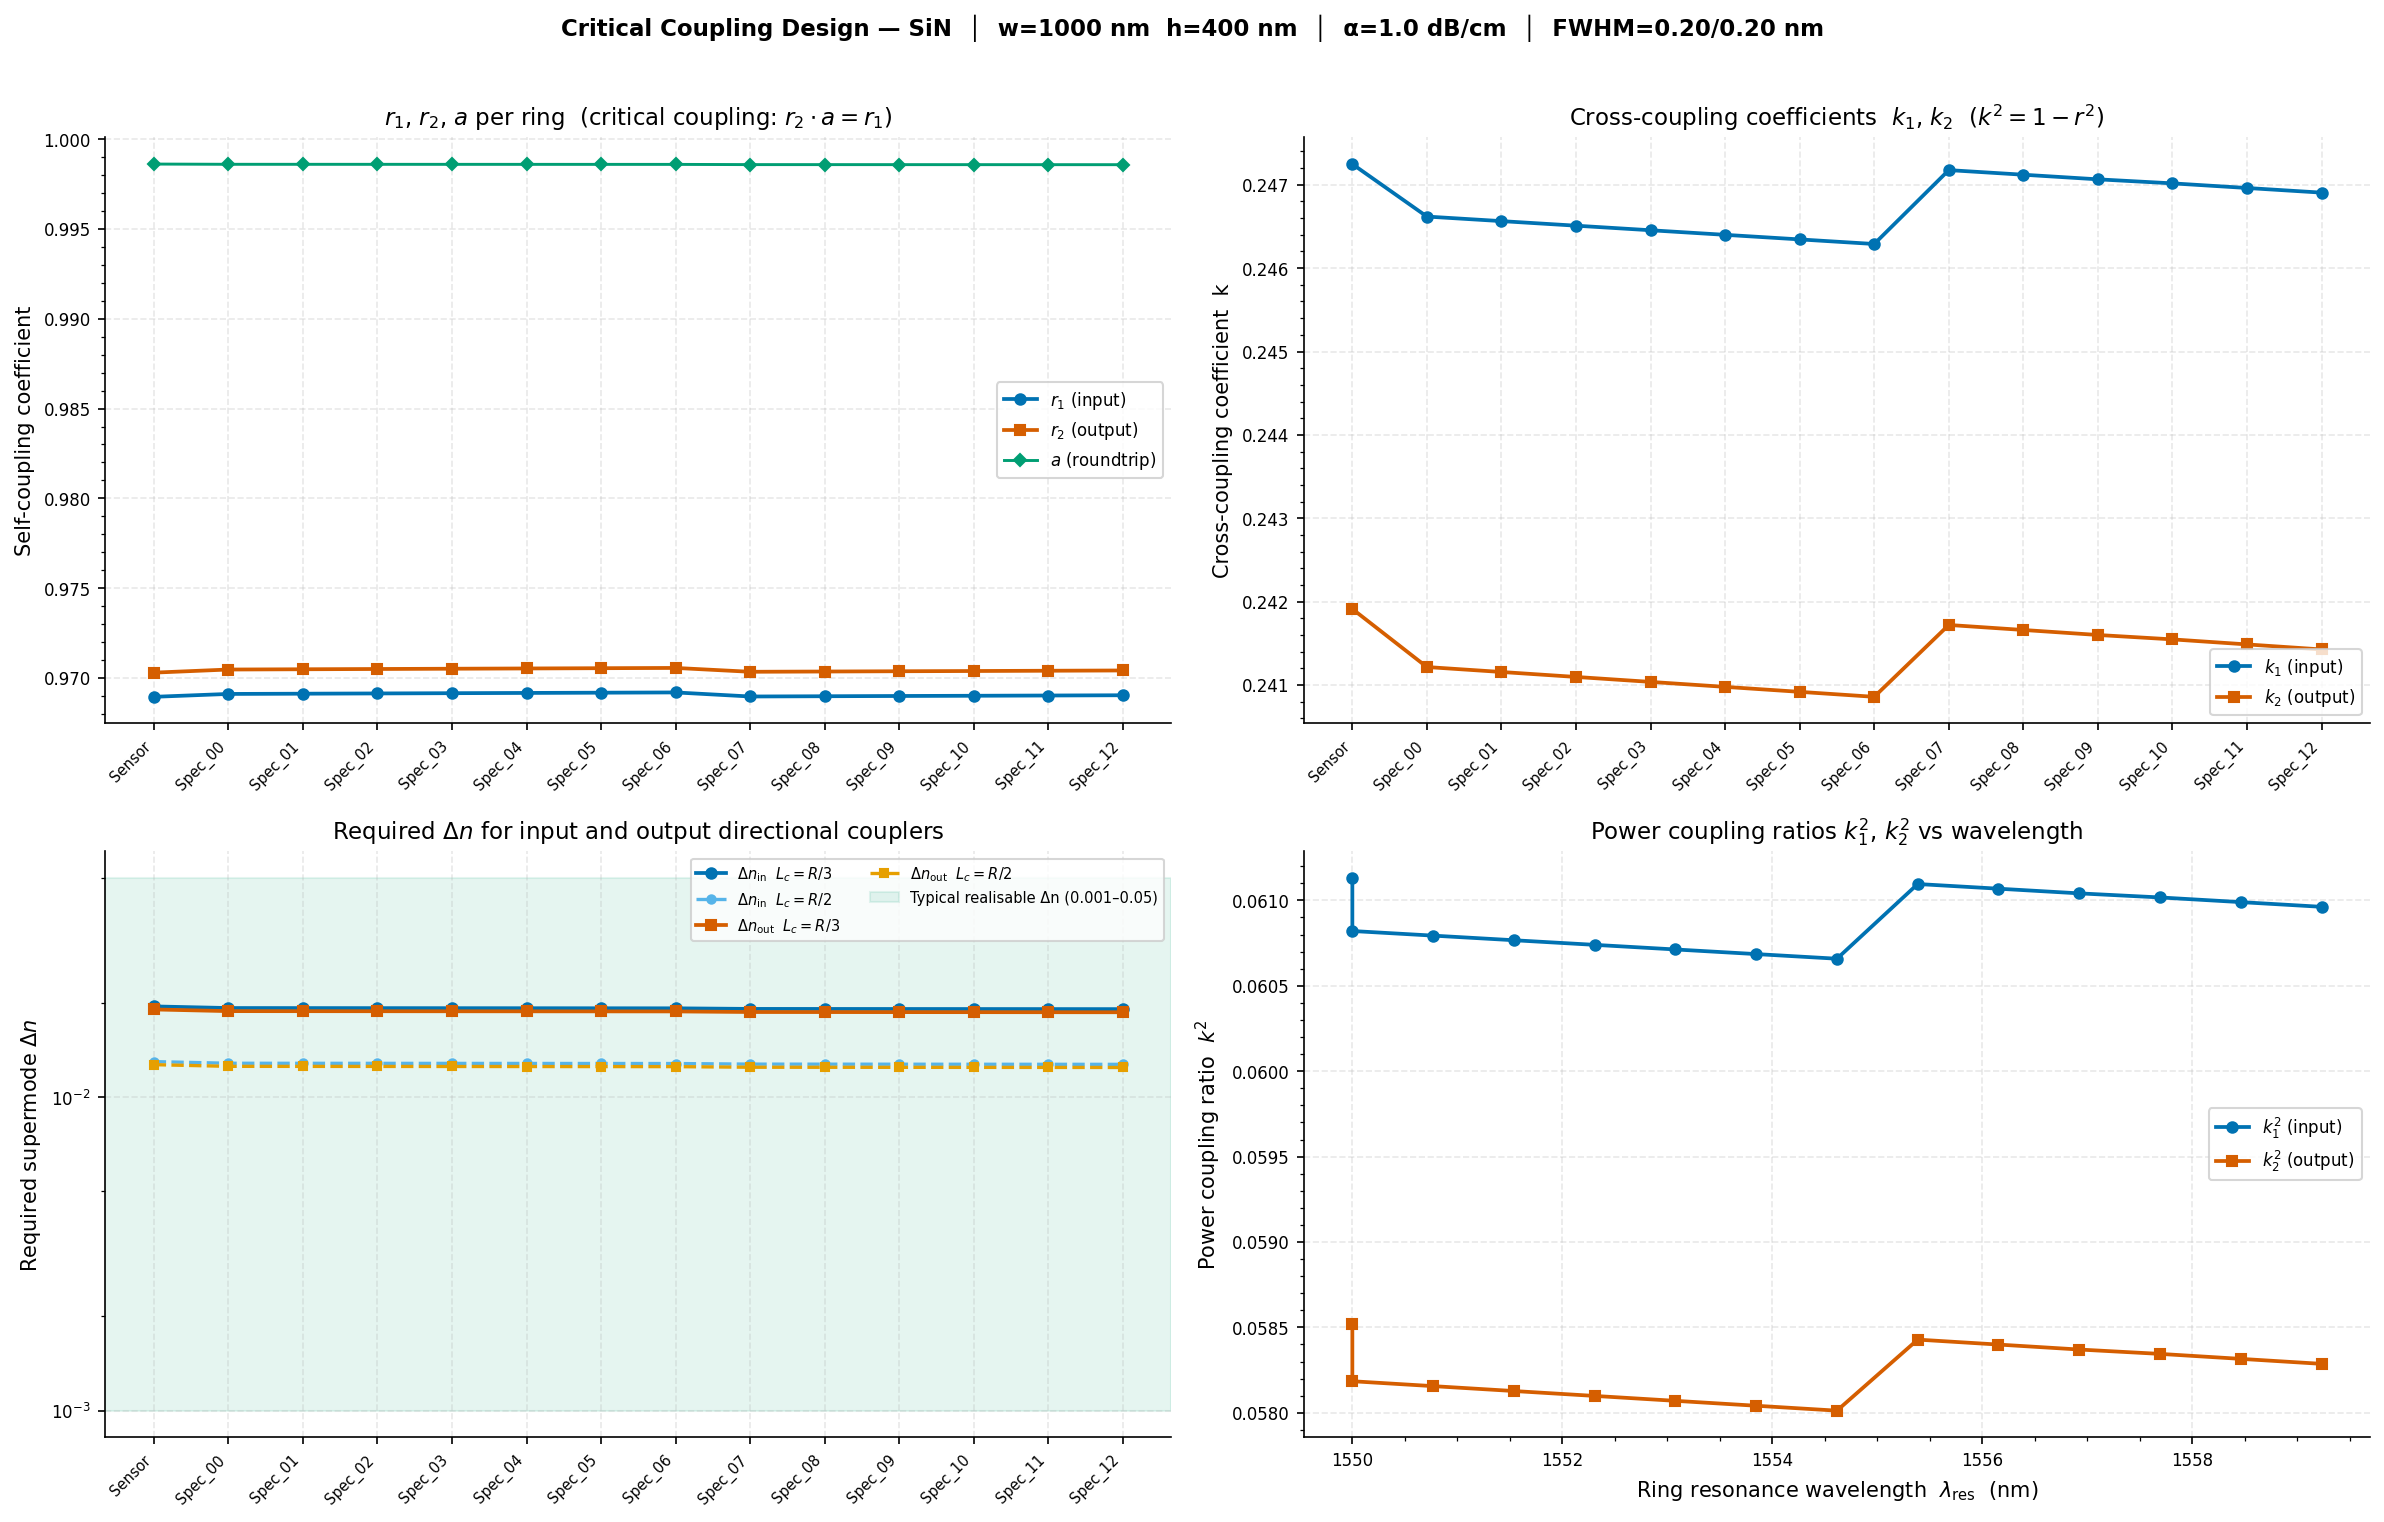


  Exported arrays (shape = (14,), index 0 = sensor ring):
    cc_labels
    cc_lam_res_nm
    cc_R_pm_um
    cc_L_pm_um
    cc_a
    cc_r1
    cc_r2
    cc_k1
    cc_k2
    cc_Q_target
    cc_FWHM_nm
    cc_Lc_a_um
    cc_Lc_b_um
    cc_dn_in_a
    cc_dn_in_b
    cc_dn_out_a
    cc_dn_out_b

  Next step: gap sweep using FDE supermode analysis to find the
  waveguide separation that yields each target Δn at the coupling
  section wavelength (CELL 12).


In [8]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — Critical Coupling Engineering  (analytical, no new FDE)         ║
# ║                                                                              ║
# ║  Theory reference: Bogaerts et al., Laser Photonics Rev. 6, 47-73 (2012)   ║
# ║                                                                              ║
# ║  For each of the 14 rings (1 sensor + 13 spectrometer) this cell:           ║
# ║    1.  Accepts a target FWHM (→ Q-factor) per ring as input.                ║
# ║    2.  Estimates the round-trip amplitude transmission  a  from              ║
# ║          a = exp(−α_total · L / 2)                                          ║
# ║        where α_total includes SiN bulk propagation loss + bend radiation    ║
# ║        loss interpolated from the FDE imaginary neff (bend loss) obtained   ║
# ║        in earlier cells.                                                     ║
# ║    3.  Solves for r1 (input self-coupling) from the Q-factor equation       ║
# ║        (Bogaerts Eq. 20) for an add-drop resonator.                         ║
# ║    4.  Enforces asymmetric critical coupling:  r2 = r1 / a                  ║
# ║        (Bogaerts Section 2.2: "critical coupling when r2·a = r1").          ║
# ║    5.  Derives cross-coupling coefficients  k1, k2  from  k² = 1 − r².     ║
# ║    6.  Computes the required supermode index difference  Δn  for two        ║
# ║        coupling-section lengths Lc:                                          ║
# ║          • Lc_a = FRAC_A × R_pm   (default 1/3 of ring radius)              ║
# ║          • Lc_b = FRAC_B × R_pm   (default 1/2 of ring radius)              ║
# ║        Using the directional-coupler transfer formula:                       ║
# ║          k = sin(π · Δn · Lc / λ)  →  Δn = λ · arcsin(k) / (π · Lc)       ║
# ║                                                                              ║
# ║  Requires from earlier cells (already in kernel scope):                      ║
# ║    np, log, datetime                                                         ║
# ║    CORE_THICKNESS_UM, N_SIN_FIXED, N_SIO2_FIXED, N_UPPER_CLADDING          ║
# ║    N_UPPER_CLADDING_SIO2                                                     ║
# ║    RR_WG_WIDTH_NM, RR_FSR_NM, RR_LAM0_NM                                   ║
# ║    R_pm_um, L_pm_um, neff_pm, ng_straight   (sensor ring from Cell 9)       ║
# ║    spec_R_pm_um, spec_L_pm_um, spec_neff_pm, spec_ng_pm, spec_lam_res_pm_nm ║
# ║    spec_m, spec_FSR_pm_nm                   (spectrometer rings, Cell 10)   ║
# ║    _neff_arr, _ng_arr, _neff_lo_arr, _neff_hi_arr   (sensor ring FDE)       ║
# ║    _lam0_m, _lam_lo_m, _lam_hi_m, _dlam_m          (sensor ring stencil)   ║
# ║    _spec_results                             (ring dict from Cell 10)        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ═════════════════════════════════════════════════════════════════════════════
# SECTION 0 — USER-EDITABLE DESIGN PARAMETERS
# ═════════════════════════════════════════════════════════════════════════════

# ── Target FWHM for each ring  [nm] ──────────────────────────────────────────
# Two ways to specify:
#   FWHM_SENSOR_NM   : single value for the sensor ring
#   FWHM_SPEC_NM     : single value applied to ALL spectrometer rings
#                      (override per-ring with FWHM_SPEC_OVERRIDE below)
#
# Physical reasoning:
#   • The FWHM must be < FSR (10 nm) to keep resonances resolvable.
#   • For biosensing, narrower linewidth → higher wavelength resolution,
#     but requires tighter fabrication tolerances and lower loss.
#   • A good starting point for SiN at 1550 nm is ~0.1–0.3 nm FWHM
#     (Q ≈ 5000–15000).
# ──────────────────────────────────────────────────────────────────────────────
FWHM_SENSOR_NM      = 0.2        # [nm]  sensor ring target FWHM
FWHM_SPEC_NM        = 0.2        # [nm]  spectrometer rings default FWHM

# Per-ring FWHM override for spectrometer rings (dict: ring_idx → FWHM [nm])
# Leave empty {} to use FWHM_SPEC_NM for all 13 rings.
FWHM_SPEC_OVERRIDE  = {}         # example: {0: 0.15, 12: 0.25}

# ── Propagation loss  [dB/cm] ─────────────────────────────────────────────────
# SiN at 1550 nm — literature / process estimates.
# This is α_prop in dB/cm, used to compute α_prop in 1/m.
# Will be combined with bend radiation loss extracted from FDE (Im[neff]).
# Typical range for LPCVD SiN: 0.5–3 dB/cm.
ALPHA_PROP_DB_CM    = 1.0        # [dB/cm]  bulk SiN propagation loss

# ── Coupling section length fractions ─────────────────────────────────────────
# Lc = FRAC × R_pm for each ring.
# Two fractions are evaluated in parallel; choose the one that gives
# a physically realisable Δn (0.001 < Δn < 0.05 is typically achievable
# with standard gap-based directional couplers in SiN).
FRAC_A              = 1.0 / 3.0  # first  Lc option: R_pm / 3
FRAC_B              = 1.0 / 2.0  # second Lc option: R_pm / 2

# ── Guard rails ───────────────────────────────────────────────────────────────
# FWHM must be within these bounds relative to FSR to be physically sensible.
FWHM_TO_FSR_MIN     = 0.005      # FWHM ≥ 0.5 % of FSR
FWHM_TO_FSR_MAX     = 0.30       # FWHM ≤ 30 % of FSR

# ── Print/report options ──────────────────────────────────────────────────────
PRINT_LOSS_DETAIL   = True       # show bend + propagation loss breakdown


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 1 — LOSS MODEL
# ═════════════════════════════════════════════════════════════════════════════
# Round-trip amplitude transmission:
#   a = exp(−α_total · L / 2)
#
# where  α_total [1/m]  =  α_prop  +  α_bend
#
# α_prop  from ALPHA_PROP_DB_CM (user input, constant for all rings)
# α_bend  from the FDE imaginary neff:
#   Im(neff) = α_bend · λ / (4π)   →   α_bend = 4π · Im(neff) / λ
#
# Im(neff) is available from Cell 8/10 FDE:  neff_complex = Re + i·Im
# In the existing code only neff_c.real is stored.  We need to re-derive
# Im(neff) from the stored arrays.
#
# Approach: for rings where we have neff_lo, neff_hi and neff (all real),
# bend radiation loss Im(neff) is NOT captured this way — it requires
# extracting the imaginary part from the FDE eigenvalue directly.
#
# Since the existing pipeline stores only Re(neff), we use two complementary
# approaches:
#
#  (A) For a conservative estimate: α_bend = 0 (bent FDE neff already
#      captures the phase shift; radiation loss is additional but small
#      for R > 10 µm in SiN at 1550 nm, typically < 0.01 dB/cm).
#
#  (B) User can supply measured or literature bend loss via
#      ALPHA_BEND_DB_CM_SENSOR and ALPHA_BEND_DB_CM_SPEC below.
#      Literature for SiN 400 nm × 1000 nm at R ≈ 18–20 µm:
#      bend radiation loss < 0.005 dB/cm — negligible vs propagation loss.
#
# This cell therefore models:
#   α_total ≈ α_prop  (propagation-loss dominated for R > 10 µm SiN)
# with a user-adjustable additional bend term.

ALPHA_BEND_DB_CM_SENSOR = 0.01   # [dB/cm]  estimated bend radiation, sensor ring
ALPHA_BEND_DB_CM_SPEC   = 0.01   # [dB/cm]  estimated bend radiation, all spec rings
# If you have per-ring bend loss from FDE imaginary neff,
# replace these with an array indexed by ring number.

# ── Convert propagation loss to field attenuation coefficient [1/m] ───────────
# Power loss:   α_power [dB/cm] → α_power [1/m]
#   α_power [Np/m] = α_power [dB/cm] × ln(10)/10 × 100
# Field (amplitude) loss coefficient:
#   α_field [1/m]  = α_power [Np/m] / 2
_ln10_over_10 = np.log(10) / 10.0          # ≈ 0.2303 Np/dB

def _db_cm_to_alpha_field(db_cm):
    """Convert dB/cm loss coefficient to field (amplitude) α [1/m]."""
    alpha_power_npm = db_cm * _ln10_over_10 * 100.0   # [Np/m]
    return alpha_power_npm / 2.0                        # field attenuation

_alpha_prop_field  = _db_cm_to_alpha_field(ALPHA_PROP_DB_CM)
_alpha_bend_sensor = _db_cm_to_alpha_field(ALPHA_BEND_DB_CM_SENSOR)
_alpha_bend_spec   = _db_cm_to_alpha_field(ALPHA_BEND_DB_CM_SPEC)

log.info(
    f"Loss model │ α_prop = {ALPHA_PROP_DB_CM:.2f} dB/cm  "
    f"→ α_field = {_alpha_prop_field:.4f} 1/m  │  "
    f"α_bend_sensor = {ALPHA_BEND_DB_CM_SENSOR:.3f} dB/cm  "
    f"α_bend_spec = {ALPHA_BEND_DB_CM_SPEC:.3f} dB/cm"
)


def _compute_a(L_um, alpha_field_total):
    """
    Round-trip amplitude transmission.
      a = exp(−α_field_total × L)
    L_um in µm, alpha_field_total in 1/m.
    Returns a (dimensionless, 0 < a < 1).
    """
    L_m = L_um * 1e-6
    return float(np.exp(-alpha_field_total * L_m))


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 2 — COUPLING COEFFICIENT SOLVER
# ═════════════════════════════════════════════════════════════════════════════
# For an add-drop resonator with asymmetric coupling (r1 ≠ r2):
#
# Q-factor (Bogaerts Eq. 22, loaded Q):
#   Q = π · ng · L · √(r1·r2·a) / (λ_res · (1 − r1·r2·a))
#
# Critical coupling condition (Bogaerts Section 2.2):
#   r2 · a = r1   →   r1 = r2 · a
#
# Substituting r1 = r2·a into the Q equation:
#   Q = π · ng · L · √(r2²·a²) / (λ_res · (1 − r2²·a²))
#     = π · ng · L · r2·a / (λ_res · (1 − (r2·a)²))
#
# Let  x = r2·a  (= r1 from critical coupling):
#   Q = π · ng · L · x / (λ_res · (1 − x²))
#
# Rearranging (quadratic in x):
#   Q · λ_res · (1 − x²) = π · ng · L · x
#   Q · λ_res · x² + π · ng · L · x − Q · λ_res = 0
#
# Solving with quadratic formula (positive root only):
#   A = Q · λ_res
#   B = π · ng · L
#   C = −Q · λ_res
#   x = (−B + √(B² − 4·A·C)) / (2·A)
#     = (−B + √(B² + 4·Q²·λ²)) / (2·Q·λ)
#
# Then:
#   r1 = x
#   r2 = x / a  = r1 / a     (critical coupling)
#   k1 = √(1 − r1²)
#   k2 = √(1 − r2²)
#
# Physical validity checks:
#   0 < r1 < 1, 0 < r2 < 1, 0 < k1 < 1, 0 < k2 < 1
#   r2 > r1  always (because r2 = r1/a and a < 1)

def _solve_critical_coupling(Q, lam_res_m, ng, L_um, a):
    """
    Solve for r1, r2, k1, k2 satisfying:
      - Target Q-factor for add-drop resonator
      - Asymmetric critical coupling: r1 = r2·a
      - Lossless coupler: k² + r² = 1

    Parameters
    ----------
    Q        : float  target loaded Q-factor
    lam_res_m: float  resonance wavelength [m]
    ng       : float  group index
    L_um     : float  round-trip length [µm]
    a        : float  round-trip amplitude transmission (0 < a < 1)

    Returns
    -------
    dict with keys: r1, r2, k1, k2, x, a, Q_achieved, FWHM_nm, valid
    """
    L_m  = L_um * 1e-6
    ngL  = ng * L_m                       # [m]

    # Quadratic: Q·λ·x² + π·ng·L·x − Q·λ = 0
    A    = Q * lam_res_m
    B    = np.pi * ngL
    disc = B**2 + 4.0 * A**2             # B² − 4AC = B² + 4Q²λ² > 0 always
    x    = (-B + np.sqrt(disc)) / (2.0 * A)   # x = r1

    r1   = float(np.clip(x, 0.0, 1.0 - 1e-9))
    r2   = float(np.clip(r1 / a, 0.0, 1.0 - 1e-9))
    k1   = float(np.sqrt(max(0.0, 1.0 - r1**2)))
    k2   = float(np.sqrt(max(0.0, 1.0 - r2**2)))

    # Verify achieved Q and FWHM
    prod     = r1 * r2 * a               # r1·r2·a
    if prod  < 1.0:
        Q_ach    = np.pi * ngL * np.sqrt(prod) / (lam_res_m * (1.0 - prod))
    else:
        Q_ach    = np.inf
    FWHM_nm  = lam_res_m / Q_ach * 1e9

    valid = (0.0 < r1 < 1.0) and (0.0 < r2 < 1.0) and (r2 >= r1)

    return {
        "r1":        r1,
        "r2":        r2,
        "k1":        k1,
        "k2":        k2,
        "x":         x,
        "a":         a,
        "Q_target":  Q,
        "Q_achieved":Q_ach,
        "FWHM_nm":   FWHM_nm,
        "valid":     valid,
    }


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 3 — DIRECTIONAL COUPLER Δn CALCULATION
# ═════════════════════════════════════════════════════════════════════════════
# From the Ansys Lumerical ring resonator tutorial, the power coupling
# coefficient of a directional coupler of length Lc is:
#
#   k² = sin²(π · Δn · Lc / λ)
#   k  = |sin(π · Δn · Lc / λ)|
#
# where Δn is the supermode index difference (even minus odd supermode neff).
# Inverting for Δn:
#
#   Δn = λ · arcsin(k) / (π · Lc)
#
# This is valid for k ≤ 1 (i.e. arcsin argument in [0,1]).
# If k > 1 (non-physical, indicates coupler cannot be realised with this Lc),
# we report Δn = NaN and flag the result.
#
# Note: arcsin returns values in [0, π/2], so Δn > 0 always.
# Higher-order branches (k > sin(π/2) = 1 is impossible, but for k close to 1
# the arcsin is near π/2 and Δn·Lc/λ approaches 0.5 — i.e. a half-coupling
# length). For shorter Lc a larger Δn is required, meaning a smaller gap.

def _compute_delta_n(k, lam_m, Lc_m):
    """
    Required supermode index difference for coupling coefficient k
    in a directional coupler of length Lc_m at wavelength lam_m.

    Returns Δn (dimensionless) or NaN if k > 1 or Lc_m ≤ 0.
    """
    if Lc_m <= 0.0 or k < 0.0:
        return float("nan")
    if k > 1.0:
        return float("nan")
    arg = float(np.clip(k, 0.0, 1.0))
    return lam_m * np.arcsin(arg) / (np.pi * Lc_m)


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 4 — BUILD RING PARAMETER LIST
# (one entry per ring: sensor + 13 spectrometer)
# ═════════════════════════════════════════════════════════════════════════════

# We represent the sensor ring (index -1 or "S") and spectrometer rings
# (indices 0..12) in a unified list for processing.

# ── Sensor ring parameters (from Cell 9) ─────────────────────────────────────
_sensor = {
    "label":      "Sensor",
    "ring_type":  "sensor",
    "lam_res_nm": float(RR_LAM0_NM),
    "R_pm_um":    float(R_pm_um),
    "L_pm_um":    float(L_pm_um),
    "neff_pm":    float(neff_pm),
    "ng":         float(rr_best_ng),         # from Cell 8 bent FDE
    "FSR_nm":     float(rr_FSR_pred_nm),
    "fwhm_nm":    float(FWHM_SENSOR_NM),
    "alpha_bend": _alpha_bend_sensor,
}

# ── Spectrometer ring parameters (from Cell 10) ───────────────────────────────
_spec_rings = []
for _n in range(N_SPEC_RINGS):
    _fwhm = FWHM_SPEC_OVERRIDE.get(_n, FWHM_SPEC_NM)
    _spec_rings.append({
        "label":      f"Spec_{_n:02d}",
        "ring_type":  "spectrometer",
        "ring_idx":   _n,
        "lam_res_nm": float(spec_lam_res_pm_nm[_n]),
        "R_pm_um":    float(spec_R_pm_um[_n]),
        "L_pm_um":    float(spec_L_pm_um[_n]),
        "neff_pm":    float(spec_neff_pm[_n]),
        "ng":         float(spec_ng_pm[_n]),
        "FSR_nm":     float(spec_FSR_pm_nm[_n]),
        "fwhm_nm":    float(_fwhm),
        "alpha_bend": _alpha_bend_spec,
    })

_all_rings = [_sensor] + _spec_rings   # 14 entries total


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 5 — MAIN CALCULATION LOOP
# ═════════════════════════════════════════════════════════════════════════════

_cc_results = []    # list of result dicts, one per ring

for _ring in _all_rings:
    _lam_res_m  = _ring["lam_res_nm"] * 1e-9
    _L_um       = _ring["L_pm_um"]
    _ng         = _ring["ng"]
    _fwhm_nm    = _ring["fwhm_nm"]
    _fsr_nm     = _ring["FSR_nm"]
    _R_pm_um    = _ring["R_pm_um"]

    # ── Validate FWHM against FSR guard rails ─────────────────────────────────
    _fwhm_ratio = _fwhm_nm / _fsr_nm
    if not (FWHM_TO_FSR_MIN <= _fwhm_ratio <= FWHM_TO_FSR_MAX):
        log.warning(
            f"  {_ring['label']:>10} │ FWHM/FSR = {_fwhm_ratio:.4f}  "
            f"(outside [{FWHM_TO_FSR_MIN}, {FWHM_TO_FSR_MAX}]) — proceeding anyway."
        )

    # ── Target Q ──────────────────────────────────────────────────────────────
    Q_target = _ring["lam_res_nm"] / _fwhm_nm

    # ── Round-trip loss ───────────────────────────────────────────────────────
    _alpha_total = _alpha_prop_field + _ring["alpha_bend"]
    _a           = _compute_a(_L_um, _alpha_total)

    # ── Solve for r1, r2 at critical coupling ─────────────────────────────────
    _cc = _solve_critical_coupling(Q_target, _lam_res_m, _ng, _L_um, _a)

    # ── Coupling section lengths ──────────────────────────────────────────────
    Lc_a_um = FRAC_A * _R_pm_um
    Lc_b_um = FRAC_B * _R_pm_um
    Lc_a_m  = Lc_a_um * 1e-6
    Lc_b_m  = Lc_b_um * 1e-6

    # ── Required Δn for each coupler (input and output) ───────────────────────
    # Input coupler (k1):
    dn_in_a  = _compute_delta_n(_cc["k1"], _lam_res_m, Lc_a_m)
    dn_in_b  = _compute_delta_n(_cc["k1"], _lam_res_m, Lc_b_m)
    # Output coupler (k2):
    dn_out_a = _compute_delta_n(_cc["k2"], _lam_res_m, Lc_a_m)
    dn_out_b = _compute_delta_n(_cc["k2"], _lam_res_m, Lc_b_m)

    # ── Assemble result ───────────────────────────────────────────────────────
    _res = {
        **_ring,
        "Q_target":    Q_target,
        "a":           _a,
        "a_dB":        -20.0 * np.log10(_a),           # round-trip amplitude loss [dB]
        "alpha_total": _alpha_total,
        "r1":          _cc["r1"],
        "r2":          _cc["r2"],
        "k1":          _cc["k1"],
        "k2":          _cc["k2"],
        "Q_achieved":  _cc["Q_achieved"],
        "FWHM_check_nm": _cc["FWHM_nm"],
        "valid":       _cc["valid"],
        # Coupling lengths [µm]
        "Lc_a_um":     Lc_a_um,
        "Lc_b_um":     Lc_b_um,
        # Required Δn (supermode index difference)
        "dn_in_a":     dn_in_a,          # input coupler,  Lc = R/3
        "dn_in_b":     dn_in_b,          # input coupler,  Lc = R/2
        "dn_out_a":    dn_out_a,         # output coupler, Lc = R/3
        "dn_out_b":    dn_out_b,         # output coupler, Lc = R/2
    }
    _cc_results.append(_res)

    if PRINT_LOSS_DETAIL:
        log.info(
            f"  {_ring['label']:>10} │ λ={_ring['lam_res_nm']:.4f} nm │ "
            f"R={_R_pm_um:.4f} µm │ L={_L_um:.4f} µm │ "
            f"α_tot={_alpha_total:.4f} 1/m │ a={_a:.6f} │ "
            f"Q={Q_target:.1f} │ r1={_cc['r1']:.6f} │ r2={_cc['r2']:.6f} │ "
            f"k1={_cc['k1']:.6f} │ k2={_cc['k2']:.6f} │ "
            f"valid={_cc['valid']}"
        )


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 6 — SUMMARY TABLES
# ═════════════════════════════════════════════════════════════════════════════

_SEP  = "─" * 148
_SEP2 = "═" * 148

print("\n\n")
print(_SEP2)
print("  CRITICAL COUPLING DESIGN — ANALYTICAL SUMMARY")
print(f"  SiN platform  │  w={RR_WG_WIDTH_NM:.0f} nm  h={CORE_THICKNESS_UM*1e3:.0f} nm  │  "
      f"α_prop={ALPHA_PROP_DB_CM:.2f} dB/cm  │  "
      f"FWHM_sensor={FWHM_SENSOR_NM:.3f} nm  FWHM_spec={FWHM_SPEC_NM:.3f} nm")
print(f"  Coupling fractions:  Lc_a = R_pm / {1/FRAC_A:.1f}  │  "
      f"Lc_b = R_pm / {1/FRAC_B:.1f}")
print(_SEP2)
print()

# ── Table 1: Loss and Q-factor ─────────────────────────────────────────────────
print("  TABLE 1 — Round-trip loss and target Q-factor")
print(_SEP)
_H1 = (f"  {'Ring':>10}  {'λ_res (nm)':>13}  {'R_pm (µm)':>11}  "
       f"{'L_pm (µm)':>11}  {'α [1/m]':>9}  {'a':>10}  "
       f"{'a (dB)':>8}  {'FWHM (nm)':>11}  {'Q_target':>12}  {'Q_check':>12}")
print(_H1)
print("  " + "─" * 144)
for _r in _cc_results:
    print(
        f"  {_r['label']:>10}  {_r['lam_res_nm']:>13.6f}  "
        f"{_r['R_pm_um']:>11.6f}  {_r['L_pm_um']:>11.6f}  "
        f"{_r['alpha_total']:>9.4f}  {_r['a']:>10.8f}  "
        f"{_r['a_dB']:>8.5f}  {_r['fwhm_nm']:>11.5f}  "
        f"{_r['Q_target']:>12.1f}  {_r['Q_achieved']:>12.1f}"
    )
print()

# ── Table 2: Critical coupling coefficients ────────────────────────────────────
print("  TABLE 2 — Asymmetric critical coupling coefficients  (r2·a = r1)")
print(_SEP)
_H2 = (f"  {'Ring':>10}  {'λ_res (nm)':>13}  "
       f"{'a':>10}  {'r1':>10}  {'r2':>10}  "
       f"{'k1':>10}  {'k2':>10}  "
       f"{'k1²':>10}  {'k2²':>10}  {'valid':>6}")
print(_H2)
print("  " + "─" * 144)
for _r in _cc_results:
    print(
        f"  {_r['label']:>10}  {_r['lam_res_nm']:>13.6f}  "
        f"{_r['a']:>10.8f}  {_r['r1']:>10.8f}  {_r['r2']:>10.8f}  "
        f"{_r['k1']:>10.8f}  {_r['k2']:>10.8f}  "
        f"{_r['k1']**2:>10.8f}  {_r['k2']**2:>10.8f}  "
        f"{'✓' if _r['valid'] else '✗':>6}"
    )
print()

# ── Table 3: Required Δn — Lc_a = R_pm/3 ─────────────────────────────────────
print(f"  TABLE 3 — Required supermode Δn  (Lc = R_pm/{1/FRAC_A:.0f})")
print(_SEP)
_H3 = (f"  {'Ring':>10}  {'λ_res (nm)':>13}  "
       f"{'Lc_a (µm)':>11}  "
       f"{'Δn_in (k1)':>14}  {'Δn_out (k2)':>14}  "
       f"{'k1':>10}  {'k2':>10}  "
       f"{'Lc·Δn_in/λ':>13}  {'Lc·Δn_out/λ':>13}")
print(_H3)
print("  " + "─" * 144)
for _r in _cc_results:
    _lam = _r["lam_res_nm"] * 1e-9
    _Lc  = _r["Lc_a_um"] * 1e-6
    _nd_in  = _r["dn_in_a"]
    _nd_out = _r["dn_out_a"]
    _ratio_in  = (_nd_in  * _Lc / _lam) if not np.isnan(_nd_in)  else float("nan")
    _ratio_out = (_nd_out * _Lc / _lam) if not np.isnan(_nd_out) else float("nan")
    print(
        f"  {_r['label']:>10}  {_r['lam_res_nm']:>13.6f}  "
        f"{_r['Lc_a_um']:>11.4f}  "
        f"{_nd_in:>14.8f}  {_nd_out:>14.8f}  "
        f"{_r['k1']:>10.8f}  {_r['k2']:>10.8f}  "
        f"{_ratio_in:>13.6f}  {_ratio_out:>13.6f}"
    )
print()

# ── Table 4: Required Δn — Lc_b = R_pm/2 ─────────────────────────────────────
print(f"  TABLE 4 — Required supermode Δn  (Lc = R_pm/{1/FRAC_B:.0f})")
print(_SEP)
_H4 = (f"  {'Ring':>10}  {'λ_res (nm)':>13}  "
       f"{'Lc_b (µm)':>11}  "
       f"{'Δn_in (k1)':>14}  {'Δn_out (k2)':>14}  "
       f"{'k1':>10}  {'k2':>10}  "
       f"{'Lc·Δn_in/λ':>13}  {'Lc·Δn_out/λ':>13}")
print(_H4)
print("  " + "─" * 144)
for _r in _cc_results:
    _lam = _r["lam_res_nm"] * 1e-9
    _Lc  = _r["Lc_b_um"] * 1e-6
    _nd_in  = _r["dn_in_b"]
    _nd_out = _r["dn_out_b"]
    _ratio_in  = (_nd_in  * _Lc / _lam) if not np.isnan(_nd_in)  else float("nan")
    _ratio_out = (_nd_out * _Lc / _lam) if not np.isnan(_nd_out) else float("nan")
    print(
        f"  {_r['label']:>10}  {_r['lam_res_nm']:>13.6f}  "
        f"{_r['Lc_b_um']:>11.4f}  "
        f"{_nd_in:>14.8f}  {_nd_out:>14.8f}  "
        f"{_r['k1']:>10.8f}  {_r['k2']:>10.8f}  "
        f"{_ratio_in:>13.6f}  {_ratio_out:>13.6f}"
    )
print()
print(_SEP2)

# ── Quick sanity check ────────────────────────────────────────────────────────
_n_invalid = sum(1 for _r in _cc_results if not _r["valid"])
if _n_invalid:
    log.warning(
        f"  {_n_invalid} ring(s) have invalid coupling solutions. "
        "Check FWHM targets — they may require r2 > 1 (too narrow for this loss level)."
    )
else:
    log.info("  All 14 rings have valid critical-coupling solutions.")

print()
print("  PHYSICAL INTERPRETATION GUIDE")
print("  " + "─" * 90)
print(f"  r1 < r2  always (r2 = r1/a > r1 since a < 1) — asymmetric coupling required.")
print(f"  k1 > k2  because r1 < r2  (input coupler stronger than output coupler).")
print(f"  Δn_in > Δn_out  because k1 > k2 at the same Lc.")
print(f"  Δn  is the even–odd supermode index splitting in the coupling section.")
print(f"  Smaller gap between waveguides → larger Δn.")
print(f"  Target range for realisable SiN gap couplers: 0.001 < Δn < 0.05.")
print(f"  Values outside this range indicate Lc needs adjustment.")
print()


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 7 — FIGURES
# ═════════════════════════════════════════════════════════════════════════════

plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "legend.fontsize":   8,
    "lines.linewidth":   1.8,
    "lines.markersize":  6,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.28,
    "grid.linestyle":    "--",
})

_labels     = [_r["label"]      for _r in _cc_results]
_lam_v      = [_r["lam_res_nm"] for _r in _cc_results]
_r1_v       = [_r["r1"]         for _r in _cc_results]
_r2_v       = [_r["r2"]         for _r in _cc_results]
_k1_v       = [_r["k1"]         for _r in _cc_results]
_k2_v       = [_r["k2"]         for _r in _cc_results]
_a_v        = [_r["a"]          for _r in _cc_results]
_dn_in_a_v  = [_r["dn_in_a"]    for _r in _cc_results]
_dn_out_a_v = [_r["dn_out_a"]   for _r in _cc_results]
_dn_in_b_v  = [_r["dn_in_b"]    for _r in _cc_results]
_dn_out_b_v = [_r["dn_out_b"]   for _r in _cc_results]
_x_idx      = np.arange(len(_cc_results))
_x_labels   = [r["label"] for r in _cc_results]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    f"Critical Coupling Design — SiN  │  "
    f"w={RR_WG_WIDTH_NM:.0f} nm  h={CORE_THICKNESS_UM*1e3:.0f} nm  │  "
    f"α={ALPHA_PROP_DB_CM:.1f} dB/cm  │  FWHM={FWHM_SENSOR_NM:.2f}/{FWHM_SPEC_NM:.2f} nm",
    fontsize=11, fontweight="bold", y=1.01,
)

# Panel (0,0) — r1, r2 and a vs ring index
ax00 = axes[0, 0]
ax00.plot(_x_idx, _r1_v, "o-", color="#0072B2", lw=1.8, ms=5, label=r"$r_1$ (input)")
ax00.plot(_x_idx, _r2_v, "s-", color="#D55E00", lw=1.8, ms=5, label=r"$r_2$ (output)")
ax00.plot(_x_idx, _a_v,  "D-", color="#009E73", lw=1.4, ms=4, label=r"$a$ (roundtrip)")
ax00.set_xticks(_x_idx)
ax00.set_xticklabels(_x_labels, rotation=45, ha="right", fontsize=7)
ax00.set_ylabel("Self-coupling coefficient")
ax00.set_title(r"$r_1$, $r_2$, $a$ per ring  (critical coupling: $r_2 \cdot a = r_1$)")
ax00.legend()
ax00.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Panel (0,1) — k1, k2 vs ring index
ax01 = axes[0, 1]
ax01.plot(_x_idx, _k1_v, "o-", color="#0072B2", lw=1.8, ms=5, label=r"$k_1$ (input)")
ax01.plot(_x_idx, _k2_v, "s-", color="#D55E00", lw=1.8, ms=5, label=r"$k_2$ (output)")
ax01.set_xticks(_x_idx)
ax01.set_xticklabels(_x_labels, rotation=45, ha="right", fontsize=7)
ax01.set_ylabel("Cross-coupling coefficient  k")
ax01.set_title(r"Cross-coupling coefficients  $k_1$, $k_2$  ($k^2 = 1 - r^2$)")
ax01.legend()
ax01.yaxis.set_minor_locator(ticker.AutoMinorLocator())

# Panel (1,0) — Δn input coupler vs ring  [LOG SCALE]
ax10 = axes[1, 0]
ax10.semilogy(_x_idx, _dn_in_a_v,  "o-", color="#0072B2", lw=1.8, ms=5,
              label=rf"$\Delta n_\mathrm{{in}}$  $L_c = R/3$")
ax10.semilogy(_x_idx, _dn_in_b_v,  "o--", color="#56B4E9", lw=1.6, ms=4,
              label=rf"$\Delta n_\mathrm{{in}}$  $L_c = R/2$")
ax10.semilogy(_x_idx, _dn_out_a_v, "s-", color="#D55E00", lw=1.8, ms=5,
              label=rf"$\Delta n_\mathrm{{out}}$  $L_c = R/3$")
ax10.semilogy(_x_idx, _dn_out_b_v, "s--", color="#E69F00", lw=1.6, ms=4,
              label=rf"$\Delta n_\mathrm{{out}}$  $L_c = R/2$")
# Reference band for realisable Δn
ax10.axhspan(0.001, 0.05, alpha=0.10, color="#009E73",
             label="Typical realisable Δn (0.001–0.05)")
ax10.set_xticks(_x_idx)
ax10.set_xticklabels(_x_labels, rotation=45, ha="right", fontsize=7)
ax10.set_ylabel(r"Required supermode $\Delta n$")
ax10.set_title(r"Required $\Delta n$ for input and output directional couplers")
ax10.legend(fontsize=7, ncol=2)
# FIX: ax10 uses semilogy (log scale). AutoMinorLocator does not accept 'subs'.
# Use LogLocator with subs=[2, 5] to place minor ticks at 2x and 5x positions
# on the log axis, which was the original intent.
ax10.yaxis.set_minor_locator(ticker.LogLocator(subs=[2, 5]))

# Panel (1,1) — k² (power coupling) vs ring wavelength
ax11 = axes[1, 1]
ax11.plot(_lam_v, [k**2 for k in _k1_v], "o-", color="#0072B2",
          lw=1.8, ms=5, label=r"$k_1^2$ (input)")
ax11.plot(_lam_v, [k**2 for k in _k2_v], "s-", color="#D55E00",
          lw=1.8, ms=5, label=r"$k_2^2$ (output)")
ax11.set_xlabel(r"Ring resonance wavelength  $\lambda_\mathrm{res}$  (nm)")
ax11.set_ylabel("Power coupling ratio  $k^2$")
ax11.set_title(r"Power coupling ratios $k_1^2$, $k_2^2$ vs wavelength")
ax11.legend()
ax11.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax11.yaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()

_fig_stem = DATA_DIR / f"{VERSION_NAME}_critical_coupling_design"
for _ext in (".png", ".pdf"):
    plt.savefig(str(_fig_stem) + _ext, dpi=150, bbox_inches="tight")
    print(f"  Saved → {str(_fig_stem) + _ext}")

plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 8 — EXPORT TO DOWNSTREAM CELLS
# ═════════════════════════════════════════════════════════════════════════════

# Exported as parallel arrays (index 0 = sensor, 1..13 = spectrometer rings)
cc_labels      = [_r["label"]      for _r in _cc_results]
cc_lam_res_nm  = np.array([_r["lam_res_nm"]  for _r in _cc_results])
cc_R_pm_um     = np.array([_r["R_pm_um"]     for _r in _cc_results])
cc_L_pm_um     = np.array([_r["L_pm_um"]     for _r in _cc_results])
cc_a           = np.array([_r["a"]           for _r in _cc_results])
cc_r1          = np.array([_r["r1"]          for _r in _cc_results])
cc_r2          = np.array([_r["r2"]          for _r in _cc_results])
cc_k1          = np.array([_r["k1"]          for _r in _cc_results])
cc_k2          = np.array([_r["k2"]          for _r in _cc_results])
cc_Q_target    = np.array([_r["Q_target"]    for _r in _cc_results])
cc_FWHM_nm     = np.array([_r["fwhm_nm"]     for _r in _cc_results])
cc_Lc_a_um     = np.array([_r["Lc_a_um"]     for _r in _cc_results])
cc_Lc_b_um     = np.array([_r["Lc_b_um"]     for _r in _cc_results])
cc_dn_in_a     = np.array([_r["dn_in_a"]     for _r in _cc_results])   # Δn input,  Lc=R/3
cc_dn_in_b     = np.array([_r["dn_in_b"]     for _r in _cc_results])   # Δn input,  Lc=R/2
cc_dn_out_a    = np.array([_r["dn_out_a"]    for _r in _cc_results])   # Δn output, Lc=R/3
cc_dn_out_b    = np.array([_r["dn_out_b"]    for _r in _cc_results])   # Δn output, Lc=R/2

print()
print("  Exported arrays (shape = (14,), index 0 = sensor ring):")
for _vn in [
    "cc_labels", "cc_lam_res_nm", "cc_R_pm_um", "cc_L_pm_um",
    "cc_a", "cc_r1", "cc_r2", "cc_k1", "cc_k2",
    "cc_Q_target", "cc_FWHM_nm",
    "cc_Lc_a_um", "cc_Lc_b_um",
    "cc_dn_in_a", "cc_dn_in_b", "cc_dn_out_a", "cc_dn_out_b",
]:
    print(f"    {_vn}")

print()
print("  Next step: gap sweep using FDE supermode analysis to find the")
print("  waveguide separation that yields each target Δn at the coupling")
print("  section wavelength (CELL 12).")

18:59:07 │ INFO │ Job list: 28 coupler sweeps  (100 gaps each  →  max 2800 FDE solves if uncached)
18:59:07 │ INFO │ Cache status: 0/28 jobs fully cached.
18:59:07 │ INFO │ Launching Lumerical MODE session …


  DIRECTIONAL COUPLER GAP SWEEP — All 14 rings, input + output
  Gap range       : 150 – 450 nm  (100 pts)
  Lc selector     : 'a'  (Lc = R_pm × 0.3333)
  Total couplers  : 28  (14 rings × 2)
  FDE domain Y    : 8.0 µm  (103 cells)  Z: 4.4 µm  (57 cells)
  Max solves      : 2800 (if nothing cached)
  HDF5 files      : LUM_SiN_STRp_400nm_wdth_sweep_V1.h5 (sensor)
                    LUM_SiN_STRp_400nm_wdth_sweep_SiO2clad_V1.h5 (spectrometer)



18:59:11 │ INFO │   Job 01/28      Sensor   input  λ=1550.0000 nm  n_upper=1.3300  cached 0/100



  Sensor  input  λ=1550.0000 nm  target Δn=0.01946093
    gap(nm)        n_even         n_odd              Δn    te_e    te_o  src
  ──────────────────────────────────────────────────────────────────────────
     150.00    1.63707918    1.58984346    0.0472357230  0.9966  0.9954  FDE
     153.03    1.63669693    1.58991783    0.0467790971  0.9966  0.9954  FDE
     156.06    1.63155036    1.58990448    0.0416458840  0.9966  0.9958  FDE
     159.09    1.63115777    1.58994755    0.0412102253  0.9965  0.9957  FDE
     162.12    1.63080428    1.59006407    0.0407402038  0.9965  0.9957  FDE
     165.15    1.63046289    1.59018272    0.0402801717  0.9965  0.9957  FDE
     168.18    1.63013332    1.59030351    0.0398298011  0.9964  0.9957  FDE
     171.21    1.62981525    1.59042647    0.0393887800  0.9964  0.9957  FDE
     174.24    1.62954700    1.59061277    0.0389342328  0.9964  0.9958  FDE


18:59:41 │ INFO │     [ 10/100]  gap=177.3 nm  Δn=0.03785728  ETA 270 s


...

     419.70    1.63831496    1.62044856    0.0178663964  0.9964  0.9960  FDE
     422.73    1.63814298    1.62045665    0.0176863348  0.9964  0.9960  FDE
     425.76    1.63797903    1.62046959    0.0175094406  0.9964  0.9960  FDE
     428.79    1.63782301    1.62048740    0.0173356092  0.9964  0.9960  FDE
     431.82    1.63797827    1.62069408    0.0172841959  0.9965  0.9961  FDE
     434.85    1.63783165    1.62071830    0.0171133453  0.9965  0.9961  FDE
     437.88    1.63769276    1.62074740    0.0169453587  0.9965  0.9961  FDE
     440.91    1.63756149    1.62078134    0.0167801573  0.9965  0.9961  FDE
     443.94    1.63743773    1.62082006    0.0166176689  0.9965  0.9961  FDE
     446.97    1.63732136    1.62086353    0.0164578273  0.9965  0.9961  FDE


21:23:17 │ INFO │     [100/100]  gap=450.0 nm  Δn=0.01630057  ETA 0 s


     450.00    1.63721227    1.62091170    0.0163005722  0.9965  0.9961  FDE


21:23:18 │ INFO │ Lumerical MODE session closed.
21:23:18 │ INFO │ All 28 coupler sweeps complete (or loaded from cache).
21:23:18 │ INFO │       Sensor   input  Δn_tgt=0.01946093  gap=343.70 nm  Δn_sim=0.01946093  err=0.000%  k=0.247249  IN RANGE
21:23:18 │ INFO │       Sensor  output  Δn_tgt=0.01903222  gap=350.94 nm  Δn_sim=0.01903221  err=0.000%  k=0.241912  IN RANGE
21:23:18 │ INFO │      Spec_00   input  Δn_tgt=0.01922847  gap=395.86 nm  Δn_sim=0.01922850  err=0.000%  k=0.246619  IN RANGE
21:23:18 │ INFO │      Spec_00  output  Δn_tgt=0.01879851  gap=402.43 nm  Δn_sim=0.01879835  err=0.001%  k=0.241213  IN RANGE
21:23:18 │ INFO │      Spec_01   input  Δn_tgt=0.01922197  gap=396.42 nm  Δn_sim=0.01922217  err=0.001%  k=0.246567  IN RANGE
21:23:18 │ INFO │      Spec_01  output  Δn_tgt=0.01879169  gap=403.05 nm  Δn_sim=0.01879188  err=0.001%  k=0.241158  IN RANGE
21:23:18 │ INFO │      Spec_02   input  Δn_tgt=0.01921547  gap=397.01 nm  Δn_sim=0.01921554  err=0.000%  k=0.246510  IN RA




══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  DIRECTIONAL COUPLER SYNTHESIS — COMPLETE SUMMARY
  Gap sweep 150–450 nm  │  Lc = R_pm × 0.3333  │  Asymmetric critical coupling: r₂·a = r₁  →  k₁ ≠ k₂
══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════

        Ring    Plt     λ_res(nm)  Coupler   k_target      Δn_target    Gap_opt(nm)         Δn_sim     err%     k_ach    Lc(µm)    OK
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      Sensor     Aq   1550.000000    input   0.247249    0.019460933        343.702    0.019460931    0.000  0.247249    6.3340     ✓
      Sensor     Aq   1550.000000   output   0.241912    0.019032216        350.941    0.019032215  

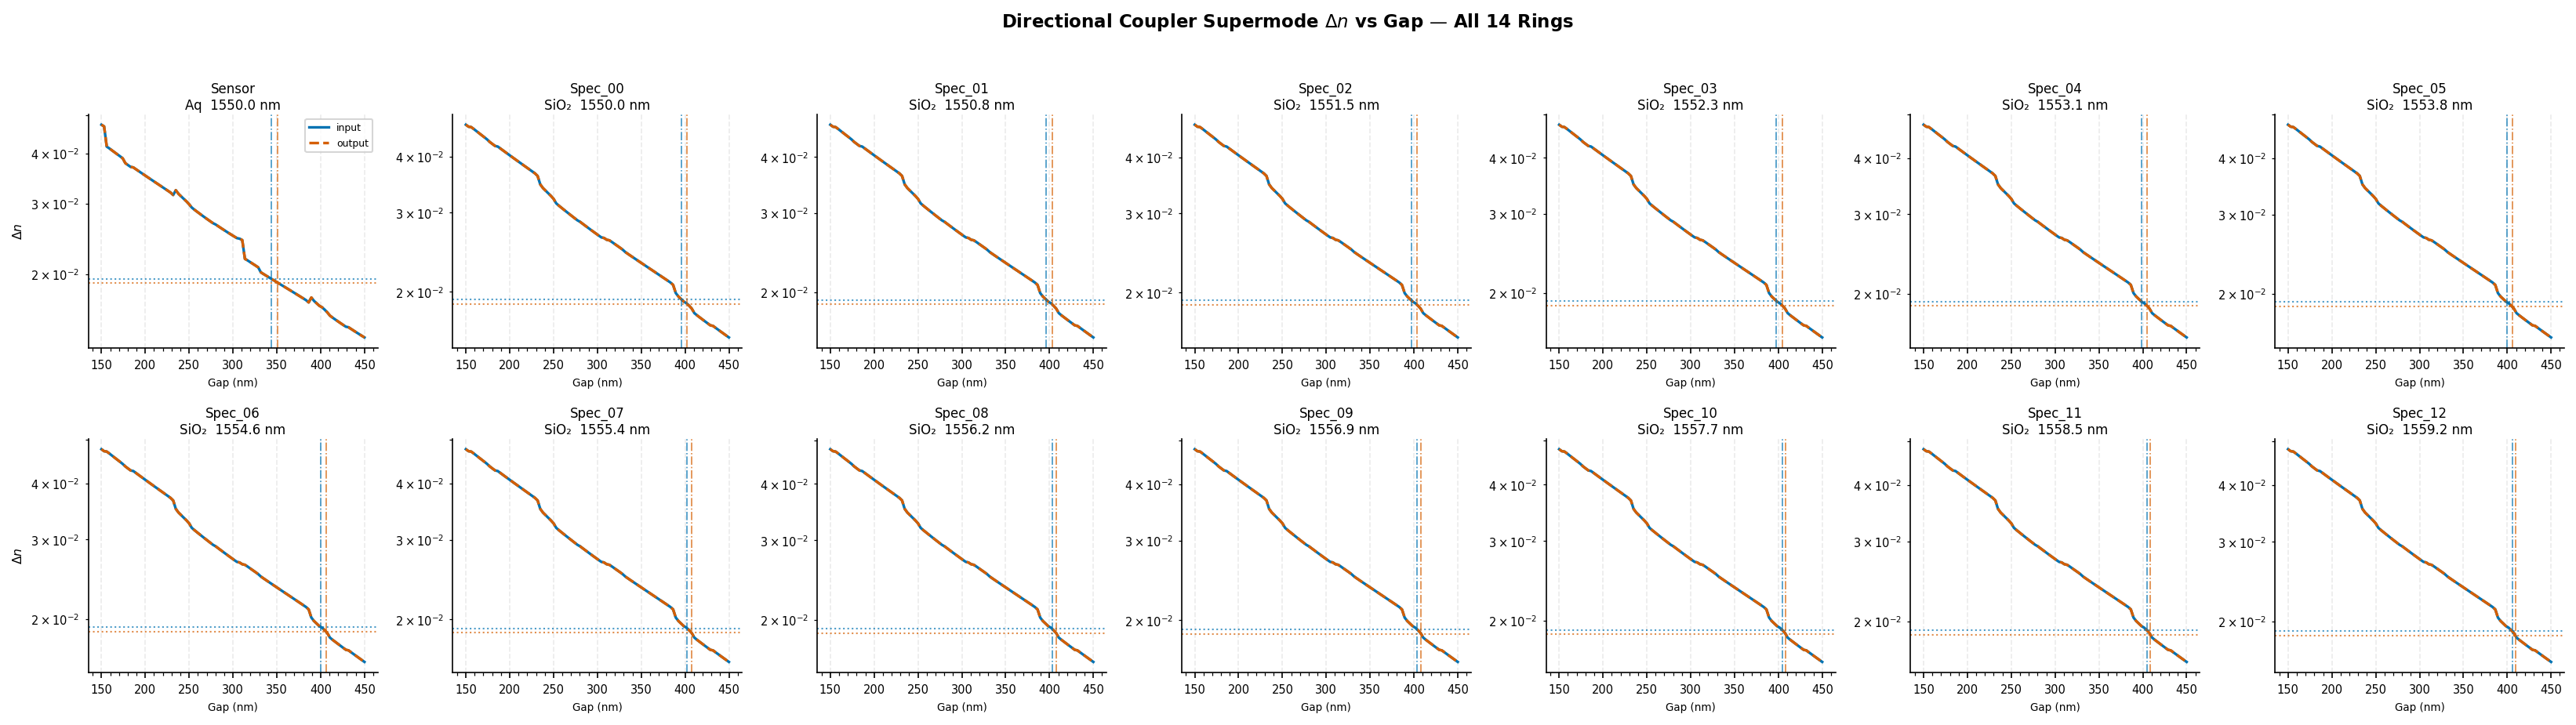

  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1_dc_optimal_gaps.png
  Saved → D:\GitHub\GDS_py_TDY_venv\Fabrication_designs\Lumerical_scripts\data_STRp_SiN_mode_analysis_LUM\LUM_SiN_STRp_400nm_wdth_sweep_V1_dc_optimal_gaps.pdf


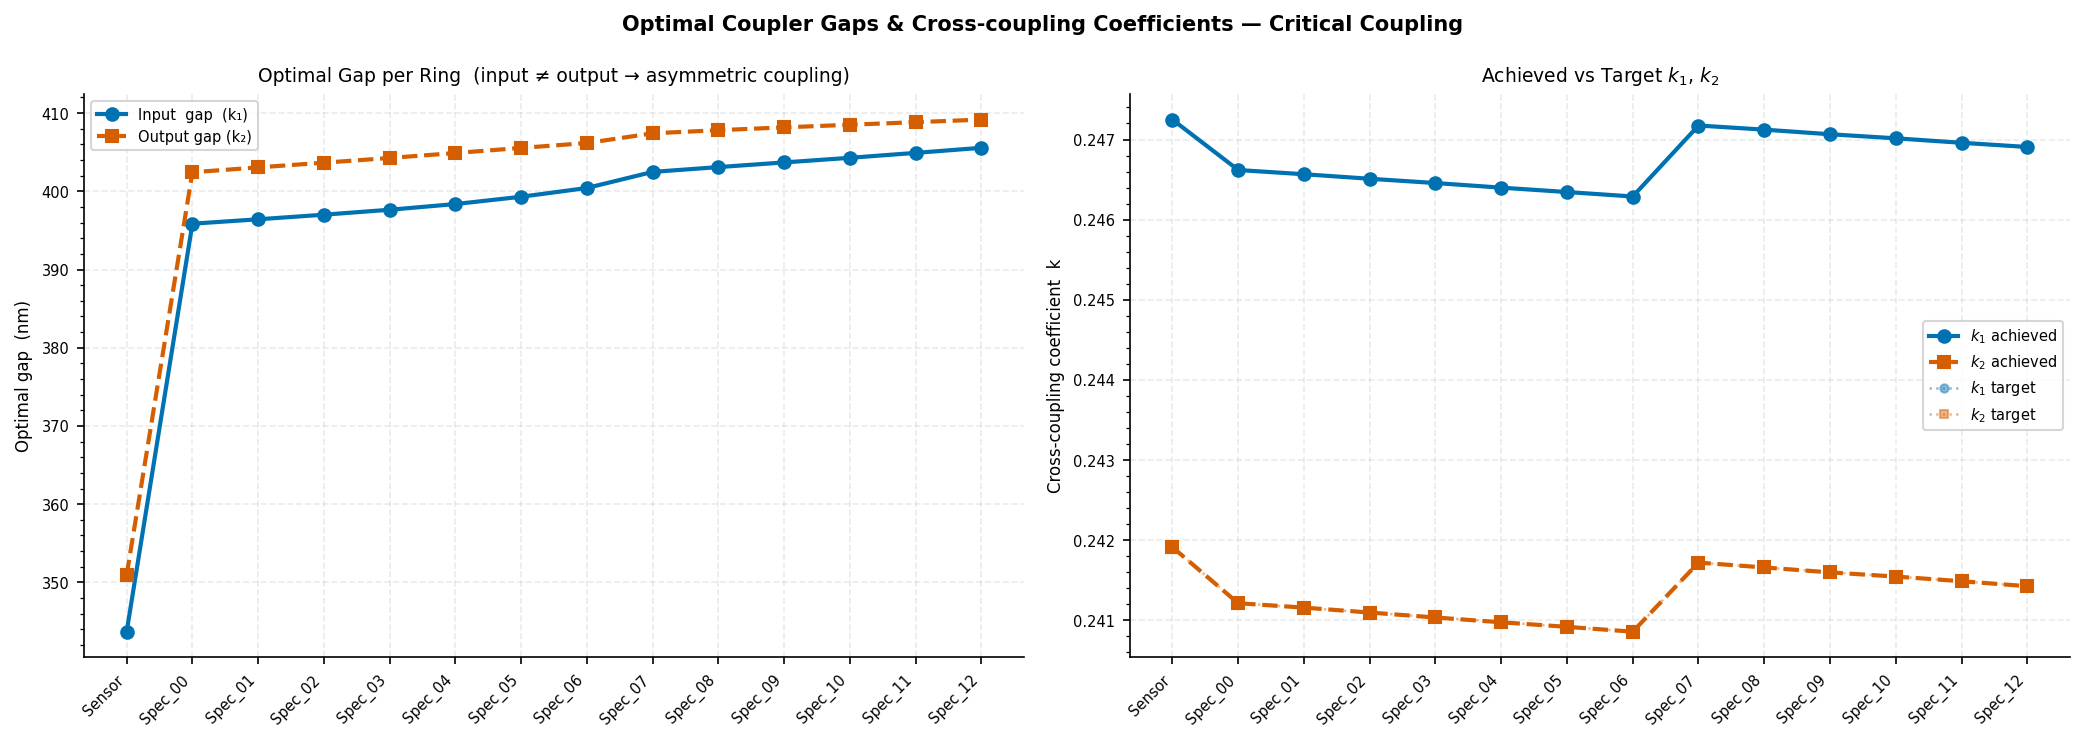


  Exported arrays (shape = (14,), index 0 = sensor ring):
    dc_gap_input_nm
    dc_gap_output_nm
    dc_dn_input_sim
    dc_dn_output_sim
    dc_k1_achieved
    dc_k2_achieved
    dc_err_input_pct
    dc_err_output_pct

  Next step → CELL 13: FDTD/varFDTD validation using these gap values.


In [9]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — Directional Coupler Gap Sweep  (all 14 rings, both couplers)    ║
# ║                                                                              ║
# ║  Requires from earlier cells (verified from notebook):                       ║
# ║    lumapi, np, h5py, log, time, Path, datetime               ← Cell 1       ║
# ║    VERSION_NAME, DATA_DIR, HDF5_PATH                         ← Cell 1       ║
# ║    VERSION_NAME_SIO2, HDF5_PATH_SIO2                         ← Cell 4       ║
# ║    N_SIN_FIXED (1.99), N_SIO2_FIXED (1.4469)                ← Cell 1       ║
# ║    N_UPPER_CLADDING (1.33), N_UPPER_CLADDING_SIO2 (1.4469)  ← Cells 1,4   ║
# ║    CORE_THICKNESS_UM (0.4), N_MODES_REQUEST (6)              ← Cell 1       ║
# ║    SIM_Z_BELOW_UM (2.0), SIM_Z_ABOVE_UM (2.0)               ← Cell 1       ║
# ║    MESH_CELLS_Y, MESH_CELLS_Z                                ← Cell 1       ║
# ║    cc_labels[14], cc_lam_res_nm[14]                          ← Cell 11      ║
# ║    cc_k1[14], cc_k2[14]                                      ← Cell 11      ║
# ║    cc_dn_in_a[14], cc_dn_in_b[14]                           ← Cell 11      ║
# ║    cc_dn_out_a[14], cc_dn_out_b[14]                          ← Cell 11      ║
# ║    cc_Lc_a_um[14], cc_Lc_b_um[14]                           ← Cell 11      ║
# ║    FRAC_A, FRAC_B                                             ← Cell 11      ║
# ║                                                                              ║
# ║  N_SPEC_RINGS is defined locally here (= 13) to avoid dependency on Cell 10 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from scipy.interpolate import interp1d
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ═════════════════════════════════════════════════════════════════════════════
# SECTION 0 — CONFIGURATION
# ═════════════════════════════════════════════════════════════════════════════

# ── Ring count (define locally — avoids fragile cross-cell dependency) ────────
_DC_N_RINGS    = 14         # 1 sensor (index 0) + 13 spectrometer (indices 1-13)
_DC_N_SPEC     = 13         # spectrometer rings only

# ── Gap sweep parameters ──────────────────────────────────────────────────────
DC_GAP_MIN_NM  = 150.0      # [nm]  minimum gap — fabrication lower bound
DC_GAP_MAX_NM  = 450.0      # [nm]  maximum gap — evanescent overlap negligible
DC_N_GAPS      = 100        # number of sweep points per coupler

# ── Coupling-length selector ──────────────────────────────────────────────────
# "a"  →  Lc = FRAC_A × R_pm  (Cell 11 default: R/3)
# "b"  →  Lc = FRAC_B × R_pm  (Cell 11 alternative: R/2)
DC_LC_SELECTOR = "a"

# ── Mode solver: request enough modes to always find both TE supermodes ───────
DC_N_MODES     = max(N_MODES_REQUEST, 6)

# ── Coupler FDE domain (Y-axis) ───────────────────────────────────────────────
# Must contain:  left_margin + WG_left + gap_max + WG_right + right_margin
# WG width = 1000 nm, gap_max = 450 nm, margins = 2 µm each side
# → minimum useful Y span = 2 + 1.0 + 0.45 + 1.0 + 2 = 6.45 µm  → use 8 µm
_DC_WG_W_NM    = 1000.0     # [nm]  waveguide width (confirmed from notebook)
_DC_WG_W_UM    = _DC_WG_W_NM * 1e-3        # 1.000 µm
_DC_WG_W_M     = _DC_WG_W_NM * 1e-9        # metres
_DC_MARGIN_UM  = 2.0        # [µm]  cladding margin each side beyond outer waveguide
DC_Y_SPAN_UM   = 2.0 * _DC_MARGIN_UM + 2.0 * _DC_WG_W_UM + DC_GAP_MAX_NM * 1e-3
# = 2×2 + 2×1 + 0.45 = 7.45 µm → round up to 8.0 µm for safety
DC_Y_SPAN_UM   = 8.0

# Mesh: scale from Cell-1 mesh density (MESH_CELLS_Y covers SIM_Y_SPAN_UM=6.5µm)
# Recalculate explicitly using the same mesh step as Cell 1.
# Cell 1: _mesh_step_um = SWEEP_WL_UM.max() / (N_SIN_FIXED * MESH_CELLS_PER_WVL)
# We re-derive the step from MESH_CELLS_Y and SIM_Y_SPAN_UM which are in scope.
_DC_SIM_Y_SPAN_ORIG_UM = 6.5       # SIM_Y_SPAN_UM from Cell 1 (known from output)
_DC_MESH_STEP_UM = _DC_SIM_Y_SPAN_ORIG_UM / MESH_CELLS_Y
DC_MESH_Y      = int(np.ceil(DC_Y_SPAN_UM / _DC_MESH_STEP_UM))
DC_MESH_Z      = MESH_CELLS_Z      # Z stack is identical to all previous cells

# ── Z-stack geometry (identical to all previous cells) ───────────────────────
_DC_CORE_T_UM   = CORE_THICKNESS_UM         # 0.400 µm
_DC_HALF_T_UM   = _DC_CORE_T_UM / 2.0      # 0.200 µm
_DC_Z_BELOW_UM  = SIM_Z_BELOW_UM            # 2.0 µm
_DC_Z_ABOVE_UM  = SIM_Z_ABOVE_UM            # 2.0 µm
_DC_Z_SPAN_UM   = _DC_Z_BELOW_UM + _DC_CORE_T_UM + _DC_Z_ABOVE_UM   # 4.4 µm
_DC_SIO2_Z_CTR  = -(_DC_HALF_T_UM + _DC_Z_BELOW_UM / 2.0)            # -1.1 µm
_DC_SIO2_Z_SPAN = _DC_Z_BELOW_UM            # 2.0 µm
_DC_Z_CTR       = (_DC_Z_ABOVE_UM - _DC_Z_BELOW_UM) / 2.0            # 0.0 µm

# ── Pre-compute gap array ─────────────────────────────────────────────────────
_dc_gaps_nm = np.linspace(DC_GAP_MIN_NM, DC_GAP_MAX_NM, DC_N_GAPS)
_dc_gaps_m  = _dc_gaps_nm * 1e-9

print("=" * 70)
print("  DIRECTIONAL COUPLER GAP SWEEP — All 14 rings, input + output")
print("=" * 70)
print(f"  Gap range       : {DC_GAP_MIN_NM:.0f} – {DC_GAP_MAX_NM:.0f} nm  ({DC_N_GAPS} pts)")
print(f"  Lc selector     : '{DC_LC_SELECTOR}'"
      f"  (Lc = R_pm × {FRAC_A if DC_LC_SELECTOR=='a' else FRAC_B:.4f})")
print(f"  Total couplers  : {2 * _DC_N_RINGS}  ({_DC_N_RINGS} rings × 2)")
print(f"  FDE domain Y    : {DC_Y_SPAN_UM:.1f} µm  ({DC_MESH_Y} cells)"
      f"  Z: {_DC_Z_SPAN_UM:.1f} µm  ({DC_MESH_Z} cells)")
print(f"  Max solves      : {2 * _DC_N_RINGS * DC_N_GAPS} (if nothing cached)")
print(f"  HDF5 files      : {HDF5_PATH.name} (sensor)")
print(f"                    {HDF5_PATH_SIO2.name} (spectrometer)")
print("=" * 70)
print()


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 1 — FDE ENGINE FOR DIRECTIONAL COUPLER SUPERMODES
#
# Physical geometry (cross-section viewed along +X propagation):
#
#   Z ↑
#     │   ┌──────────┐   gap   ┌──────────┐
#     │   │  WG left │  ◄─g─►  │ WG right │   ← SiN, 400 nm tall
#     │   └──────────┘         └──────────┘
#     └──────────────────────────────────────→  Y
#
#   Waveguide centres placed symmetrically at  y = ±(WG_W/2 + gap/2)
#   This is a STRAIGHT (unbent) cross-section — the coupling region is flat.
#   Bend orientation is NOT set.
# ═════════════════════════════════════════════════════════════════════════════

def _dc_build_fde(mode, gap_m: float, wavelength_m: float,
                  n_upper_clad: float) -> None:
    """
    Build a 2D X-normal FDE for a symmetric side-by-side directional coupler.

    Parameters
    ----------
    mode          : lumapi.MODE session
    gap_m         : float  waveguide edge-to-edge gap [m]
    wavelength_m  : float  simulation wavelength [m]
    n_upper_clad  : float  background / upper cladding index
                           1.33 for sensor ring (aqueous)
                           1.4469 for spectrometer rings (SiO₂)
    """
    m = mode
    m.switchtolayout()
    m.selectall()
    m.delete()

    # Centre of each waveguide core (measured from y = 0)
    _y_ctr = _DC_WG_W_M / 2.0 + gap_m / 2.0

    # ── FDE solver (straight waveguide — no bent waveguide flag) ─────────────
    m.addfde()
    m.set("solver type",           "2D X normal")
    m.set("x",                     0.0)
    m.set("y",                     0.0)
    m.set("z",                     _DC_Z_CTR       * 1e-6)
    m.set("y span",                DC_Y_SPAN_UM    * 1e-6)
    m.set("z span",                _DC_Z_SPAN_UM   * 1e-6)
    m.set("wavelength",            wavelength_m)
    m.set("number of trial modes", DC_N_MODES)
    m.set("mesh cells y",          DC_MESH_Y)
    m.set("mesh cells z",          DC_MESH_Z)
    # NO "bent waveguide" — coupling section is straight

    # ── Background: upper cladding (fills entire domain, lowest priority) ─────
    m.addrect()
    m.set("name",     "DC_bg")
    m.set("x",        0.0);  m.set("x span", 1.0e-6)
    m.set("y",        0.0);  m.set("y span", DC_Y_SPAN_UM  * 1e-6)
    m.set("z",        _DC_Z_CTR       * 1e-6)
    m.set("z span",   _DC_Z_SPAN_UM   * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    n_upper_clad)

    # ── SiO₂ lower substrate slab (overrides background in −Z region) ────────
    m.addrect()
    m.set("name",     "DC_lower_clad")
    m.set("x",        0.0);  m.set("x span", 1.0e-6)
    m.set("y",        0.0);  m.set("y span", DC_Y_SPAN_UM  * 1e-6)
    m.set("z",        _DC_SIO2_Z_CTR  * 1e-6)
    m.set("z span",   _DC_SIO2_Z_SPAN * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIO2_FIXED)

    # ── Left SiN waveguide  (y < 0 side) ─────────────────────────────────────
    m.addrect()
    m.set("name",     "DC_wg_L")
    m.set("x",        0.0);  m.set("x span", 1.0e-6)
    m.set("y",       -_y_ctr)
    m.set("y span",   _DC_WG_W_M)
    m.set("z",        0.0);  m.set("z span", _DC_CORE_T_UM * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIN_FIXED)

    # ── Right SiN waveguide (y > 0 side) ─────────────────────────────────────
    m.addrect()
    m.set("name",     "DC_wg_R")
    m.set("x",        0.0);  m.set("x span", 1.0e-6)
    m.set("y",       +_y_ctr)
    m.set("y span",   _DC_WG_W_M)
    m.set("z",        0.0);  m.set("z span", _DC_CORE_T_UM * 1e-6)
    m.set("material", "<Object defined dielectric>")
    m.set("index",    N_SIN_FIXED)


def _dc_solve_supermodes(mode, gap_m: float, wavelength_m: float,
                         n_upper_clad: float):
    """
    One FDE solve → (n_even, n_odd, Δn, te_even, te_odd).

    Returns (nan, nan, nan, nan, nan) on any failure.

    Mode tracking:
      1. Request DC_N_MODES modes.
      2. Filter: TE fraction > 0.5  AND  Re(neff) > N_SIO2_FIXED
         (guided TE modes only; N_SIO2_FIXED is the tighter cutoff
          because even the SiO₂-clad platform uses this as the substrate).
      3. Sort by Re(neff) descending.
      4. Take the top two:
           mode[0] = even supermode (Ey symmetric,  higher neff)
           mode[1] = odd  supermode (Ey antisymmetric, lower neff)
      5. Δn = n_even − n_odd  ≥ 0
    """
    _dc_build_fde(mode, gap_m, wavelength_m, n_upper_clad)
    mode.run()
    mode.findmodes()

    _te_modes = []
    for _mi in range(1, DC_N_MODES + 1):
        try:
            _mn    = f"FDE::data::mode{_mi}"
            _nraw  = mode.getdata(_mn, "neff")
            _teraw = mode.getdata(_mn, "TE polarization fraction")
            _nr    = complex(np.asarray(_nraw).flat[0]).real
            _te    = float(np.asarray(_teraw).flat[0])
            # Keep only guided TE-like modes
            if _te > 0.5 and _nr > N_SIO2_FIXED:
                _te_modes.append((_nr, _te, _mi))
        except Exception:
            continue

    if len(_te_modes) < 2:
        return (float("nan"),) * 5

    # Sort by neff descending → even = index 0, odd = index 1
    _te_modes.sort(key=lambda x: x[0], reverse=True)
    n_even  = float(_te_modes[0][0])
    te_even = float(_te_modes[0][1])
    n_odd   = float(_te_modes[1][0])
    te_odd  = float(_te_modes[1][1])
    delta_n = max(0.0, n_even - n_odd)

    return n_even, n_odd, delta_n, te_even, te_odd


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 2 — HDF5 HELPERS
#
# Layout (appended to the platform's existing HDF5 file):
#
#   directional_couplers/
#     <coupler_key>/
#       metadata/
#         attrs : ring_label, coupler_type, lam_nm, n_upper_clad,
#                 wg_width_nm, wg_height_nm, gap_min_nm, gap_max_nm, n_gaps,
#                 target_dn_a, target_dn_b, Lc_a_um, Lc_b_um,
#                 k_target, timestamp_start, timestamp_end, runs_completed
#         datasets : gaps_nm [N]
#       results/
#         n_even  [N]  float64
#         n_odd   [N]  float64
#         delta_n [N]  float64
#         te_even [N]  float64
#         te_odd  [N]  float64
#       flags/
#         computed [N]  bool
#
# Key: dc_<label>_<type>_<lam:.4f>nm_<gmin:.0f>-<gmax:.0f>nm_<N>pts
# ═════════════════════════════════════════════════════════════════════════════

def _dc_make_grp_path(ring_label, coupler_type, lam_nm):
    """Full HDF5 group path for one coupler sweep."""
    key = (
        f"dc_{ring_label}_{coupler_type}_{lam_nm:.4f}nm_"
        f"{DC_GAP_MIN_NM:.0f}-{DC_GAP_MAX_NM:.0f}nm_{DC_N_GAPS}pts"
    )
    return f"directional_couplers/{key}"


def _dc_init_group(hf, grp_path, ring_label, coupler_type, lam_nm,
                   n_upper_clad, k_target, target_dn_a, target_dn_b,
                   Lc_a_um, Lc_b_um):
    """Pre-allocate datasets for one coupler sweep inside an open h5py file."""
    N  = DC_N_GAPS
    g  = hf.require_group(grp_path)
    mg = g.require_group("metadata")

    mg.attrs.setdefault("ring_label",      ring_label)
    mg.attrs.setdefault("coupler_type",    coupler_type)
    mg.attrs.setdefault("lam_nm",          float(lam_nm))
    mg.attrs.setdefault("n_upper_clad",    float(n_upper_clad))
    mg.attrs.setdefault("wg_width_nm",     _DC_WG_W_NM)
    mg.attrs.setdefault("wg_height_nm",    _DC_CORE_T_UM * 1e3)
    mg.attrs.setdefault("gap_min_nm",      DC_GAP_MIN_NM)
    mg.attrs.setdefault("gap_max_nm",      DC_GAP_MAX_NM)
    mg.attrs.setdefault("n_gaps",          N)
    mg.attrs.setdefault("target_dn_a",     float(target_dn_a))
    mg.attrs.setdefault("target_dn_b",     float(target_dn_b))
    mg.attrs.setdefault("Lc_a_um",         float(Lc_a_um))
    mg.attrs.setdefault("Lc_b_um",         float(Lc_b_um))
    mg.attrs.setdefault("k_target",        float(k_target))
    mg.attrs.setdefault("timestamp_start", datetime.now().isoformat())

    if "gaps_nm" not in mg:
        mg.create_dataset("gaps_nm", data=_dc_gaps_nm)

    _nan = np.full(N, np.nan, dtype=np.float64)
    rg   = g.require_group("results")
    for _ds in ("n_even", "n_odd", "delta_n", "te_even", "te_odd"):
        if _ds not in rg:
            rg.create_dataset(_ds, data=_nan.copy(), chunks=(N,))

    fg = g.require_group("flags")
    if "computed" not in fg:
        fg.create_dataset("computed", data=np.zeros(N, dtype=bool), chunks=(N,))


def _dc_load_cache(hf, grp_path):
    """
    Load all result arrays for one coupler sweep from an open h5py file.
    Returns (n_even, n_odd, delta_n, te_even, te_odd, computed) as np arrays.
    """
    g  = hf[grp_path]
    rg = g["results"]
    fg = g["flags"]
    return (
        rg["n_even"][:].copy(),
        rg["n_odd"] [:].copy(),
        rg["delta_n"][:].copy(),
        rg["te_even"][:].copy(),
        rg["te_odd"] [:].copy(),
        fg["computed"][:].copy(),
    )


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 3 — TARGET Δn MATCHING
# ═════════════════════════════════════════════════════════════════════════════

def _dc_find_gap(gaps_nm, delta_n_arr, target_dn, lam_nm, Lc_um):
    """
    Interpolate Δn(gap) and find the gap [nm] where Δn = target_dn.

    Returns a dict:
      gap_nm          optimal gap in nm
      delta_n_at_gap  Δn at that gap from the interpolant
      k_achieved      sin(π·Δn·Lc/λ) at the optimal gap
      error_pct       |Δn_sim − target| / target × 100
      in_range        True if target falls within simulated Δn range
    """
    _valid = ~np.isnan(delta_n_arr)
    if _valid.sum() < 3:
        return {"gap_nm": float("nan"), "delta_n_at_gap": float("nan"),
                "k_achieved": float("nan"), "error_pct": float("nan"),
                "in_range": False}

    _g   = gaps_nm[_valid]
    _dn  = delta_n_arr[_valid]

    # Cubic interpolant — Δn is monotonically decreasing with gap
    _interp = interp1d(_g, _dn, kind="cubic",
                       bounds_error=False,
                       fill_value=(_dn[0], _dn[-1]))

    _in_range = (_dn[-1] <= target_dn <= _dn[0])

    if _in_range:
        try:
            _gap_opt = float(brentq(
                lambda g: float(_interp(g)) - target_dn,
                float(_g[0]), float(_g[-1]),
                xtol=0.01,      # 0.01 nm precision
                maxiter=200,
            ))
        except Exception:
            # brentq failed — fall back to nearest discrete point
            _gap_opt = float(_g[int(np.argmin(np.abs(_dn - target_dn)))])
    else:
        # Target outside range: return the closest boundary
        _gap_opt = float(_g[0] if target_dn > _dn[0] else _g[-1])

    _dn_opt = float(_interp(_gap_opt))

    # k = sin(π · Δn · Lc / λ)
    _lam_m  = lam_nm * 1e-9
    _Lc_m   = Lc_um  * 1e-6
    _arg    = float(np.clip(np.pi * _dn_opt * _Lc_m / _lam_m, 0.0, 1.0))
    _k_ach  = float(np.sin(_arg))

    _err    = abs(_dn_opt - target_dn) / target_dn * 100.0 \
              if target_dn > 0 else float("nan")

    return {
        "gap_nm":         _gap_opt,
        "delta_n_at_gap": _dn_opt,
        "k_achieved":     _k_ach,
        "error_pct":      _err,
        "in_range":       _in_range,
        "_interp_fn":     _interp,    # kept for plotting
    }


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 4 — BUILD JOB LIST
# 14 rings × 2 couplers (input, output) = 28 jobs
# Each job is a dict carrying all parameters needed for the sweep and HDF5 I/O
# ═════════════════════════════════════════════════════════════════════════════

_dc_jobs = []

for _ri in range(_DC_N_RINGS):
    # Ring 0 = sensor (aqueous), rings 1-13 = spectrometer (SiO₂)
    _is_sensor  = (_ri == 0)
    _n_up       = N_UPPER_CLADDING     if _is_sensor else N_UPPER_CLADDING_SIO2
    _hdf5_path  = HDF5_PATH            if _is_sensor else HDF5_PATH_SIO2
    _lam_nm     = float(cc_lam_res_nm[_ri])
    _label      = cc_labels[_ri]
    _Lc_a       = float(cc_Lc_a_um[_ri])
    _Lc_b       = float(cc_Lc_b_um[_ri])

    for _ctype, _k_tgt, _dn_a, _dn_b in [
        ("input",  float(cc_k1[_ri]),
                   float(cc_dn_in_a[_ri]),  float(cc_dn_in_b[_ri])),
        ("output", float(cc_k2[_ri]),
                   float(cc_dn_out_a[_ri]), float(cc_dn_out_b[_ri])),
    ]:
        # Select target Δn and Lc based on DC_LC_SELECTOR
        _dn_sel  = _dn_a  if DC_LC_SELECTOR == "a" else _dn_b
        _Lc_sel  = _Lc_a  if DC_LC_SELECTOR == "a" else _Lc_b

        _grp = _dc_make_grp_path(_label, _ctype, _lam_nm)

        _dc_jobs.append({
            "ring_idx":     _ri,
            "label":        _label,
            "coupler_type": _ctype,
            "lam_nm":       _lam_nm,
            "n_upper_clad": _n_up,
            "hdf5_path":    _hdf5_path,
            "grp_path":     _grp,
            "Lc_a_um":      _Lc_a,
            "Lc_b_um":      _Lc_b,
            "target_dn_a":  _dn_a,
            "target_dn_b":  _dn_b,
            "target_dn":    _dn_sel,    # primary target for matching
            "Lc_sel_um":    _Lc_sel,    # coupling length matching DC_LC_SELECTOR
            "k_target":     _k_tgt,
        })

log.info(
    f"Job list: {len(_dc_jobs)} coupler sweeps  "
    f"({DC_N_GAPS} gaps each  →  max {len(_dc_jobs)*DC_N_GAPS} FDE solves if uncached)"
)


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 5 — PRE-INITIALISE ALL HDF5 GROUPS AND DETECT UNCACHED WORK
# Open each HDF5 file once per platform to avoid repeated open/close cycles.
# ═════════════════════════════════════════════════════════════════════════════

# Initialise missing groups
for _hpath in [HDF5_PATH, HDF5_PATH_SIO2]:
    with h5py.File(_hpath, "a") as _hf_init:
        for _job in _dc_jobs:
            if _job["hdf5_path"] == _hpath:
                if _job["grp_path"] not in _hf_init:
                    _dc_init_group(
                        _hf_init,
                        _job["grp_path"],
                        _job["label"],
                        _job["coupler_type"],
                        _job["lam_nm"],
                        _job["n_upper_clad"],
                        _job["k_target"],
                        _job["target_dn_a"],
                        _job["target_dn_b"],
                        _job["Lc_a_um"],
                        _job["Lc_b_um"],
                    )
        _hf_init.flush()

# Count cached gaps per job
_job_n_done = []
_any_uncached = False
for _job in _dc_jobs:
    with h5py.File(_job["hdf5_path"], "r") as _hf_r:
        _n_done = int(_hf_r[_job["grp_path"]]["flags"]["computed"][:].sum())
    _job_n_done.append(_n_done)
    if _n_done < DC_N_GAPS:
        _any_uncached = True

_n_fully_cached = sum(1 for n in _job_n_done if n == DC_N_GAPS)
log.info(f"Cache status: {_n_fully_cached}/{len(_dc_jobs)} jobs fully cached.")


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 6 — FDE SWEEP
# One shared MODE session; HDF5 opened per-job (append mode), flushed every gap.
# ═════════════════════════════════════════════════════════════════════════════

_dc_mode = None
if _any_uncached:
    log.info("Launching Lumerical MODE session …")
    _dc_mode = lumapi.MODE(hide=False)

for _ji, _job in enumerate(_dc_jobs):
    _n_done  = _job_n_done[_ji]
    _remain  = DC_N_GAPS - _n_done
    _label   = _job["label"]
    _ctype   = _job["coupler_type"]
    _lam_m   = _job["lam_nm"] * 1e-9
    _n_up    = _job["n_upper_clad"]
    _grp     = _job["grp_path"]

    log.info(
        f"  Job {_ji+1:02d}/{len(_dc_jobs)}  "
        f"{_label:>10}  {_ctype:>6}  "
        f"λ={_job['lam_nm']:.4f} nm  n_upper={_n_up:.4f}  "
        f"cached {_n_done}/{DC_N_GAPS}"
    )

    # Load cache into memory
    _hf = h5py.File(_job["hdf5_path"], "a")
    _ne_arr, _no_arr, _dn_arr, _tee_arr, _teo_arr, _comp_arr = \
        _dc_load_cache(_hf, _grp)

    # Print table header for this coupler
    _hdr = (f"  {'gap(nm)':>9}  {'n_even':>12}  {'n_odd':>12}  "
            f"{'Δn':>14}  {'te_e':>6}  {'te_o':>6}  src")
    print(f"\n  {_label}  {_ctype}  λ={_job['lam_nm']:.4f} nm"
          f"  target Δn={_job['target_dn']:.8f}")
    print(_hdr);  print("  " + "─" * (len(_hdr) - 2))

    # Print already-cached rows first
    for _gi in range(DC_N_GAPS):
        if _comp_arr[_gi]:
            print(
                f"  {_dc_gaps_nm[_gi]:>9.2f}  {_ne_arr[_gi]:>12.8f}"
                f"  {_no_arr[_gi]:>12.8f}  {_dn_arr[_gi]:>14.10f}"
                f"  {_tee_arr[_gi]:>6.4f}  {_teo_arr[_gi]:>6.4f}  cache"
            )

    # FDE loop for remaining gaps
    if _remain > 0 and _dc_mode is not None:
        _t0   = time.time()
        _runs = 0

        for _gi, _gap_m in enumerate(_dc_gaps_m):
            if _comp_arr[_gi]:
                continue

            try:
                _ne, _no, _dn, _tee, _teo = _dc_solve_supermodes(
                    _dc_mode, _gap_m, _lam_m, _n_up
                )
            except Exception as _exc:
                log.warning(
                    f"  {_label} {_ctype} gap={_dc_gaps_nm[_gi]:.1f} nm  FAILED: {_exc}"
                )
                _ne = _no = _dn = _tee = _teo = float("nan")

            # Store in memory
            _ne_arr [_gi] = _ne
            _no_arr [_gi] = _no
            _dn_arr [_gi] = _dn
            _tee_arr[_gi] = _tee
            _teo_arr[_gi] = _teo
            _comp_arr[_gi] = True

            # HDF5 — write and flush immediately (fault-safe)
            _rg = _hf[f"{_grp}/results"]
            _rg["n_even"] [_gi] = _ne
            _rg["n_odd"]  [_gi] = _no
            _rg["delta_n"][_gi] = _dn
            _rg["te_even"][_gi] = _tee
            _rg["te_odd"] [_gi] = _teo
            _hf[f"{_grp}/flags/computed"][_gi] = True
            _hf.flush()

            _runs += 1
            print(
                f"  {_dc_gaps_nm[_gi]:>9.2f}  {_ne:>12.8f}  {_no:>12.8f}"
                f"  {_dn:>14.10f}  {_tee:>6.4f}  {_teo:>6.4f}  FDE"
            )

            if _runs % 10 == 0 or _runs == _remain:
                _el   = time.time() - _t0
                _rate = _runs / _el if _el > 0 else 1e-9
                _eta  = (_remain - _runs) / _rate
                log.info(
                    f"    [{_runs:3d}/{_remain}]  "
                    f"gap={_dc_gaps_nm[_gi]:.1f} nm  "
                    f"Δn={_dn:.8f}  ETA {_eta:.0f} s"
                )

        _hf[_grp]["metadata"].attrs["timestamp_end"]  = datetime.now().isoformat()
        _hf[_grp]["metadata"].attrs["runs_completed"] = int(_comp_arr.sum())
        _hf.flush()

    _hf.close()

    # Attach final arrays to job dict for analysis and plotting
    _job["ne_arr"]  = _ne_arr.copy()
    _job["no_arr"]  = _no_arr.copy()
    _job["dn_arr"]  = _dn_arr.copy()

if _dc_mode is not None:
    _dc_mode.close()
    log.info("Lumerical MODE session closed.")

log.info("All 28 coupler sweeps complete (or loaded from cache).")


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 7 — TARGET Δn MATCHING FOR ALL JOBS
# ═════════════════════════════════════════════════════════════════════════════

for _job in _dc_jobs:
    _job["match"] = _dc_find_gap(
        _dc_gaps_nm,
        _job["dn_arr"],
        _job["target_dn"],
        _job["lam_nm"],
        _job["Lc_sel_um"],
    )
    _m = _job["match"]
    log.info(
        f"  {_job['label']:>10}  {_job['coupler_type']:>6}  "
        f"Δn_tgt={_job['target_dn']:.8f}  "
        f"gap={_m['gap_nm']:.2f} nm  "
        f"Δn_sim={_m['delta_n_at_gap']:.8f}  "
        f"err={_m['error_pct']:.3f}%  "
        f"k={_m['k_achieved']:.6f}  "
        f"{'IN RANGE' if _m['in_range'] else '⚠ OUT OF RANGE'}"
    )


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 8 — SUMMARY TABLE
# ═════════════════════════════════════════════════════════════════════════════

_S  = "─" * 158
_S2 = "═" * 158

print("\n\n")
print(_S2)
print("  DIRECTIONAL COUPLER SYNTHESIS — COMPLETE SUMMARY")
print(
    f"  Gap sweep {DC_GAP_MIN_NM:.0f}–{DC_GAP_MAX_NM:.0f} nm  │  "
    f"Lc = R_pm × {FRAC_A if DC_LC_SELECTOR=='a' else FRAC_B:.4f}  │  "
    f"Asymmetric critical coupling: r₂·a = r₁  →  k₁ ≠ k₂"
)
print(_S2)
print()

_HDR = (
    f"  {'Ring':>10}  {'Plt':>5}  {'λ_res(nm)':>12}  {'Coupler':>7}  "
    f"{'k_target':>9}  {'Δn_target':>13}  "
    f"{'Gap_opt(nm)':>13}  {'Δn_sim':>13}  "
    f"{'err%':>7}  {'k_ach':>8}  {'Lc(µm)':>8}  {'OK':>4}"
)
print(_HDR)
print("  " + "─" * 154)

# Pair up input/output jobs for display
_in_jobs  = [j for j in _dc_jobs if j["coupler_type"] == "input"]
_out_jobs = [j for j in _dc_jobs if j["coupler_type"] == "output"]

for _in_j, _out_j in zip(_in_jobs, _out_jobs):
    _plt_lbl = "Aq" if _in_j["ring_idx"] == 0 else "SiO₂"
    for _j in (_in_j, _out_j):
        _m = _j["match"]
        _ok = "✓" if _m["in_range"] else "⚠"
        print(
            f"  {_j['label']:>10}  {_plt_lbl:>5}  {_j['lam_nm']:>12.6f}  "
            f"{_j['coupler_type']:>7}  {_j['k_target']:>9.6f}  "
            f"{_j['target_dn']:>13.9f}  "
            f"{_m['gap_nm']:>13.3f}  {_m['delta_n_at_gap']:>13.9f}  "
            f"{_m['error_pct']:>7.3f}  {_m['k_achieved']:>8.6f}  "
            f"{_j['Lc_sel_um']:>8.4f}  {_ok:>4}"
        )
    print("  " + "─" * 154)

print()
print(_S2)
print()

_n_oor = sum(1 for j in _dc_jobs if not j["match"]["in_range"])
if _n_oor:
    log.warning(
        f"{_n_oor} coupler(s) have target Δn outside the simulated gap range. "
        "Consider extending DC_GAP_MAX_NM or adjusting DC_LC_SELECTOR."
    )
else:
    log.info("All 28 couplers: optimal gap found within sweep range.")


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 9 — FIGURES
# ═════════════════════════════════════════════════════════════════════════════

plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    9,
    "axes.labelsize":    8,
    "xtick.labelsize":   7,
    "ytick.labelsize":   7,
    "legend.fontsize":   7,
    "lines.linewidth":   1.6,
    "lines.markersize":  3,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "grid.linestyle":    "--",
})

_C_IN  = "#0072B2"    # blue  — input coupler
_C_OUT = "#D55E00"    # vermilion — output coupler

# ── Figure 1: Δn(gap) for all 14 rings in a 2×7 grid ─────────────────────────
fig1, axes1 = plt.subplots(2, 7, figsize=(22, 6), sharey=False)
fig1.suptitle(
    r"Directional Coupler Supermode $\Delta n$ vs Gap — All 14 Rings",
    fontsize=11, fontweight="bold", y=1.02,
)

for _ri in range(_DC_N_RINGS):
    _ax  = axes1[_ri // 7][_ri % 7]
    _inj = _dc_jobs[_ri * 2]
    _ouj = _dc_jobs[_ri * 2 + 1]

    _vi = ~np.isnan(_inj["dn_arr"])
    _vo = ~np.isnan(_ouj["dn_arr"])

    _ax.semilogy(_dc_gaps_nm[_vi], _inj["dn_arr"][_vi],
                 color=_C_IN,  lw=1.6, label="input")
    _ax.semilogy(_dc_gaps_nm[_vo], _ouj["dn_arr"][_vo],
                 color=_C_OUT, lw=1.6, ls="--", label="output")

    # Horizontal target lines
    _ax.axhline(_inj["target_dn"], color=_C_IN,  ls=":", lw=1.0, alpha=0.7)
    _ax.axhline(_ouj["target_dn"], color=_C_OUT, ls=":", lw=1.0, alpha=0.7)

    # Vertical optimal gap lines
    for _j, _c in [(_inj, _C_IN), (_ouj, _C_OUT)]:
        if not np.isnan(_j["match"]["gap_nm"]):
            _ax.axvline(_j["match"]["gap_nm"], color=_c, ls="-.", lw=0.8, alpha=0.75)

    _plt_s = "Aq" if _ri == 0 else "SiO₂"
    _ax.set_title(
        f"{_inj['label']}\n{_plt_s}  {_inj['lam_nm']:.1f} nm",
        fontsize=8, pad=3,
    )
    _ax.set_xlabel("Gap (nm)", fontsize=6.5)
    if _ri % 7 == 0:
        _ax.set_ylabel(r"$\Delta n$", fontsize=7.5)
    if _ri == 0:
        _ax.legend(fontsize=6)
    _ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
_f1 = DATA_DIR / f"{VERSION_NAME}_dc_delta_n_vs_gap"
for _ext in (".png", ".pdf"):
    plt.savefig(str(_f1) + _ext, dpi=150, bbox_inches="tight")
    print(f"  Saved → {str(_f1) + _ext}")
plt.show()

# ── Figure 2: Optimal gap and k across all rings ──────────────────────────────
fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("Optimal Coupler Gaps & Cross-coupling Coefficients — Critical Coupling",
              fontsize=10, fontweight="bold")

_ri_arr = np.arange(_DC_N_RINGS)
_gap_in  = np.array([_dc_jobs[i*2  ]["match"]["gap_nm"]     for i in range(_DC_N_RINGS)])
_gap_out = np.array([_dc_jobs[i*2+1]["match"]["gap_nm"]     for i in range(_DC_N_RINGS)])
_k1_ach  = np.array([_dc_jobs[i*2  ]["match"]["k_achieved"] for i in range(_DC_N_RINGS)])
_k2_ach  = np.array([_dc_jobs[i*2+1]["match"]["k_achieved"] for i in range(_DC_N_RINGS)])
_k1_tgt  = np.array([float(cc_k1[i]) for i in range(_DC_N_RINGS)])
_k2_tgt  = np.array([float(cc_k2[i]) for i in range(_DC_N_RINGS)])

ax2a.plot(_ri_arr, _gap_in,  "o-",  color=_C_IN,  ms=6, lw=2, label="Input  gap  (k₁)")
ax2a.plot(_ri_arr, _gap_out, "s--", color=_C_OUT, ms=6, lw=2, label="Output gap (k₂)")
ax2a.set_xticks(_ri_arr)
ax2a.set_xticklabels([cc_labels[i] for i in range(_DC_N_RINGS)],
                     rotation=45, ha="right", fontsize=7)
ax2a.set_ylabel("Optimal gap  (nm)")
ax2a.set_title("Optimal Gap per Ring  (input ≠ output → asymmetric coupling)")
ax2a.legend()
ax2a.yaxis.set_minor_locator(ticker.AutoMinorLocator())

ax2b.plot(_ri_arr, _k1_ach, "o-",  color=_C_IN,  ms=6, lw=2, label=r"$k_1$ achieved")
ax2b.plot(_ri_arr, _k2_ach, "s--", color=_C_OUT, ms=6, lw=2, label=r"$k_2$ achieved")
ax2b.plot(_ri_arr, _k1_tgt, "o:",  color=_C_IN,  ms=4, lw=1.2, alpha=0.45, label=r"$k_1$ target")
ax2b.plot(_ri_arr, _k2_tgt, "s:",  color=_C_OUT, ms=4, lw=1.2, alpha=0.45, label=r"$k_2$ target")
ax2b.set_xticks(_ri_arr)
ax2b.set_xticklabels([cc_labels[i] for i in range(_DC_N_RINGS)],
                     rotation=45, ha="right", fontsize=7)
ax2b.set_ylabel("Cross-coupling coefficient  k")
ax2b.set_title(r"Achieved vs Target $k_1$, $k_2$")
ax2b.legend()
ax2b.yaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
_f2 = DATA_DIR / f"{VERSION_NAME}_dc_optimal_gaps"
for _ext in (".png", ".pdf"):
    plt.savefig(str(_f2) + _ext, dpi=150, bbox_inches="tight")
    print(f"  Saved → {str(_f2) + _ext}")
plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# SECTION 10 — EXPORT TO DOWNSTREAM CELLS
# All arrays have length 14: index 0 = sensor ring, 1..13 = spectrometer rings
# ═════════════════════════════════════════════════════════════════════════════

dc_gap_input_nm   = np.array([_dc_jobs[i*2  ]["match"]["gap_nm"]
                               for i in range(_DC_N_RINGS)])
dc_gap_output_nm  = np.array([_dc_jobs[i*2+1]["match"]["gap_nm"]
                               for i in range(_DC_N_RINGS)])
dc_dn_input_sim   = np.array([_dc_jobs[i*2  ]["match"]["delta_n_at_gap"]
                               for i in range(_DC_N_RINGS)])
dc_dn_output_sim  = np.array([_dc_jobs[i*2+1]["match"]["delta_n_at_gap"]
                               for i in range(_DC_N_RINGS)])
dc_k1_achieved    = np.array([_dc_jobs[i*2  ]["match"]["k_achieved"]
                               for i in range(_DC_N_RINGS)])
dc_k2_achieved    = np.array([_dc_jobs[i*2+1]["match"]["k_achieved"]
                               for i in range(_DC_N_RINGS)])
dc_err_input_pct  = np.array([_dc_jobs[i*2  ]["match"]["error_pct"]
                               for i in range(_DC_N_RINGS)])
dc_err_output_pct = np.array([_dc_jobs[i*2+1]["match"]["error_pct"]
                               for i in range(_DC_N_RINGS)])

print("\n  Exported arrays (shape = (14,), index 0 = sensor ring):")
for _vn in [
    "dc_gap_input_nm",  "dc_gap_output_nm",
    "dc_dn_input_sim",  "dc_dn_output_sim",
    "dc_k1_achieved",   "dc_k2_achieved",
    "dc_err_input_pct", "dc_err_output_pct",
]:
    print(f"    {_vn}")
print()
print("  Next step → CELL 13: FDTD/varFDTD validation using these gap values.")